**Project Name:** Mushroom Farm Monitoring System (SMC)

**Company:** South Mill Champs

**Professor:** Dra. María de la Paz Rico

**Team 27:**

Arantxa Stephania Coronel González A01620352

Roberto Ferro Salinas A01374849

Eduardo Rodrigo Silva Orozco A0179593

# **Initializate and Import Libraries**

In [4]:
# Mount Google Drive to access project files
from google.colab import drive
import os

In [5]:
import time
import numpy as np
import pandas as pd
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Stats
from scipy.stats import skew
# Scikit-learn: model selection
from sklearn.model_selection import train_test_split, GridSearchCV
# Scikit-learn: preprocessing / feature engineering
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
# Scikit-learn: models (individual)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
# Scikit-learn: models (ensembles)
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    VotingRegressor,
    StackingRegressor,
)
# Scikit-learn: metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# Scikit-learn: interpretability
from sklearn.inspection import permutation_importance

# **Phase 1. Exploratory Data Analysis**

This first phase focuses on conducting an Exploratory Data Analysis (EDA) to understand the structure, quality, and main characteristics of the dataset. Statistical summaries and visualization techniques (univariate and multivariate analysis) are used to identify relevant patterns, trends, and relationships between variables.

During this stage, preprocessing decisions are applied and justified, including the treatment of missing values, outliers, skewed distributions, and high-cardinality categorical variables. Potential correlations, class imbalance, and temporal patterns (if applicable) are also examined.

The insights obtained from the EDA guide subsequent modeling decisions and ensure that the project is built on a solid understanding of the data. Results are documented and shared through a GitHub repository to promote transparency and reproducibility.

## Raw Data Structure

An overall description of the data structure and data types is included. Descriptive statistics are obtained for all variables in the dataset. For categorical variables, class frequencies are determined. Missing values are identified.

In [6]:
# Mount Google Drive
drive.mount('/content/drive')

# Define the Excel file name and the root folder to search within Drive
file_name = 'Flush Yield 2025 - Encrypted 2.xlsx'
search_root = '/content/drive/MyDrive'

# Search for the file recursively inside Google Drive
file_path = None
for root, dirs, files in os.walk(search_root):
    if file_name in files:
        file_path = os.path.join(root, file_name)
        break

# Raise an error if the file is not found
if file_path is None:
    raise FileNotFoundError(f'The file {file_name} was not found in Google Drive.')

# Print the full path of the located file
print(f'File found at: {file_path}')

Mounted at /content/drive
File found at: /content/drive/MyDrive/Flush Yield 2025 - Encrypted 2.xlsx


In [7]:
df = pd.read_excel(file_path, header=[0, 1, 2])
# Flatten the multi-index columns into a single string name
df.columns = ['_'.join(str(level) for level in col if 'Unnamed' not in str(level)).strip('_') for col in df.columns]

# Basic info
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (266, 72)


,SerialKey,Compost Information_Spawn Rate,Compost Information_Supplement Rate,Compost Information_Water Added,Farm Filling Information_Sqft Filled,Farm Filling Information_Missing Sections,Farm Filling Information_Sqm Filled,Farm Filling Information_Tons,Farm Filling Information_Filled heights (cm),Farm Filling Information_Filled kg,...,3rd Flush_total hours,3rd Flush_lbs/hr,3rd Flush_lbs/sqft,3rd Flush_lbs/ton,Total_lbs,Total_lbs/hour,Total_lbs/sqft,Total_lbs/ton,Total_Target,"Room Finished ( Type ""Y"" when finished)"
0,CT001,15.359838,0.0129,6.7,4673,NaN,434,39.26,28,39260,...,NaN,NaN,0.78,93.24,33212.69,NaN,7.11,845.97,820,Y
1,CT002,14.925547,0.0126,7.08,4673,NaN,434,41.37,26,41370,...,NaN,NaN,0.73,82.12,32741.15,NaN,7.01,791.42,820,Y
2,CT003,15.800000,1.3%/1.22%,7.81/9.16,4643,1.4,431,38.89,32,38890,...,NaN,NaN,0.97,116.35,31991.59,NaN,6.89,822.62,820,Y
3,CT004,14.700000,0.0122,9.16,4673,NaN,434,39.79,27,39790,...,NaN,NaN,0.84,98.72,32193.04,NaN,6.89,809.07,820,Y
4,CT005,15.200000,0.0127,8.15,4673,NaN,434,38.69,27,38690,...,NaN,NaN,0.84,101.38,29322.94,NaN,6.27,757.89,820,Y


In [8]:
# Display the general structure of the dataset, including data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 72 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   SerialKey                                     175 non-null    object        
 1   Compost Information_Spawn Rate                60 non-null     float64       
 2   Compost Information_Supplement Rate           69 non-null     object        
 3   Compost Information_Water Added               68 non-null     object        
 4   Farm Filling Information_Sqft Filled          266 non-null    int64         
 5   Farm Filling Information_Missing Sections     87 non-null     float64       
 6   Farm Filling Information_Sqm Filled           266 non-null    int64         
 7   Farm Filling Information_Tons                 174 non-null    float64       
 8   Farm Filling Information_Filled heights (cm)  175 non-null    object  

**Identification of missing values**

In [9]:
# Calculate the number and percentage of missing values per variable
missing_summary = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
}).sort_values(by='Missing_Count', ascending=False)

missing_summary

,Missing_Count,Missing_Percentage
Total_lbs/hour,266,100.0
2nd Flush_lbs/hr,266,100.0
3rd Flush_lbs/hr,266,100.0
3rd Flush_total hours,266,100.0
1st Flush_Total Hours,266,100.0
...,...,...
3rd Flush_lbs/sqft,0,0.0
Total_lbs,0,0.0
Total_lbs/sqft,0,0.0
Total_lbs/ton,0,0.0


**Separation of numerical and categorical variables**

In [10]:
# Identify numerical, datetime, and categorical variables based on data types
numerical_vars = df.select_dtypes(include=[np.number]).columns
datetime_vars = df.select_dtypes(include=['datetime64[ns]']).columns
categorical_vars = df.select_dtypes(exclude=[np.number, 'datetime64[ns]']).columns

# Display the number and names of numerical variables
print(f"Number of numerical variables: {len(numerical_vars)}")
print("\nNumerical variables:")
for var in numerical_vars:
    print(f"- {var}")

# Display the number and names of datetime variables
print(f"\nNumber of datetime variables: {len(datetime_vars)}")
print("\nDatetime variables:")
for var in datetime_vars:
    print(f"- {var}")

# Display the number and names of categorical variables
print(f"\nNumber of categorical variables: {len(categorical_vars)}")
print("\nCategorical variables:")
for var in categorical_vars:
    print(f"- {var}")

Number of numerical variables: 56

Numerical variables:
- Compost Information_Spawn Rate
- Farm Filling Information_Sqft Filled
- Farm Filling Information_Missing Sections
- Farm Filling Information_Sqm Filled
- Farm Filling Information_Tons
- Farm Filling Information_Filled kg
- Farm Filling Information_Fill rate kg/m²
- Stagger/Pincount Info_Picking Day_Actual
- Stagger/Pincount Info_Picking Day_Target
- Stagger/Pincount Info_Pin Count_Actual
- Stagger/Pincount Info_Pin Count_Target
- Stagger/Pincount Info_Stagger_Actual
- Stagger/Pincount Info_Stagger_Target
- Watering_Water Applied (L)_1st Flush
- Watering_Water Applied (L)_2nd Flush
- Watering_Water Applied (L)_3rd Flush
- Watering_Water Applied (L)_Total (L)
- 1st Flush_Day 1
- 1st Flush_Sep lbs
- 1st Flush_Day 2
- 1st Flush_Sep lbs
- 1st Flush_Day 3
- 1st Flush_Day 4
- 1st Flush_Day 5
- 1st Flush_Day 6
- 1st Flush_Day 7
- 1st Flush_Total Hours
- 1st Flush_lbs/hr
- 1st Flush_lbs/sqft
- 2nd Flush_Day 1
- 2nd Flush_Day 2
- 2nd Flus

**Descriptive statistics for numerical variables**

In [11]:
# Compute descriptive statistics for all numerical variables
numerical_description = df[numerical_vars].describe().T
numerical_description

,count,mean,std,min,25%,50%,75%,max
Compost Information_Spawn Rate,60.0,15.051961,0.819046,13.292673,14.587278,15.015348,15.710668,17.187976
Farm Filling Information_Sqft Filled,266.0,4568.522556,433.085823,2077.000000,4630.000000,4673.000000,4673.000000,4673.000000
Farm Filling Information_Missing Sections,87.0,14.774713,32.958050,1.000000,2.000000,2.000000,2.000000,120.000000
Farm Filling Information_Sqm Filled,266.0,424.300752,40.211513,193.000000,430.000000,434.000000,434.000000,434.000000
Farm Filling Information_Tons,174.0,37.237874,4.829647,15.960000,36.532500,38.185000,39.380000,45.750000
Farm Filling Information_Filled kg,266.0,24358.609023,18169.546114,0.000000,0.000000,36430.000000,38905.000000,45750.000000
Farm Filling Information_Fill rate kg/m²,266.0,58.086502,42.489120,0.000000,0.000000,85.043201,90.156850,105.382624
Stagger/Pincount Info_Picking Day_Actual,175.0,15.754286,0.559322,14.000000,15.000000,16.000000,16.000000,18.000000
Stagger/Pincount Info_Picking Day_Target,266.0,16.000000,0.000000,16.000000,16.000000,16.000000,16.000000,16.000000
Stagger/Pincount Info_Pin Count_Actual,168.0,84.047619,14.586438,45.000000,75.750000,83.000000,91.000000,140.000000


## Preprocessing

Strategies for handling missing values, outliers, and high cardinality (if applicable) are implemented and justified.

In [12]:
# Track initial dataset shape
initial_shape = df.shape

# Remove columns with all missing values
cols_all_missing = df.columns[df.isnull().mean() == 1.0].tolist()
df_cleaned = df.drop(columns=cols_all_missing)

# Remove identifier and control columns
removed_id_cols = ['SerialKey', 'Room Finished ( Type "Y" when finished)']
df_cleaned = df_cleaned.drop(columns=removed_id_cols, errors='ignore')

# Identify rows where all values are effectively zero (0 or NaN)
initial_rows_before_sparse_removal = df_cleaned.shape[0]

# Create a boolean mask where True indicates a value is 0 or NaN for each cell in df_cleaned.
# This ensures consistency by operating solely on df_cleaned and handles object types gracefully.
# For object columns, comparison with `0` will usually result in False or an explicit error.
# We explicitly handle potential non-boolean results from `df_cleaned == 0` by converting to boolean.
is_zero_or_nan_mask = (df_cleaned == 0).fillna(False).astype(bool) | df_cleaned.isnull()

# Count the number of non-effectively-zero values per row
# (~x) inverts the boolean Series (row) to count values that are NOT (0 or NaN).
non_empty_value_counts = is_zero_or_nan_mask.apply(lambda x: (~x).sum(), axis=1)

# Define a threshold for 'sparse' rows (less than 10 non-empty values)
threshold_sparse_rows = 20

# Filter out rows that are 'sparse' based on the threshold
rows_to_remove_sparse_mask = non_empty_value_counts < threshold_sparse_rows
rows_to_drop_sparse_count = rows_to_remove_sparse_mask.sum()
df_cleaned = df_cleaned[~rows_to_remove_sparse_mask] # Keep rows that are NOT sparse

# Reset index after removing rows to ensure unique index for subsequent operations
df_cleaned = df_cleaned.reset_index(drop=True)

print(f"Removed {rows_to_drop_sparse_count} rows where less than {threshold_sparse_rows} values were non-zero or non-NaN.")


# Convert object columns with string errors (like '#DIV/0!' or '-') to numeric ---
# This list now explicitly includes the flush yield columns and total yield.
columns_with_string_errors_to_convert = [
    '1st Flush_Sep %',
    '1st Flush_lbs/ton',
    '2nd Flush_lbs/ton',
    '3rd Flush_lbs/ton',
    'Total_lbs/ton',
    '1st Flush_lbs',
    '2nd Flush_lbs',
    '3rd Flush_lbs',
    'Total_lbs'
]

for col in columns_with_string_errors_to_convert:
    if col in df_cleaned.columns:
        # Convert column to numeric, coercing any errors (like '#DIV/0!' or '-') to NaN
        df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

# Identify numerical columns (may include duplicate names)
numerical_cols = df_cleaned.select_dtypes(include=[np.number]).columns

# Count missing numeric values BEFORE imputation
missing_before = int(df_cleaned[numerical_cols].isnull().sum().sum())

# Impute missing values in numerical variables using the median
for col in numerical_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

# Outlier treatment using IQR-based capping
outlier_count = 0

for col in numerical_cols:
    # IMPORTANT: df_cleaned[col] may be a DataFrame if column names are duplicated.
    # Convert to NumPy to count outlier values safely in all cases.
    values = np.asarray(df_cleaned[col])

    Q1 = np.nanquantile(values, 0.25)
    Q3 = np.nanquantile(values, 0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count how many values fall outside the bounds (value-level count)
    outlier_count += int(np.sum((values < lower_bound) | (values > upper_bound)))

    # Apply capping (np.where keeps the structure stable)
    df_cleaned[col] = np.where(
        df_cleaned[col] < lower_bound, lower_bound,
        np.where(df_cleaned[col] > upper_bound, upper_bound, df_cleaned[col])
    )



# Track final dataset shape
final_shape = df_cleaned.shape

# Preprocessing Summary
print(f"Filled {missing_before} missing values in numeric columns.")
print(f"Removed {len(cols_all_missing)} columns with no data: {cols_all_missing}")
print(f"Removed identifier/control columns: {removed_id_cols}")
print(f"Number of outlier values capped across all numeric variables: {outlier_count}")
print(f"Dataset shape changed from {initial_shape} to {final_shape}.")

Removed 96 rows where less than 20 values were non-zero or non-NaN.
Filled 469 missing values in numeric columns.
Removed 7 columns with no data: ['1st Flush_Total Hours', '1st Flush_lbs/hr', '2nd Flush_total hours', '2nd Flush_lbs/hr', '3rd Flush_total hours', '3rd Flush_lbs/hr', 'Total_lbs/hour']
Removed identifier/control columns: ['SerialKey', 'Room Finished ( Type "Y" when finished)']
Number of outlier values capped across all numeric variables: 547
Dataset shape changed from (266, 72) to (170, 63).


In [13]:
print("\n--- Current DataFrame Info (df_cleaned) ---\n")
df_cleaned.info()

print("\n--- Current First 5 Rows (df_cleaned) ---\n")
display(df_cleaned.head())


--- Current DataFrame Info (df_cleaned) ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 63 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   Compost Information_Spawn Rate                170 non-null    float64       
 1   Compost Information_Supplement Rate           69 non-null     object        
 2   Compost Information_Water Added               68 non-null     object        
 3   Farm Filling Information_Sqft Filled          170 non-null    float64       
 4   Farm Filling Information_Missing Sections     170 non-null    float64       
 5   Farm Filling Information_Sqm Filled           170 non-null    float64       
 6   Farm Filling Information_Tons                 170 non-null    float64       
 7   Farm Filling Information_Filled heights (cm)  170 non-null    object        
 8   Farm Filling Information

,Compost Information_Spawn Rate,Compost Information_Supplement Rate,Compost Information_Water Added,Farm Filling Information_Sqft Filled,Farm Filling Information_Missing Sections,Farm Filling Information_Sqm Filled,Farm Filling Information_Tons,Farm Filling Information_Filled heights (cm),Farm Filling Information_Filled kg,Farm Filling Information_Fill rate kg/m²,...,3rd Flush_Day 7,3rd Flush_Day 8,3rd Flush_Day 9,3rd Flush_lbs,3rd Flush_lbs/sqft,3rd Flush_lbs/ton,Total_lbs,Total_lbs/sqft,Total_lbs/ton,Total_Target
0,15.015348,0.0129,6.7,4673.0,2.0,434.0,39.26,28,39260.0,90.433263,...,152.0000,0.0,0.0,3660.42,0.78,93.24,33212.69,7.11,845.97,820.0
1,15.015348,0.0126,7.08,4673.0,2.0,434.0,41.37,26,41370.0,95.293533,...,0.0000,0.0,0.0,3397.35,0.73,82.12,32741.15,7.01,791.42,820.0
2,15.015348,1.3%/1.22%,7.81/9.16,4643.0,2.0,431.0,38.89,32,38890.0,90.165394,...,0.0000,0.0,0.0,4524.73,0.97,116.35,31991.59,6.89,822.62,820.0
3,15.015348,0.0122,9.16,4673.0,2.0,434.0,39.79,27,39790.0,91.654089,...,772.0375,0.0,0.0,3928.08,0.84,98.72,32193.04,6.89,809.07,820.0
4,15.015348,0.0127,8.15,4673.0,2.0,434.0,38.69,27,38690.0,89.120300,...,0.0000,0.0,0.0,3922.24,0.84,101.38,29322.94,6.27,757.89,820.0


In [14]:
# Final validation of the preprocessed dataset
print(f"Dataset Shape: {df_cleaned.shape}")
df_cleaned.info()
df_cleaned.describe()

Dataset Shape: (170, 63)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 63 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   Compost Information_Spawn Rate                170 non-null    float64       
 1   Compost Information_Supplement Rate           69 non-null     object        
 2   Compost Information_Water Added               68 non-null     object        
 3   Farm Filling Information_Sqft Filled          170 non-null    float64       
 4   Farm Filling Information_Missing Sections     170 non-null    float64       
 5   Farm Filling Information_Sqm Filled           170 non-null    float64       
 6   Farm Filling Information_Tons                 170 non-null    float64       
 7   Farm Filling Information_Filled heights (cm)  170 non-null    object        
 8   Farm Filling Information_Filled kg           

,Compost Information_Spawn Rate,Farm Filling Information_Sqft Filled,Farm Filling Information_Missing Sections,Farm Filling Information_Sqm Filled,Farm Filling Information_Tons,Farm Filling Information_Filled kg,Farm Filling Information_Fill rate kg/m²,Farm Filling Information_Loading Date,Stagger/Pincount Info_Picking Date,Stagger/Pincount Info_Picking Day_Actual,...,3rd Flush_Day 7,3rd Flush_Day 8,3rd Flush_Day 9,3rd Flush_lbs,3rd Flush_lbs/sqft,3rd Flush_lbs/ton,Total_lbs,Total_lbs/sqft,Total_lbs/ton,Total_Target
count,1.700000e+02,170.000000,170.0,170.000000,170.000000,170.000000,170.000000,170,170,170.000000,...,170.000000,170.0,170.0,170.000000,170.000000,170.000000,170.000000,170.000000,170.000000,170.0
mean,1.501535e+01,4644.923529,2.0,431.388235,37.869412,37869.411765,88.570818,2025-06-24 06:29:38.823529472,2025-07-09 00:25:24.705882368,15.744118,...,180.279676,0.0,0.0,3430.409000,0.712824,87.314625,32525.685154,7.009176,853.234228,820.0
min,1.501535e+01,4565.500000,2.0,424.000000,32.310000,32310.000000,75.978860,2024-12-25 00:00:00,2025-01-09 00:00:00,14.000000,...,0.000000,0.0,0.0,2097.416250,0.355000,45.673750,27046.231250,5.840000,677.513750,820.0
25%,1.501535e+01,4630.000000,2.0,430.000000,36.532500,36532.500000,85.123068,2025-03-26 06:00:00,2025-04-10 06:00:00,15.000000,...,0.000000,0.0,0.0,3140.895000,0.640000,78.422500,31353.492500,6.762500,813.185000,820.0
50%,1.501535e+01,4647.000000,2.0,431.500000,38.140000,38140.000000,88.779088,2025-06-25 12:00:00,2025-07-10 00:00:00,16.000000,...,0.000000,0.0,0.0,3487.060000,0.750000,91.005000,32741.150000,7.040000,864.605000,820.0
75%,1.501535e+01,4673.000000,2.0,434.000000,39.347500,39347.500000,91.233711,2025-09-21 06:00:00,2025-10-05 12:00:00,16.000000,...,308.815000,0.0,0.0,3836.547500,0.830000,100.255000,34225.000000,7.377500,903.632500,820.0
max,1.501535e+01,4673.000000,2.0,434.000000,43.570000,43570.000000,100.399675,2025-12-19 00:00:00,2026-01-03 00:00:00,17.500000,...,772.037500,0.0,0.0,4880.026250,1.070000,133.003750,37156.920000,8.270000,1039.303750,820.0
std,3.028728e-14,33.322346,0.0,3.098364,2.364179,2364.179106,4.334507,NaN,NaN,0.555335,...,294.494051,0.0,0.0,626.891268,0.171436,20.724567,2566.510801,0.553589,77.436305,0.0


Data preprocessing was conducted to improve data quality and ensure reliable analysis. Columns with 100% missing values, as well as identifier and control variables, were removed due to their lack of analytical relevance. Missing values in numerical variables were imputed using the median to maintain robustness against outliers. Extreme values were treated using an IQR-based capping approach to reduce their influence while preserving all observations. These steps resulted in a clean and consistent dataset suitable for exploratory and correlation analysis.

## Analysis with clean data set
Now that the data is cleaner, we repeat the analysis to see the impact on the results

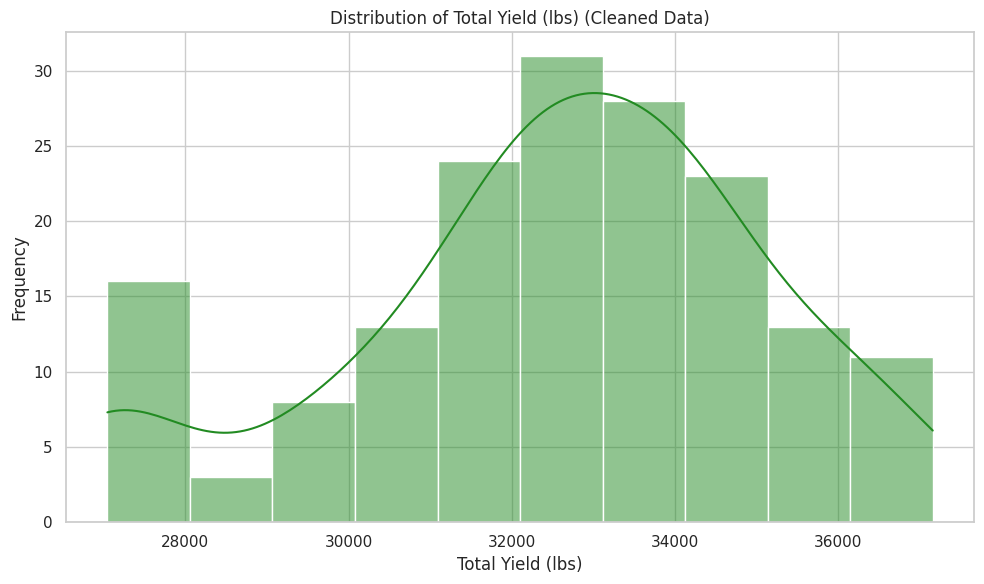

Skipping Boxplot: Spawn Rate and/or Total_lbs is missing, not numeric, or has insufficient variability in df_cleaned.


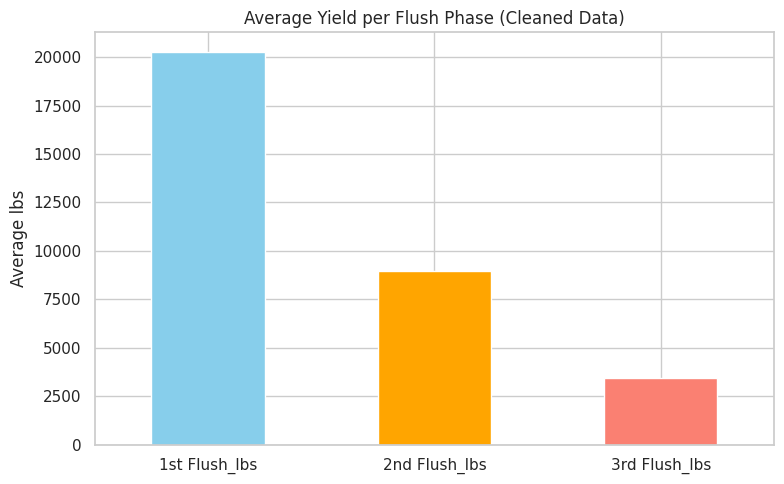

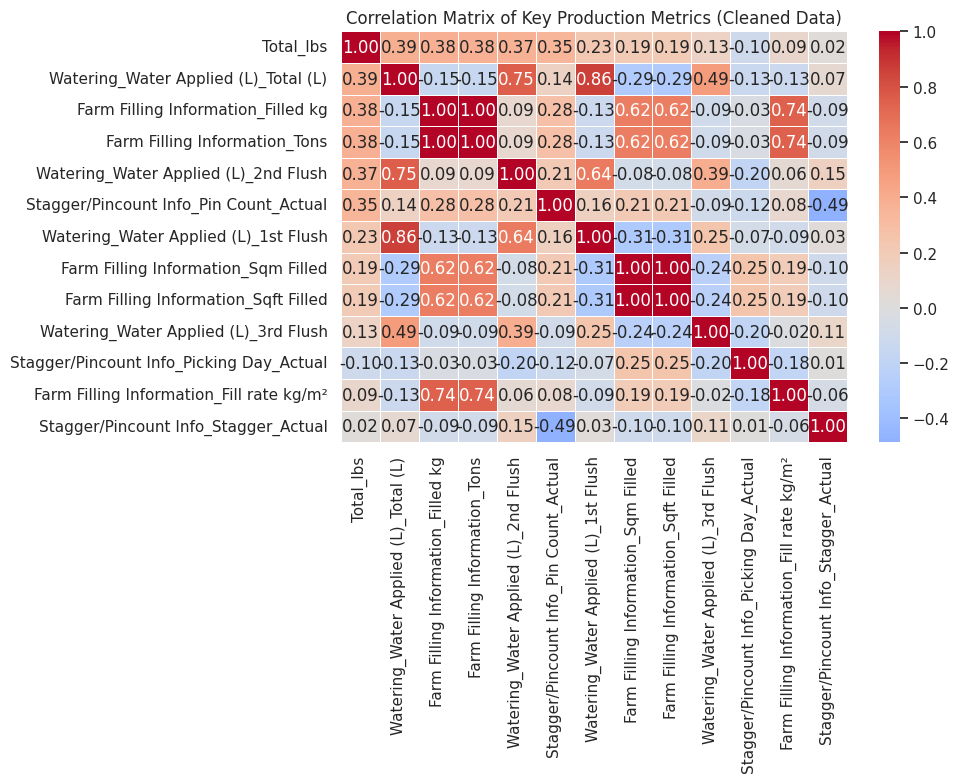

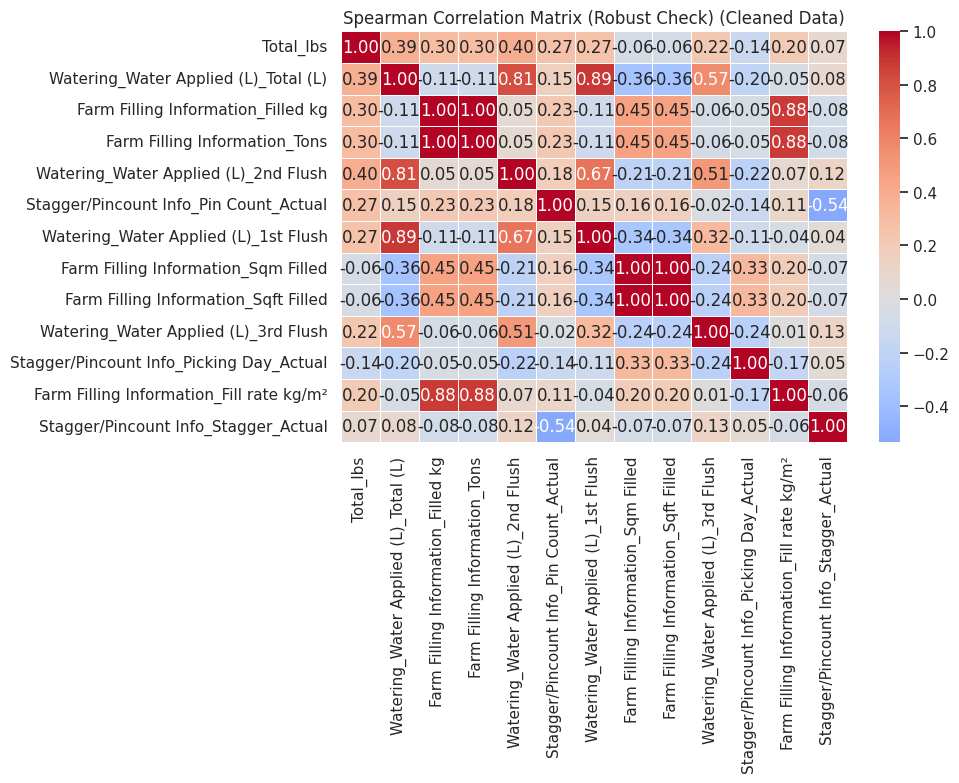

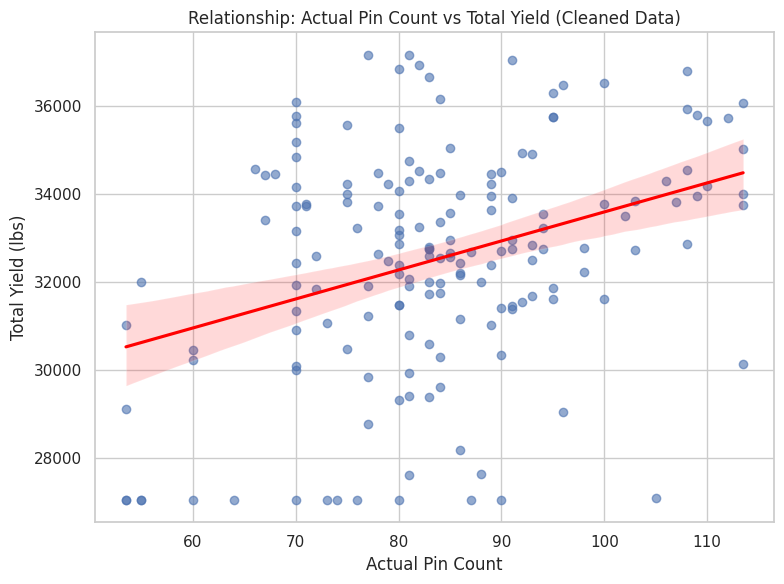

In [15]:
sns.set_theme(style="whitegrid")

# 1. Histogram: Distribution of Total Yield (lbs) using the cleaned dataset
if 'Total_lbs' in df_cleaned.columns and pd.api.types.is_numeric_dtype(df_cleaned['Total_lbs']):
    plt.figure(figsize=(10, 6))
    sns.histplot(df_cleaned['Total_lbs'].dropna(), kde=True, color='forestgreen')
    plt.title('Distribution of Total Yield (lbs) (Cleaned Data)')
    plt.xlabel('Total Yield (lbs)')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()
else:
    print("Skipping Histogram: 'Total_lbs' is missing or not numeric in df_cleaned.")

# 2. Boxplot: Yield distribution across Spawn Rate bins (only if Spawn Rate has enough variability)
if ('Compost Information_Spawn Rate' in df_cleaned.columns and
    pd.api.types.is_numeric_dtype(df_cleaned['Compost Information_Spawn Rate']) and
    df_cleaned['Compost Information_Spawn Rate'].nunique(dropna=True) > 1 and
    'Total_lbs' in df_cleaned.columns and
    pd.api.types.is_numeric_dtype(df_cleaned['Total_lbs'])):

    plt.figure(figsize=(12, 6))
    sns.boxplot(
        x=pd.cut(df_cleaned['Compost Information_Spawn Rate'], bins=5),
        y=df_cleaned['Total_lbs']
    )
    plt.title('Yield Distribution by Spawn Rate Bins (Cleaned Data)')
    plt.xlabel('Spawn Rate (binned)')
    plt.ylabel('Total Yield (lbs)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping Boxplot: Spawn Rate and/or Total_lbs is missing, not numeric, or has insufficient variability in df_cleaned.")

# 3. Bar Chart: Average yield per flush phase (cleaned data)
flush_cols = ['1st Flush_lbs', '2nd Flush_lbs', '3rd Flush_lbs']
existing_flush_cols = [c for c in flush_cols if c in df_cleaned.columns and pd.api.types.is_numeric_dtype(df_cleaned[c])]

if len(existing_flush_cols) >= 2:
    flush_means_cleaned = df_cleaned[existing_flush_cols].mean()
    plt.figure(figsize=(8, 5))
    flush_means_cleaned.plot(kind='bar', color=['skyblue', 'orange', 'salmon'][:len(existing_flush_cols)])
    plt.title('Average Yield per Flush Phase (Cleaned Data)')
    plt.ylabel('Average lbs')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping Bar Chart: Not enough flush yield columns are available and numeric in df_cleaned.")

# 4. Correlation analysis (cleaned data): key variables only, with near-zero variance removal and optional target-based ordering
key_corr_cols = [
    # Inputs
'Compost Information_Spawn Rate', 'Compost Information_Supplement Rate', 'Compost Information_Water Added',
 'Farm Filling Information_Sqft Filled', 'Farm Filling Information_Missing Sections',
 'Farm Filling Information_Sqm Filled', 'Farm Filling Information_Tons', 'Farm Filling Information_Filled heights (cm)',
 'Farm Filling Information_Filled kg', 'Farm Filling Information_Fill rate kg/m²', 'Stagger/Pincount Info_Picking Day_Actual',
 'Stagger/Pincount Info_Picking Day_Target', 'Stagger/Pincount Info_Pin Count_Actual',
 'Stagger/Pincount Info_Pin Count_Target', 'Stagger/Pincount Info_Stagger_Actual', 'Stagger/Pincount Info_Stagger_Target',
 'Watering_Water Applied (L)_1st Flush', 'Watering_Water Applied (L)_2nd Flush', 'Watering_Water Applied (L)_3rd Flush',
 'Watering_Water Applied (L)_Total (L)', 'Farm_Filling_Information_Loading_Date_Year',


    # Outputs
    #'1st Flush_lbs',
    #'2nd Flush_lbs',
    #'3rd Flush_lbs',
    'Total_lbs',
    #'Total_lbs/sqft'

]

# Keep only existing numeric columns
existing_corr_cols = [
    c for c in key_corr_cols
    if c in df_cleaned.columns and pd.api.types.is_numeric_dtype(df_cleaned[c])
]

# Remove near-zero variance columns (correlation would be unstable or undefined)
existing_corr_cols = [
    c for c in existing_corr_cols
    if df_cleaned[c].dropna().std() > 1e-6
]

if len(existing_corr_cols) > 1:
    # Pearson correlation (linear association)
    corr_matrix_cleaned = df_cleaned[existing_corr_cols].corr(method='pearson')

    # Reorder the matrix by correlation with the target variable (if present)
    target_var = 'Total_lbs'
    if target_var in corr_matrix_cleaned.columns:
        ordered = corr_matrix_cleaned[target_var].abs().sort_values(ascending=False).index
        corr_matrix_cleaned = corr_matrix_cleaned.loc[ordered, ordered]

    # Heatmap visualization
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix_cleaned, annot=True, cmap='coolwarm', fmt=".2f", center=0, linewidths=0.5)
    plt.title('Correlation Matrix of Key Production Metrics (Cleaned Data)')
    plt.tight_layout()
    plt.show()

    # Spearman correlation (rank-based robustness check)
    corr_matrix_cleaned_spearman = df_cleaned[existing_corr_cols].corr(method='spearman')
    if target_var in corr_matrix_cleaned_spearman.columns:
        corr_matrix_cleaned_spearman = corr_matrix_cleaned_spearman.loc[corr_matrix_cleaned.index, corr_matrix_cleaned.columns]

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix_cleaned_spearman, annot=True, cmap='coolwarm', fmt=".2f", center=0, linewidths=0.5)
    plt.title('Spearman Correlation Matrix (Robust Check) (Cleaned Data)')
    plt.tight_layout()
    plt.show()
else:
    print("Skipping Correlation Matrices: Insufficient numeric, non-constant columns for correlation after cleaning.")

# 5. Quantitative relationship: Pin Count vs Total Yield (cleaned data), including regression trend
if ('Stagger/Pincount Info_Pin Count_Actual' in df_cleaned.columns and
    'Total_lbs' in df_cleaned.columns and
    pd.api.types.is_numeric_dtype(df_cleaned['Stagger/Pincount Info_Pin Count_Actual']) and
    pd.api.types.is_numeric_dtype(df_cleaned['Total_lbs'])):

    plt.figure(figsize=(8, 6))
    sns.regplot(
        data=df_cleaned,
        x='Stagger/Pincount Info_Pin Count_Actual',
        y='Total_lbs',
        scatter_kws={'alpha': 0.6},
        line_kws={'color': 'red'}
    )
    plt.title('Relationship: Actual Pin Count vs Total Yield (Cleaned Data)')
    plt.xlabel('Actual Pin Count')
    plt.ylabel('Total Yield (lbs)')
    plt.tight_layout()
    plt.show()
else:
    print("Skipping Scatter/Regression Plot: Required columns are missing or not numeric in df_cleaned.")

**Top Pairwise Correlations Between Numerical Variables**

In [16]:
corr_pairs = (
    corr_matrix_cleaned
    .where(np.triu(np.ones(corr_matrix_cleaned.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ['Variable 1', 'Variable 2', 'Correlation']

# Sort by absolute correlation strength
strong_correlations = corr_pairs.reindex(
    corr_pairs['Correlation'].abs().sort_values(ascending=False).index
)
# Display top correlations
strong_correlations.head(10)

,Variable 1,Variable 2,Correlation
23,Farm Filling Information_Filled kg,Farm Filling Information_Tons,1.000000
63,Farm Filling Information_Sqm Filled,Farm Filling Information_Sqft Filled,0.999982
16,Watering_Water Applied (L)_Total (L),Watering_Water Applied (L)_1st Flush,0.857012
14,Watering_Water Applied (L)_Total (L),Watering_Water Applied (L)_2nd Flush,0.752894
31,Farm Filling Information_Filled kg,Farm Filling Information_Fill rate kg/m²,0.744978
40,Farm Filling Information_Tons,Farm Filling Information_Fill rate kg/m²,0.744978
43,Watering_Water Applied (L)_2nd Flush,Watering_Water Applied (L)_1st Flush,0.639833
36,Farm Filling Information_Tons,Farm Filling Information_Sqm Filled,0.624480
27,Farm Filling Information_Filled kg,Farm Filling Information_Sqm Filled,0.624480
37,Farm Filling Information_Tons,Farm Filling Information_Sqft Filled,0.624459


**Correlation of Key Variables with Total Yield (Total_lbs)**

In [17]:
target_var = 'Total_lbs'

yield_correlations = (
    corr_matrix_cleaned[target_var]
    .drop(target_var)
    .sort_values(key=abs, ascending=False)
)

yield_correlations

,Total_lbs
Watering_Water Applied (L)_Total (L),0.388381
Farm Filling Information_Filled kg,0.381929
Farm Filling Information_Tons,0.381929
Watering_Water Applied (L)_2nd Flush,0.372436
Stagger/Pincount Info_Pin Count_Actual,0.346093
Watering_Water Applied (L)_1st Flush,0.225014
Farm Filling Information_Sqm Filled,0.194966
Farm Filling Information_Sqft Filled,0.194740
Watering_Water Applied (L)_3rd Flush,0.125145
Stagger/Pincount Info_Picking Day_Actual,-0.104220


## Conclusions

**Univariable Analysis (Cleaned Data)**

* **Total Yield (lbs) Distribution:**

  Using the cleaned dataset, the histogram of Total_lbs shows a more representative distribution of production outcomes. The removal of extreme and missing-value distortions results in clearer yield ranges and improved interpretability of typical production behavior.

* **Spawn Rate Impact:**

  The boxplot analysis with cleaned data indicates that Compost Information_Spawn Rate exhibits limited variability in its relationship with Total_lbs. Its relatively stable behavior across bins suggests that spawn rate is not a primary driver of yield variability within this dataset.

* **Yield per Flush Phase:**

  The bar chart based on cleaned data consistently shows that 1st Flush_lbs contributes the largest share of total yield, followed by 2nd Flush_lbs and 3rd Flush_lbs. This pattern remains stable after preprocessing, highlighting the importance of early production stages.

**Multivariable Analysis (Cleaned Correlation and Pairwise Analysis)**

* Total Yield (Total_lbs) and Total_lbs/sqft (Cleaned Data):

  * 1st Flush_lbs, 2nd Flush_lbs, and 3rd Flush_lbs maintain very strong positive correlations with total yield, confirming that total production is primarily driven by flush-level performance, particularly during the first flush.

  * Farm Filling Information_Filled kg and Farm Filling Information_Fill rate kg/m² show strong positive correlations with yield metrics, reinforcing the importance of substrate quantity and loading density after noise reduction.

  * Watering_Water Applied (L)_Total (L) remains strongly correlated with total yield, likely reflecting operational scale rather than a direct causal effect.

  * Stagger/Pincount Info_Pin Count_Actual shows a moderate positive correlation with yield, supporting its role as a biological indicator of productive capacity in the cleaned dataset.

  * Compost Information_Spawn Rate and Stagger/Pincount Info_Stagger_Actual continue to display weak or negligible linear relationships with total yield.

* Pairwise Correlation Analysis (Cleaned Data):
The strongest pairwise correlations occur among yield-related variables, indicating redundancy and potential multicollinearity. This confirms that, after cleaning, the dataset retains consistent production relationships while emphasizing the need for careful feature selection in future modeling.

# **Phase 2. Feature Engineering**

The next step in data preparation is to process mixed-type and categorical variables, engineer features from date variables, apply numerical feature transformations and scaling, generate new domain-specific features, and perform feature selection.

Specifically, we will:

1.  **Clean column names** by stripping leading/trailing spaces from all column names in `df_cleaned` to ensure consistency.
2.  **Process mixed-type object columns**:
    *   **'Compost Information_Supplement Rate'**: Convert values like '1.3%/1.22%' to numerical form. We will define a function to parse these strings, interpreting percentages as decimals (e.g., '1.3%' becomes 0.013). If multiple values are present (e.g., 'X%/Y%'), We will calculate their average. Non-parseable values will become NaN.
    *   **'Compost Information_Water Added'**: Convert values like '7.81/9.16' to a single numerical form. We will define a function to parse these strings, calculating the average if multiple values are present. Non-parseable values will become NaN.
    *   **'Farm Filling Information_Filled heights (cm)'**: Convert this column to a numerical data type, coercing any errors to NaN.
    *   After conversion, any new NaNs in these columns will be imputed using the median of their respective columns.
3.  **Engineer features from date variables**:
    *   Extract year, month, day, day of the week, and week of the year from 'Farm Filling Information_Loading Date' and 'Stagger/Pincount Info_Picking Date'.
    *   Calculate the difference in days between 'Stagger/Pincount Info_Picking Date' and 'Farm Filling Information_Loading Date', storing it as a new feature 'Days_Between_Loading_and_Picking'.
4.  **Identify and process remaining categorical variables**: Convert 'Compost Information_Supplement Rate' (if still object after parsing attempts), 'Compost Information_Water Added' (if still object after parsing attempts), and 'Farm Filling Information_Filled heights (cm)' (if still object after name cleaning and numeric conversion attempts) into appropriate numerical representations using one-hot encoding if they are truly categorical. Given the previous analysis and the plan, it's expected these will become numerical after step 2.
5.  **Re-evaluate data types and describe the `df_cleaned` DataFrame** to verify the changes.

## Clean column names


To ensure consistency and ease of use, we will strip any leading or trailing spaces from the column names in the `df_cleaned` DataFrame.



In [18]:
df_cleaned.columns = df_cleaned.columns.str.strip()
print("Column names in df_cleaned after stripping spaces:")
print(df_cleaned.columns.tolist())

Column names in df_cleaned after stripping spaces:
['Compost Information_Spawn Rate', 'Compost Information_Supplement Rate', 'Compost Information_Water Added', 'Farm Filling Information_Sqft Filled', 'Farm Filling Information_Missing Sections', 'Farm Filling Information_Sqm Filled', 'Farm Filling Information_Tons', 'Farm Filling Information_Filled heights (cm)', 'Farm Filling Information_Filled kg', 'Farm Filling Information_Fill rate kg/m²', 'Farm Filling Information_Loading Date', 'Stagger/Pincount Info_Picking Date', 'Stagger/Pincount Info_Picking Day_Actual', 'Stagger/Pincount Info_Picking Day_Target', 'Stagger/Pincount Info_Pin Count_Actual', 'Stagger/Pincount Info_Pin Count_Target', 'Stagger/Pincount Info_Stagger_Actual', 'Stagger/Pincount Info_Stagger_Target', 'Watering_Water Applied (L)_1st Flush', 'Watering_Water Applied (L)_2nd Flush', 'Watering_Water Applied (L)_3rd Flush', 'Watering_Water Applied (L)_Total (L)', '1st Flush_Day 1', '1st Flush_Sep lbs', '1st Flush_Day 2', '1s

## Process Mixed-Type and Categorical Variables


We will define two helper functions to parse and convert mixed-type strings containing percentages or multiple numbers separated by slashes into numerical averages. Then, we will apply these functions to the specified columns, and directly convert the 'Farm Filling Information_Filled heights (cm)' column to numeric, handling potential errors by coercing them to NaN. Finally, we will impute any newly created or existing NaN values in these three columns using their respective medians.



In [19]:
def parse_and_average_percentage(value):
    if isinstance(value, str) and value.strip():
        try:
            # Remove '%' and split by '/'
            parts = value.replace('%', '').split('/')
            numbers = []
            for p in parts:
                try:
                    num = float(p.strip())
                    # Interpret percentage as decimal if it's from a percentage string
                    # Assume if a string contains '%' originally, the number should be divided by 100
                    # If it's just a number like '1.22' it should be taken as is.
                    # Given the examples like '1.3%/1.22%', assuming numbers are percentages.
                    numbers.append(num / 100)
                except ValueError:
                    continue # Skip non-numeric parts
            if numbers: # Calculate average of valid numbers
                return np.mean(numbers)
            else:
                return np.nan # No valid numbers found
        except Exception: # Catch any other parsing errors
            return np.nan
    elif pd.isna(value):
        return np.nan # Keep existing NaNs
    else:
        return value # Return non-string, non-NaN values as is (should be already numeric)

# Apply the function to 'Compost Information_Supplement Rate'
df_cleaned['Compost Information_Supplement Rate'] = df_cleaned['Compost Information_Supplement Rate'].apply(parse_and_average_percentage)

def parse_and_average_number(value):
    if isinstance(value, str) and value.strip():
        try:
            # Split by '/'
            parts = value.split('/')
            numbers = []
            for p in parts:
                try:
                    numbers.append(float(p.strip()))
                except ValueError:
                    continue # Skip non-numeric parts
            if numbers: # Calculate average of valid numbers
                return np.mean(numbers)
            else:
                return np.nan # No valid numbers found
        except Exception: # Catch any other parsing errors
            return np.nan
    elif pd.isna(value):
        return np.nan # Keep existing NaNs
    else:
        return value # Return non-string, non-NaN values as is (should be already numeric)

# Apply the function to 'Compost Information_Water Added'
df_cleaned['Compost Information_Water Added'] = df_cleaned['Compost Information_Water Added'].apply(parse_and_average_number)

# Convert 'Farm Filling Information_Filled heights (cm)' to numeric, coercing errors to NaN
df_cleaned['Farm Filling Information_Filled heights (cm)'] = pd.to_numeric(
    df_cleaned['Farm Filling Information_Filled heights (cm)'], errors='coerce'
)

# Impute any remaining NaN values in these three columns with their respective medians
columns_to_impute = [
    'Compost Information_Supplement Rate',
    'Compost Information_Water Added',
    'Farm Filling Information_Filled heights (cm)'
]

for col in columns_to_impute:
    if col in df_cleaned.columns:
        median_val = df_cleaned[col].median()
        df_cleaned[col] = df_cleaned[col].fillna(median_val)

print("Processing of mixed-type and categorical variables complete.")
print("Data types after processing:")
print(df_cleaned[columns_to_impute].dtypes)
print("Missing values after processing:")
print(df_cleaned[columns_to_impute].isnull().sum())


Processing of mixed-type and categorical variables complete.
Data types after processing:
Compost Information_Supplement Rate             float64
Compost Information_Water Added                 float64
Farm Filling Information_Filled heights (cm)    float64
dtype: object
Missing values after processing:
Compost Information_Supplement Rate             0
Compost Information_Water Added                 0
Farm Filling Information_Filled heights (cm)    0
dtype: int64


## Engineer Features from Date Variables

To engineer features from date variables, we will extract year, month, day, day of the week, and week of the year from the specified date columns, and then calculate the difference in days between the loading and picking dates.



In [20]:
date_cols = ['Farm Filling Information_Loading Date', 'Stagger/Pincount Info_Picking Date']

for col in date_cols:
    # Ensure the column is datetime type
    df_cleaned[col] = pd.to_datetime(df_cleaned[col], errors='coerce')

    # Extract year, month, day, filling NaN with -1 before converting to int
    df_cleaned[col.replace(' ', '_') + '_Year'] = df_cleaned[col].dt.year.fillna(-1).astype(pd.Int64Dtype())
    df_cleaned[col.replace(' ', '_') + '_Month'] = df_cleaned[col].dt.month.fillna(-1).astype(pd.Int64Dtype())
    df_cleaned[col.replace(' ', '_') + '_Day'] = df_cleaned[col].dt.day.fillna(-1).astype(pd.Int64Dtype())

    # Extract day of the week (Monday=0, Sunday=6), filling NaN with -1 before converting to int
    df_cleaned[col.replace(' ', '_') + '_DayOfWeek'] = df_cleaned[col].dt.dayofweek.fillna(-1).astype(pd.Int64Dtype())

    # Extract week of the year, convert to signed type before filling NaN with -1
    df_cleaned[col.replace(' ', '_') + '_WeekOfYear'] = df_cleaned[col].dt.isocalendar().week.astype(pd.Int64Dtype()).fillna(-1)

# Calculate the difference in days between 'Picking Date' and 'Loading Date'
df_cleaned['Days_Between_Loading_and_Picking'] = (
    df_cleaned['Stagger/Pincount Info_Picking Date'] - df_cleaned['Farm Filling Information_Loading Date']
).dt.days.fillna(-1).astype(pd.Int64Dtype())

print("Engineered features from date variables:")
print(df_cleaned[['Farm_Filling_Information_Loading_Date_Year',
                  'Farm_Filling_Information_Loading_Date_Month',
                  'Farm_Filling_Information_Loading_Date_Day',
                  'Farm_Filling_Information_Loading_Date_DayOfWeek',
                  'Farm_Filling_Information_Loading_Date_WeekOfYear',
                  'Stagger/Pincount_Info_Picking_Date_Year',
                  'Stagger/Pincount_Info_Picking_Date_Month',
                  'Stagger/Pincount_Info_Picking_Date_Day',
                  'Stagger/Pincount_Info_Picking_Date_DayOfWeek',
                  'Stagger/Pincount_Info_Picking_Date_WeekOfYear',
                  'Days_Between_Loading_and_Picking']].head())

Engineered features from date variables:
   Farm_Filling_Information_Loading_Date_Year  \
0                                        2024   
1                                        2024   
2                                        2024   
3                                        2025   
4                                        2025   

   Farm_Filling_Information_Loading_Date_Month  \
0                                           12   
1                                           12   
2                                           12   
3                                            1   
4                                            1   

   Farm_Filling_Information_Loading_Date_Day  \
0                                         25   
1                                         26   
2                                         31   
3                                          1   
4                                          2   

   Farm_Filling_Information_Loading_Date_DayOfWeek  \
0                   

Now that the date features have been engineered, we will re-evaluate the data types and provide a descriptive summary of the `df_cleaned` DataFrame to verify all the changes made so far and ensure the data is in the expected format for further processing.



In [21]:
print("Updated DataFrame Information:")
df_cleaned.info()

print("\nDescriptive statistics for the updated DataFrame:")
df_cleaned.describe()

Updated DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 74 columns):
 #   Column                                            Non-Null Count  Dtype         
---  ------                                            --------------  -----         
 0   Compost Information_Spawn Rate                    170 non-null    float64       
 1   Compost Information_Supplement Rate               170 non-null    float64       
 2   Compost Information_Water Added                   170 non-null    float64       
 3   Farm Filling Information_Sqft Filled              170 non-null    float64       
 4   Farm Filling Information_Missing Sections         170 non-null    float64       
 5   Farm Filling Information_Sqm Filled               170 non-null    float64       
 6   Farm Filling Information_Tons                     170 non-null    float64       
 7   Farm Filling Information_Filled heights (cm)      170 non-null    float64       
 8  

,Compost Information_Spawn Rate,Compost Information_Supplement Rate,Compost Information_Water Added,Farm Filling Information_Sqft Filled,Farm Filling Information_Missing Sections,Farm Filling Information_Sqm Filled,Farm Filling Information_Tons,Farm Filling Information_Filled heights (cm),Farm Filling Information_Filled kg,Farm Filling Information_Fill rate kg/m²,...,Farm_Filling_Information_Loading_Date_Month,Farm_Filling_Information_Loading_Date_Day,Farm_Filling_Information_Loading_Date_DayOfWeek,Farm_Filling_Information_Loading_Date_WeekOfYear,Stagger/Pincount_Info_Picking_Date_Year,Stagger/Pincount_Info_Picking_Date_Month,Stagger/Pincount_Info_Picking_Date_Day,Stagger/Pincount_Info_Picking_Date_DayOfWeek,Stagger/Pincount_Info_Picking_Date_WeekOfYear,Days_Between_Loading_and_Picking
count,1.700000e+02,170.000000,170.000000,170.000000,170.0,170.000000,170.000000,170.000000,170.000000,170.000000,...,170.0,170.0,170.0,170.0,170.0,170.0,170.0,170.0,170.0,170.0
mean,1.501535e+01,0.013736,4.980206,4644.923529,2.0,431.388235,37.869412,29.182353,37869.411765,88.570818,...,6.476471,15.952941,1.888235,26.523529,2025.011765,6.629412,15.305882,2.635294,26.994118,14.747059
min,1.501535e+01,0.011300,0.000000,4565.500000,2.0,424.000000,32.310000,26.000000,32310.000000,75.978860,...,1.0,1.0,0.0,1.0,2025.0,1.0,1.0,0.0,1.0,13.0
25%,1.501535e+01,0.013500,5.140000,4630.000000,2.0,430.000000,36.532500,28.000000,36532.500000,85.123068,...,4.0,8.25,0.0,14.0,2025.0,4.0,7.25,1.0,14.0,14.0
50%,1.501535e+01,0.013500,5.140000,4647.000000,2.0,431.500000,38.140000,29.000000,38140.000000,88.779088,...,7.0,16.0,2.0,27.0,2025.0,7.0,15.0,3.0,27.0,15.0
75%,1.501535e+01,0.013500,5.140000,4673.000000,2.0,434.000000,39.347500,30.000000,39347.500000,91.233711,...,9.0,23.0,3.0,39.0,2025.0,10.0,23.0,4.0,40.0,15.0
max,1.501535e+01,0.040000,9.210000,4673.000000,2.0,434.000000,43.570000,35.000000,43570.000000,100.399675,...,12.0,31.0,4.0,52.0,2026.0,12.0,31.0,6.0,52.0,17.0
std,3.028728e-14,0.002174,1.502802,33.322346,0.0,3.098364,2.364179,1.801293,2364.179106,4.334507,...,3.418022,8.876411,1.311931,14.863164,0.108144,3.419101,8.888559,1.335426,14.900259,0.565913


# **Phases 3. Baseline**
Prepare the data for modeling by identifying the target variables (`1st Flush_lbs`, `2nd Flush_lbs`, `3rd Flush_lbs`) and features. Perform a train-test split, apply skewness transformation using `log1p`, scale numerical features with `StandardScaler` (fitting only on `X_train`), and then apply PCA to the scaled features, retaining 95% of the variance, transforming both `X_train` and `X_test`.

## Prepare Data for Modeling (Train-Test Split, Scaling, and PCA)

Identify target variables and features, perform a train-test split, apply skewness transformation using log1p, scale numerical features with StandardScaler (fitting only on X_train), and then apply PCA to the scaled features, retaining 95% of the variance, transforming both X_train and X_test.


In [22]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Function to make column names unique by appending a suffix if duplicates exist
def make_columns_unique_simple(df_input):
    df = df_input.copy() # Work on a copy
    cols = []
    seen_counts = {} # Dictionary to store counts of each column name
    for col in df.columns:
        current_name = col
        if current_name in seen_counts:
            # If seen, increment count and append to name
            seen_counts[current_name] += 1
            new_name = f"{current_name}_{seen_counts[current_name]}"
            # Ensure the new_name is also unique across all columns already processed/existing
            while new_name in df.columns.tolist() or new_name in cols:
                seen_counts[current_name] += 1
                new_name = f"{current_name}_{seen_counts[current_name]}"
            cols.append(new_name)
        else:
            # First time seeing this name, add it as is
            seen_counts[current_name] = 0 # Initialize count for this name
            cols.append(current_name)
    df.columns = cols
    return df

# Apply make_columns_unique_simple to df_cleaned once
df_cleaned = make_columns_unique_simple(df_cleaned)

# Define target columns
target_columns = ['1st Flush_lbs', '2nd Flush_lbs', '3rd Flush_lbs']

# Refined global features to exclude (non-informative or original datetime columns)
global_features_to_exclude = [
    'Farm Filling Information_Loading Date', # Original datetime column
    'Stagger/Pincount Info_Picking Date', # Original datetime column
    'Compost Information_Spawn Rate',
    'Farm Filling Information_Missing Sections',
    'Stagger/Pincount Info_Picking Day_Target',
    'Stagger/Pincount Info_Pin Count_Target',
    'Stagger/Pincount Info_Stagger_Target',
    'Total_Target',
    'Farm Filling Information_Sqm Filled',
    'Farm Filling Information_Tons'
]

# Define target-specific features to exclude (to prevent data leakage)
target_exclusion_map = {
    '1st Flush_lbs': [
        # Exclude all 2nd Flush, 3rd Flush, and Total_lbs related features
        '2nd Flush_Day 1', '2nd Flush_Day 2', '2nd Flush_Day 3', '2nd Flush_Day 4', '2nd Flush_Day 5',
        '2nd Flush_Day 6', '2nd Flush_Day 7', '2nd Flush_Day 8', '2nd Flush_Day 9', '2nd Flush_lbs',
        '2nd Flush_lbs/sqft', '2nd Flush_lbs/ton',
        '3rd Flush_Day 1', '3rd Flush_Day 2', '3rd Flush_Day 3', '3rd Flush_Day 4', '3rd Flush_Day 5',
        '3rd Flush_Day 6', '3rd Flush_Day 7', '3rd Flush_Day 8', '3rd Flush_Day 9', '3rd Flush_lbs',
        '3rd Flush_lbs/sqft', '3rd Flush_lbs/ton',
        'Total_lbs', 'Total_lbs/sqft', 'Total_lbs/ton',
        # Exclude 1st Flush daily breakdown and derived ratios that are part of the target calculation
        '1st Flush_Day 1', '1st Flush_Sep lbs', '1st Flush_Day 2', '1st Flush_Sep lbs_1', '1st Flush_Day 3',
        '1st Flush_Day 4', '1st Flush_Day 5', '1st Flush_Day 6', '1st Flush_Day 7',
        '1st Flush_Sep %', '1st Flush_lbs/sqft', '1st Flush_lbs/ton', 'Watering_Water Applied (L)_2nd Flush',
        'Watering_Water Applied (L)_3rd Flush', 'Watering_Water Applied (L)_Total (L)'
    ],
    '2nd Flush_lbs': [
        # Exclude all 3rd Flush and Total_lbs related features
        '3rd Flush_Day 1', '3rd Flush_Day 2', '3rd Flush_Day 3', '3rd Flush_Day 4', '3rd Flush_Day 5',
        '3rd Flush_Day 6', '3rd Flush_Day 7', '3rd Flush_Day 8', '3rd Flush_Day 9', '3rd Flush_lbs',
        '3rd Flush_lbs/sqft', '3rd Flush_lbs/ton',
        'Total_lbs', 'Total_lbs/sqft', 'Total_lbs/ton',
        # Exclude 2nd Flush daily breakdown and derived ratios that are part of the target calculation
        '2nd Flush_Day 1', '2nd Flush_Day 2', '2nd Flush_Day 3', '2nd Flush_Day 4', '2nd Flush_Day 5',
        '2nd Flush_Day 6', '2nd Flush_Day 7', '2nd Flush_Day 8', '2nd Flush_Day 9', '2nd Flush_lbs/sqft',
        '2nd Flush_lbs/ton',
        # Also exclude 1st Flush daily breakdown and derived ratios to avoid redundancy/leakage from related outputs
        '1st Flush_Day 1', '1st Flush_Sep lbs', '1st Flush_Day 2', '1st Flush_Sep lbs_1', '1st Flush_Day 3',
        '1st Flush_Day 4', '1st Flush_Day 5', '1st Flush_Day 6', '1st Flush_Day 7',
        '1st Flush_Sep %', '1st Flush_lbs/sqft', '1st Flush_lbs/ton', # Note: 1st Flush_lbs itself is not excluded here as it's a predictor
        'Watering_Water Applied (L)_3rd Flush', 'Watering_Water Applied (L)_Total (L)'
    ],
    '3rd Flush_lbs': [
        # Exclude Total_lbs related features
        'Total_lbs', 'Total_lbs/sqft', 'Total_lbs/ton',
        # Exclude 3rd Flush daily breakdown and derived ratios that are part of the target calculation
        '3rd Flush_Day 1', '3rd Flush_Day 2', '3rd Flush_Day 3', '3rd Flush_Day 4', '3rd Flush_Day 5',
        '3rd Flush_Day 6', '3rd Flush_Day 7', '3rd Flush_Day 8', '3rd Flush_Day 9', '3rd Flush_lbs/sqft',
        '3rd Flush_lbs/ton',
        # Exclude all 1st and 2nd Flush daily breakdown and derived ratios to avoid redundancy/leakage
        '1st Flush_Day 1', '1st Flush_Sep lbs', '1st Flush_Day 2', '1st Flush_Sep lbs_1', '1st Flush_Day 3',
        '1st Flush_Day 4', '1st Flush_Day 5', '1st Flush_Day 6', '1st Flush_Day 7',
        '1st Flush_Sep %', '1st Flush_lbs/sqft', '1st Flush_lbs/ton',
        '2nd Flush_Day 1', '2nd Flush_Day 2', '2nd Flush_Day 3', '2nd Flush_Day 4', '2nd Flush_Day 5',
        '2nd Flush_Day 6', '2nd Flush_Day 7', '2nd Flush_Day 8', '2nd Flush_Day 9', '2nd Flush_lbs/sqft',
        '2nd Flush_lbs/ton'
    ]
}

def get_processed_data_for_target(
    df_input,
    target_name,
    all_target_columns,
    global_features_to_exclude,
    target_specific_features_to_exclude=None,
    apply_pca=True,
    test_size=0.2,
    random_state=42
):
    """
    Prepares data for modeling by splitting, transforming, scaling, and optionally applying PCA.

    Args:
        df_input (pd.DataFrame): The input DataFrame (e.g., df_cleaned).
        target_name (str): The name of the specific target variable (e.g., '1st Flush_lbs').
        all_target_columns (list): A list of all potential target columns.
        global_features_to_exclude (list): List of features to exclude from X globally.
        target_specific_features_to_exclude (list, optional): List of features to exclude for this specific target.
                                                             Defaults to None (treated as empty list).
        apply_pca (bool, optional): Whether to apply PCA. Defaults to True.
        test_size (float, optional): Proportion of the dataset for the test split. Defaults to 0.2.
        random_state (int, optional): Random seed for reproducibility. Defaults to 42.

    Returns:
        tuple: (X_train, X_test, y_train_target, y_test_target, scaler, pca_model)
               where pca_model is None if apply_pca is False.
    """
    if target_specific_features_to_exclude is None:
        target_specific_features_to_exclude = []

    # a. Create the target variable y_target
    y_target = df_input[target_name].copy()

    # Combine global and target-specific exclusions, ensuring target_name itself is excluded from features
    cols_to_drop = list(set(
        all_target_columns + # All targets are excluded from features initially
        global_features_to_exclude +
        target_specific_features_to_exclude +
        [target_name] # Explicitly drop the current target from X (if not already in all_target_columns)
    ))
    # Ensure only columns present in df_input are attempted to be dropped
    cols_to_drop = [col for col in cols_to_drop if col in df_input.columns]

    # b. Create the initial feature set X_initial
    X_initial = df_input.drop(columns=cols_to_drop, errors='ignore').copy()

    # c. Filter X_initial to include only numerical columns
    X_initial = X_initial.select_dtypes(include=[np.number, pd.Int64Dtype()])

    # Drop any remaining columns with all NaNs if they somehow snuck through or were created (e.g. from dtypes)
    X_initial = X_initial.dropna(axis=1, how='all')

    # d. Perform train_test_split
    X_train_raw, X_test_raw, y_train_target, y_test_target = train_test_split(
        X_initial, y_target, test_size=test_size, random_state=random_state, shuffle=True
    )

    # e. Apply np.log1p transformation and handle NaNs
    numerical_cols_X = X_train_raw.columns
    for col in numerical_cols_X:
        # Add a small constant to handle non-positive values before log1p, if any
        # Or, filter for values > 0. For now, assuming non-negative after preprocessing.
        X_train_raw[col] = np.log1p(X_train_raw[col])
        X_test_raw[col] = np.log1p(X_test_raw[col])

        # Fill NaNs introduced by log1p (e.g., from log1p(0) for some very small negative numbers in practice)
        if X_train_raw[col].isnull().any():
            median_val = X_train_raw[col].median()
            X_train_raw[col] = X_train_raw[col].fillna(median_val)
        if X_test_raw[col].isnull().any():
            median_val = X_train_raw[col].median() # Use median from training to avoid data leakage
            X_test_raw[col] = X_test_raw[col].fillna(median_val)

    # f. Identify and remove any constant columns (zero variance) before scaling
    constant_columns = X_train_raw.columns[X_train_raw.std() == 0]
    if len(constant_columns) > 0:
        X_train_raw = X_train_raw.drop(columns=constant_columns)
        X_test_raw = X_test_raw.drop(columns=constant_columns)
        print(f"Removed constant columns with zero variance for {target_name}: {list(constant_columns)}")

    # g. Initialize and fit StandardScaler
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X_train_raw.columns, index=X_train_raw.index)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test_raw), columns=X_test_raw.columns, index=X_test_raw.index)

    pca_model = None
    # h. Optionally apply PCA
    if apply_pca:
        pca_model = PCA(n_components=0.95)
        X_train_pca = pd.DataFrame(
            pca_model.fit_transform(X_train_scaled),
            index=X_train_scaled.index,
            columns=[f'PC_{i+1}' for i in range(pca_model.n_components_)]
        )
        X_test_pca = pd.DataFrame(
            pca_model.transform(X_test_scaled),
            index=X_test_scaled.index,
            columns=[f'PC_{i+1}' for i in range(pca_model.n_components_)]
        )
        return X_train_pca, X_test_pca, y_train_target, y_test_target, scaler, pca_model
    else:
        return X_train_scaled, X_test_scaled, y_train_target, y_test_target, scaler, None

print("Data preparation logic refactored into 'get_processed_data_for_target' function.")

# --- Initialize data storage dictionaries ---
processed_data_store_pca = {}
processed_data_store_no_pca = {}

# --- Loop through each target and process data ---
for target in target_columns:
    print(f"\nProcessing data for target: {target}")

    # Get target-specific exclusions
    target_specific_exclusions = target_exclusion_map.get(target, [])

    # Process with PCA
    X_train_pca, X_test_pca, y_train_target, y_test_target, scaler_pca, pca_model = \
        get_processed_data_for_target(
            df_cleaned,
            target,
            target_columns,
            global_features_to_exclude,
            target_specific_features_to_exclude=target_specific_exclusions,
            apply_pca=True
        )
    processed_data_store_pca[target] = (X_train_pca, X_test_pca, y_train_target, y_test_target, scaler_pca, pca_model)
    print(f"  -> Stored PCA processed data for {target}. X_train_pca shape: {X_train_pca.shape}")

    # Process without PCA
    X_train_no_pca, X_test_no_pca, y_train_target_no_pca, y_test_target_no_pca, scaler_no_pca, _ = \
        get_processed_data_for_target(
            df_cleaned,
            target,
            target_columns,
            global_features_to_exclude,
            target_specific_features_to_exclude=target_specific_exclusions,
            apply_pca=False
        )
    processed_data_store_no_pca[target] = (X_train_no_pca, X_test_no_pca, y_train_target_no_pca, y_test_target_no_pca, scaler_no_pca, None)
    print(f"  -> Stored non-PCA processed data for {target}. X_train_no_pca shape: {X_train_no_pca.shape}")

print("\nAll target-specific data processed and stored.")

Data preparation logic refactored into 'get_processed_data_for_target' function.

Processing data for target: 1st Flush_lbs
  -> Stored PCA processed data for 1st Flush_lbs. X_train_pca shape: (136, 13)
  -> Stored non-PCA processed data for 1st Flush_lbs. X_train_no_pca shape: (136, 21)

Processing data for target: 2nd Flush_lbs
  -> Stored PCA processed data for 2nd Flush_lbs. X_train_pca shape: (136, 14)
  -> Stored non-PCA processed data for 2nd Flush_lbs. X_train_no_pca shape: (136, 22)

Processing data for target: 3rd Flush_lbs
  -> Stored PCA processed data for 3rd Flush_lbs. X_train_pca shape: (136, 15)
  -> Stored non-PCA processed data for 3rd Flush_lbs. X_train_no_pca shape: (136, 24)

All target-specific data processed and stored.


In [23]:
print("Variables used in the model after PCA:")
print(X_train_pca.columns.tolist())

Variables used in the model after PCA:
['PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_5', 'PC_6', 'PC_7', 'PC_8', 'PC_9', 'PC_10', 'PC_11', 'PC_12', 'PC_13', 'PC_14', 'PC_15']


## Define Baselines, Metrics, and Performance Benchmarks

Establish a Naive (mean prediction) and Linear Regression model as baselines for each flush target. Define RMSE, MAE, and R-squared as primary evaluation metrics. Discuss methods for identifying overfitting/underfitting and set the minimum performance benchmark based on the Naive baseline. Clarify 'Total_lbs' as an overall business metric versus individual flush predictions as primary targets.


In [24]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Initialize Linear Regression model
linear_model = LinearRegression()

# Target variables (already defined in previous step)
target_columns = ['1st Flush_lbs', '2nd Flush_lbs', '3rd Flush_lbs']

# Dictionary to store metrics for each target
results = {}

print("Establishing Baselines and Calculating Metrics:")

for target in target_columns:
    print(f"\n--- Processing Target: {target} ---")

    # Retrieve PCA processed data for the current target
    X_train_pca, X_test_pca, y_train_target, y_test_target, scaler_pca, pca_model = processed_data_store_pca[target]

    # 1. Naive Baseline (Mean Prediction)
    # Calculate Naive baseline prediction as the mean of the respective y_train target variable
    naive_pred_train = y_train_target.mean()
    naive_pred_test = y_train_target.mean() # The naive prediction for test is also based on training data mean

    # Convert scalar predictions to arrays matching the shape of y_train_target/y_test_target for metric calculation
    naive_predictions_train_array = np.full(y_train_target.shape, naive_pred_train)
    naive_predictions_test_array = np.full(y_test_target.shape, naive_pred_test)

    # Calculate metrics for Naive baseline on training set
    naive_mse_train = mean_squared_error(y_train_target, naive_predictions_train_array)
    naive_rmse_train = np.sqrt(naive_mse_train)
    naive_mae_train = mean_absolute_error(y_train_target, naive_predictions_train_array)
    naive_r2_train = r2_score(y_train_target, naive_predictions_train_array)

    # Calculate metrics for Naive baseline on test set
    naive_mse_test = mean_squared_error(y_test_target, naive_predictions_test_array)
    naive_rmse_test = np.sqrt(naive_mse_test)
    naive_mae_test = mean_absolute_error(y_test_target, naive_predictions_test_array)
    naive_r2_test = r2_score(y_test_target, naive_predictions_test_array)

    # Store Naive baseline metrics
    results[target] = {
        'Naive_RMSE_Train': naive_rmse_train,
        'Naive_MAE_Train': naive_mae_train,
        'Naive_R2_Train': naive_r2_train,
        'Naive_RMSE_Test': naive_rmse_test,
        'Naive_MAE_Test': naive_mae_test,
        'Naive_R2_Test': naive_r2_test
    }

    print(f"Naive Baseline (mean of y_train_target[{target}]={naive_pred_train:.2f}):")
    print(f"  Train RMSE: {naive_rmse_train:.2f}, MAE: {naive_mae_train:.2f}, R2: {naive_r2_train:.2f}")
    print(f"  Test RMSE: {naive_rmse_test:.2f}, MAE: {naive_mae_test:.2f}, R2: {naive_r2_test:.2f}")

    # 2. Linear Regression Model
    # Fit the Linear Regression model
    linear_model.fit(X_train_pca, y_train_target)

    # Make predictions
    lr_predictions_train = linear_model.predict(X_train_pca)
    lr_predictions_test = linear_model.predict(X_test_pca)

    # Calculate metrics for Linear Regression on training set
    lr_mse_train = mean_squared_error(y_train_target, lr_predictions_train)
    lr_rmse_train = np.sqrt(lr_mse_train)
    lr_mae_train = mean_absolute_error(y_train_target, lr_predictions_train)
    lr_r2_train = r2_score(y_train_target, lr_predictions_train)

    # Calculate metrics for Linear Regression on test set
    lr_mse_test = mean_squared_error(y_test_target, lr_predictions_test)
    lr_rmse_test = np.sqrt(lr_mse_test)
    lr_mae_test = mean_absolute_error(y_test_target, lr_predictions_test)
    lr_r2_test = r2_score(y_test_target, lr_predictions_test)

    # Store Linear Regression metrics
    results[target].update({
        'LR_RMSE_Train': lr_rmse_train,
        'LR_MAE_Train': lr_mae_train,
        'LR_R2_Train': lr_r2_train,
        'LR_RMSE_Test': lr_rmse_test,
        'LR_MAE_Test': lr_mae_test,
        'LR_R2_Test': lr_r2_test
    })

    print(f"Linear Regression Model:")
    print(f"  Train RMSE: {lr_rmse_train:.2f}, MAE: {lr_mae_train:.2f}, R2: {lr_r2_train:.2f}")
    print(f"  Test RMSE: {lr_rmse_test:.2f}, MAE: {lr_mae_test:.2f}, R2: {lr_r2_test:.2f}")

# Convert results to DataFrame for better presentation
metrics_df = pd.DataFrame.from_dict(results, orient='index')
metrics_df.index.name = 'Target Variable'

print("\n=======================================================")
print("Summary of Baseline Model Performance (RMSE, MAE, R2)")
print("=======================================================")
display(metrics_df)

print("\n=======================================================")
print("Minimum Performance Benchmarks (based on Naive Test Set performance):")
print("=======================================================")
for target in target_columns:
    print(f"For {target}:\n"\
          f"  RMSE must be significantly lower than {results[target]['Naive_RMSE_Test']:.2f}\n"\
          f"  MAE must be significantly lower than {results[target]['Naive_MAE_Test']:.2f}\n"\
          f"  R2 must be significantly higher than {results[target]['Naive_R2_Test']:.2f} (ideally > 0)")
    if results[target]['Naive_R2_Test'] < 0:
        print(f"    Note: A negative R2 means the Naive model performs worse than simply predicting the mean.")

print("\nAny developed model should aim to achieve an R-squared significantly greater than the Naive baseline's R-squared on the test set, and correspondingly lower RMSE and MAE values. An R-squared value of 0 indicates that the model explains no more variance than the mean of the target variable. Therefore, a model should strive for a positive R-squared, ideally much closer to 1, to demonstrate predictive power.")

Establishing Baselines and Calculating Metrics:

--- Processing Target: 1st Flush_lbs ---
Naive Baseline (mean of y_train_target[1st Flush_lbs]=20372.69):
  Train RMSE: 1849.09, MAE: 1408.26, R2: 0.00
  Test RMSE: 2191.98, MAE: 1664.59, R2: -0.06
Linear Regression Model:
  Train RMSE: 1283.83, MAE: 953.26, R2: 0.52
  Test RMSE: 1878.12, MAE: 1473.79, R2: 0.22

--- Processing Target: 2nd Flush_lbs ---
Naive Baseline (mean of y_train_target[2nd Flush_lbs]=9018.53):
  Train RMSE: 961.23, MAE: 734.64, R2: 0.00
  Test RMSE: 1210.92, MAE: 939.62, R2: -0.03
Linear Regression Model:
  Train RMSE: 822.02, MAE: 662.89, R2: 0.27
  Test RMSE: 1075.54, MAE: 884.33, R2: 0.19

--- Processing Target: 3rd Flush_lbs ---
Naive Baseline (mean of y_train_target[3rd Flush_lbs]=3452.51):
  Train RMSE: 623.45, MAE: 468.07, R2: 0.00
  Test RMSE: 633.32, MAE: 450.82, R2: -0.03
Linear Regression Model:
  Train RMSE: 546.22, MAE: 428.34, R2: 0.23
  Test RMSE: 728.32, MAE: 532.21, R2: -0.36

Summary of Baseline Mo

,Naive_RMSE_Train,Naive_MAE_Train,Naive_R2_Train,Naive_RMSE_Test,Naive_MAE_Test,Naive_R2_Test,LR_RMSE_Train,LR_MAE_Train,LR_R2_Train,LR_RMSE_Test,LR_MAE_Test,LR_R2_Test
Target Variable,,,,,,,,,,,,
1st Flush_lbs,1849.085661,1408.259833,0.0,2191.983077,1664.585662,-0.064707,1283.833430,953.255760,0.517938,1878.116898,1473.788777,0.218370
2nd Flush_lbs,961.228518,734.644720,0.0,1210.921948,939.623199,-0.027726,822.018518,662.890842,0.268676,1075.541824,884.333008,0.189226
3rd Flush_lbs,623.448330,468.066775,0.0,633.320768,450.818778,-0.031394,546.222562,428.337914,0.232394,728.318679,532.209452,-0.364018



Minimum Performance Benchmarks (based on Naive Test Set performance):
For 1st Flush_lbs:
  RMSE must be significantly lower than 2191.98
  MAE must be significantly lower than 1664.59
  R2 must be significantly higher than -0.06 (ideally > 0)
    Note: A negative R2 means the Naive model performs worse than simply predicting the mean.
For 2nd Flush_lbs:
  RMSE must be significantly lower than 1210.92
  MAE must be significantly lower than 939.62
  R2 must be significantly higher than -0.03 (ideally > 0)
    Note: A negative R2 means the Naive model performs worse than simply predicting the mean.
For 3rd Flush_lbs:
  RMSE must be significantly lower than 633.32
  MAE must be significantly lower than 450.82
  R2 must be significantly higher than -0.03 (ideally > 0)
    Note: A negative R2 means the Naive model performs worse than simply predicting the mean.

Any developed model should aim to achieve an R-squared significantly greater than the Naive baseline's R-squared on the test set, 

#**Phase 4. Individual Models**

## Build and Evaluate Individual Models

Train and evaluate 6 different individual regression models (beyond Linear Regression, such as Ridge, Lasso, Decision Tree, SVR, KNeighbors, and RandomForest) for each flush target. Systematically evaluate their performance using the defined metrics and record training times.


In [25]:
# 1. Initialize the regression models
# Using default parameters as specified
models = {
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42, max_iter=2000), # Increased max_iter to prevent convergence warnings
    'DecisionTreeRegressor': DecisionTreeRegressor(random_state=42),
    'SVR': SVR(),
    'KNeighborsRegressor': KNeighborsRegressor(),
    'RandomForestRegressor': RandomForestRegressor(random_state=42, n_jobs=-1) # Use all available cores
}

# Target variables (already defined in previous step)
target_columns = ['1st Flush_lbs', '2nd Flush_lbs', '3rd Flush_lbs']

# 2. Dictionary to store results
all_results = []

print("Training and Evaluating Individual Models:")

# 3. Iterate through each target variable
for target in target_columns:
    print(f"\n--- Processing Target: {target} ---")

    # Retrieve PCA processed data for the current target
    X_train_pca, X_test_pca, y_train_target, y_test_target, scaler_pca, pca_model = processed_data_store_pca[target]

    # Iterate through each model
    for model_name, model in models.items():
        print(f"  Training {model_name}...")

        # b. Record start time
        start_time = time.time()

        # c. Train the current model
        model.fit(X_train_pca, y_train_target)

        # d. Record end time and calculate training duration
        end_time = time.time()
        training_duration = end_time - start_time

        # e. Make predictions on both X_train_pca and X_test_pca
        train_predictions = model.predict(X_train_pca)
        test_predictions = model.predict(X_test_pca)

        # f. Calculate RMSE, MAE, and R-squared for both train and test
        rmse_train = np.sqrt(mean_squared_error(y_train_target, train_predictions))
        mae_train = mean_absolute_error(y_train_target, train_predictions)
        r2_train = r2_score(y_train_target, train_predictions)

        rmse_test = np.sqrt(mean_squared_error(y_test_target, test_predictions))
        mae_test = mean_absolute_error(y_test_target, test_predictions)
        r2_test = r2_score(y_test_target, test_predictions)

        # g. Store all calculated metrics and the training time
        all_results.append({
            'Target': target,
            'Model': model_name,
            'RMSE_Train': rmse_train,
            'MAE_Train': mae_train,
            'R2_Train': r2_train,
            'RMSE_Test': rmse_test,
            'MAE_Test': mae_test,
            'R2_Test': r2_test,
            'Training_Time_seconds': training_duration
        })

# 4. Present the stored metrics and training times in a DataFrame
results_df = pd.DataFrame(all_results)

print("\n=======================================================")
print("Summary of Individual Model Performance")
print("=======================================================")
display(results_df)


Training and Evaluating Individual Models:

--- Processing Target: 1st Flush_lbs ---
  Training Ridge...
  Training Lasso...
  Training DecisionTreeRegressor...
  Training SVR...
  Training KNeighborsRegressor...
  Training RandomForestRegressor...

--- Processing Target: 2nd Flush_lbs ---
  Training Ridge...
  Training Lasso...
  Training DecisionTreeRegressor...
  Training SVR...
  Training KNeighborsRegressor...
  Training RandomForestRegressor...

--- Processing Target: 3rd Flush_lbs ---
  Training Ridge...
  Training Lasso...
  Training DecisionTreeRegressor...
  Training SVR...
  Training KNeighborsRegressor...
  Training RandomForestRegressor...

Summary of Individual Model Performance


,Target,Model,RMSE_Train,MAE_Train,R2_Train,RMSE_Test,MAE_Test,R2_Test,Training_Time_seconds
0,1st Flush_lbs,Ridge,1283.848946,952.882568,0.517926,1877.528138,1473.328020,0.218860,0.007622
1,1st Flush_lbs,Lasso,1283.838021,953.172909,0.517934,1878.860915,1474.714698,0.217751,0.003232
2,1st Flush_lbs,DecisionTreeRegressor,0.000000,0.000000,1.000000,2209.327946,1721.085000,-0.081624,0.005635
3,1st Flush_lbs,SVR,1845.337948,1404.305119,0.004049,2188.094337,1662.327522,-0.060933,0.004235
4,1st Flush_lbs,KNeighborsRegressor,1217.724017,925.169800,0.566306,1749.562682,1397.954051,0.321711,0.003391
5,1st Flush_lbs,RandomForestRegressor,535.907941,394.634438,0.916003,1535.411329,1253.820240,0.477597,0.317552
6,2nd Flush_lbs,Ridge,822.024917,662.940352,0.268664,1075.581485,884.106430,0.189166,0.002093
7,2nd Flush_lbs,Lasso,822.026876,663.017380,0.268661,1076.558005,885.761718,0.187693,0.002096
8,2nd Flush_lbs,DecisionTreeRegressor,0.000000,0.000000,1.000000,1151.770770,859.335331,0.070226,0.004144
9,2nd Flush_lbs,SVR,961.495264,729.565805,-0.000555,1220.772983,942.601462,-0.044516,0.002617


## Select Top Individual Models and Tune Hyperparameters

Based on the initial evaluation, identify the top two performing individual models for each flush target. Perform hyperparameter tuning on these selected models using GridSearchCV or RandomizedSearchCV to optimize their performance.


In [26]:
# Group by target and sort by R2_Test to find top models
top_models_per_target = {}
for target in target_columns:
    target_df = results_df[results_df['Target'] == target].sort_values(by='R2_Test', ascending=False)
    top_models_per_target[target] = target_df.head(2)

print("Top 2 models for each target based on R2_Test:")
for target, models_df in top_models_per_target.items():
    print(f"\n--- Target: {target} ---")
    display(models_df[['Model', 'R2_Test', 'RMSE_Test', 'MAE_Test']])


Top 2 models for each target based on R2_Test:

--- Target: 1st Flush_lbs ---


,Model,R2_Test,RMSE_Test,MAE_Test
5,RandomForestRegressor,0.477597,1535.411329,1253.820240
4,KNeighborsRegressor,0.321711,1749.562682,1397.954051



--- Target: 2nd Flush_lbs ---


,Model,R2_Test,RMSE_Test,MAE_Test
11,RandomForestRegressor,0.201813,1067.160221,888.428119
6,Ridge,0.189166,1075.581485,884.106430



--- Target: 3rd Flush_lbs ---


,Model,R2_Test,RMSE_Test,MAE_Test
17,RandomForestRegressor,0.031887,613.584538,468.371603
16,KNeighborsRegressor,-0.006659,625.680431,459.845074


Now that the top models for each target have been identified, the next step is to perform hyperparameter tuning using GridSearchCV to optimize their performance. This involves defining parameter grids, fitting GridSearchCV, and evaluating the tuned models.



In [27]:
# Dictionary to store all tuned model results
tuned_results = []

# Define parameter grids for the selected models
param_grids = {
    'Ridge': {'alpha': [0.1, 1.0, 10.0, 100.0]},
    'Lasso': {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0], 'max_iter': [2000, 5000]},
    'RandomForestRegressor': {
        'n_estimators': [50, 100, 200],
        'max_features': [0.6, 0.8, 1.0],
        'max_depth': [None, 10, 20]
    }
}

# Initialize models (using default random_state where applicable for reproducibility)
models_for_tuning = {
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42),
    'RandomForestRegressor': RandomForestRegressor(random_state=42, n_jobs=-1)
}

print("Starting Hyperparameter Tuning with GridSearchCV...")

# --- BEGIN: Code to define top_models_per_target (copied from previous step) ---
# Group by target and sort by R2_Test to find top models
top_models_per_target = {}
for target in target_columns:
    target_df = results_df[results_df['Target'] == target].sort_values(by='R2_Test', ascending=False)
    top_models_per_target[target] = target_df.head(2)

print("Top 2 models for each target based on R2_Test (re-generated for tuning scope):")
for target, models_df in top_models_per_target.items():
    print(f"\n--- Target: {target} ---")
    display(models_df[['Model', 'R2_Test', 'RMSE_Test', 'MAE_Test']])
# --- END: Code to define top_models_per_target ---

# Iterate through each target and its top models
for target, models_df in top_models_per_target.items():
    print(f"\n=== Tuning Models for Target: {target} ===")

    # Retrieve PCA processed data for the current target
    X_train_pca, X_test_pca, y_train_target, y_test_target, _, _ = processed_data_store_pca[target]

    for index, row in models_df.iterrows():
        model_name = row['Model']
        if model_name not in models_for_tuning: # Ensure we have the model initialized
            print(f"Skipping tuning for {model_name} as it's not configured for tuning.")
            continue

        print(f"  Tuning {model_name}...")
        model_instance = models_for_tuning[model_name]
        param_grid = param_grids[model_name]

        # Initialize GridSearchCV
        grid_search = GridSearchCV(
            estimator=model_instance,
            param_grid=param_grid,
            cv=5,
            scoring='r2',
            n_jobs=-1,
            verbose=0 # Suppress verbose output for cleaner display
        )

        # Record start time for tuning
        start_time = time.time()

        # Fit GridSearchCV
        grid_search.fit(X_train_pca, y_train_target)

        # Record end time
        end_time = time.time()
        tuning_duration = end_time - start_time

        # Get best model and its performance
        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_
        best_score_cv = grid_search.best_score_

        print(f"    Best parameters for {model_name}: {best_params}")
        print(f"    Best R2 (CV score) for {model_name}: {best_score_cv:.4f}")

        # Evaluate the best model on the test set
        test_predictions = best_model.predict(X_test_pca)
        rmse_test = np.sqrt(mean_squared_error(y_test_target, test_predictions))
        mae_test = mean_absolute_error(y_test_target, test_predictions)
        r2_test = r2_score(y_test_target, test_predictions)

        print(f"    Test RMSE: {rmse_test:.2f}, MAE: {mae_test:.2f}, R2: {r2_test:.2f}")

        tuned_results.append({
            'Target': target,
            'Model': model_name,
            'Tuned_Best_Params': best_params,
            'Tuned_R2_CV': best_score_cv,
            'Tuned_RMSE_Test': rmse_test,
            'Tuned_MAE_Test': mae_test,
            'Tuned_R2_Test': r2_test,
            'Tuning_Time_seconds': tuning_duration
        })

# Convert tuned results to DataFrame for display
tuned_results_df = pd.DataFrame(tuned_results)

print("\n=======================================================")
print("Summary of Tuned Individual Model Performance")
print("=======================================================")
display(tuned_results_df)

Starting Hyperparameter Tuning with GridSearchCV...
Top 2 models for each target based on R2_Test (re-generated for tuning scope):

--- Target: 1st Flush_lbs ---


,Model,R2_Test,RMSE_Test,MAE_Test
5,RandomForestRegressor,0.477597,1535.411329,1253.820240
4,KNeighborsRegressor,0.321711,1749.562682,1397.954051



--- Target: 2nd Flush_lbs ---


,Model,R2_Test,RMSE_Test,MAE_Test
11,RandomForestRegressor,0.201813,1067.160221,888.428119
6,Ridge,0.189166,1075.581485,884.106430



--- Target: 3rd Flush_lbs ---


,Model,R2_Test,RMSE_Test,MAE_Test
17,RandomForestRegressor,0.031887,613.584538,468.371603
16,KNeighborsRegressor,-0.006659,625.680431,459.845074



=== Tuning Models for Target: 1st Flush_lbs ===
  Tuning RandomForestRegressor...
    Best parameters for RandomForestRegressor: {'max_depth': None, 'max_features': 0.8, 'n_estimators': 100}
    Best R2 (CV score) for RandomForestRegressor: 0.3515
    Test RMSE: 1519.19, MAE: 1241.49, R2: 0.49
Skipping tuning for KNeighborsRegressor as it's not configured for tuning.

=== Tuning Models for Target: 2nd Flush_lbs ===
  Tuning RandomForestRegressor...
    Best parameters for RandomForestRegressor: {'max_depth': None, 'max_features': 0.6, 'n_estimators': 100}
    Best R2 (CV score) for RandomForestRegressor: -0.1570
    Test RMSE: 1046.29, MAE: 891.14, R2: 0.23
  Tuning Ridge...
    Best parameters for Ridge: {'alpha': 100.0}
    Best R2 (CV score) for Ridge: -0.0809
    Test RMSE: 1094.01, MAE: 881.42, R2: 0.16

=== Tuning Models for Target: 3rd Flush_lbs ===
  Tuning RandomForestRegressor...
    Best parameters for RandomForestRegressor: {'max_depth': None, 'max_features': 0.6, 'n_estim

,Target,Model,Tuned_Best_Params,Tuned_R2_CV,Tuned_RMSE_Test,Tuned_MAE_Test,Tuned_R2_Test,Tuning_Time_seconds
0,1st Flush_lbs,RandomForestRegressor,"{'max_depth': None, 'max_features': 0.8, 'n_es...",0.351478,1519.190893,1241.494432,0.488577,39.876238
1,2nd Flush_lbs,RandomForestRegressor,"{'max_depth': None, 'max_features': 0.6, 'n_es...",-0.156985,1046.292229,891.138615,0.232725,35.768764
2,2nd Flush_lbs,Ridge,{'alpha': 100.0},-0.080894,1094.005748,881.417560,0.161150,0.093425
3,3rd Flush_lbs,RandomForestRegressor,"{'max_depth': None, 'max_features': 0.6, 'n_es...",0.064879,599.616776,457.052548,0.075462,39.499840


#**Phase 5. Ensemble Models**

## Develop and Evaluate Ensemble Models

Implement and evaluate 3 ensemble models: a homogeneous ensemble (Gradient Boosting with hyperparameter tuning) and two heterogeneous ensembles (Voting and Stacking) using the best individual models from the previous step as base estimators. Evaluate all ensemble models using the established metrics and record training times.


First, we will set up the Gradient Boosting Regressor by initializing the model and defining a parameter grid for hyperparameter tuning. This prepares for the homogeneous ensemble evaluation.



In [28]:
ensemble_results = []

# --- 1. Homogeneous Ensemble: Gradient Boosting Regressor ---

# Initialize GradientBoostingRegressor
gbr = GradientBoostingRegressor(random_state=42)

# Define parameter grid for GradientBoostingRegressor
param_grid_gbr = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5]
}

print("Starting Gradient Boosting Regressor Tuning...")

for target in target_columns:
    print(f"\n=== Tuning GradientBoostingRegressor for Target: {target} ===")

    # Retrieve PCA processed data for the current target
    X_train_pca, X_test_pca, y_train_target, y_test_target, _, _ = processed_data_store_pca[target]

    # Initialize GridSearchCV for GBR
    grid_search_gbr = GridSearchCV(
        estimator=gbr,
        param_grid=param_grid_gbr,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=0
    )

    start_time = time.time()
    grid_search_gbr.fit(X_train_pca, y_train_target) # Use y_train_target
    tuning_duration = time.time() - start_time

    best_gbr_model = grid_search_gbr.best_estimator_
    best_gbr_params = grid_search_gbr.best_params_
    best_gbr_score_cv = grid_search_gbr.best_score_

    print(f"    Best parameters for GBR: {best_gbr_params}")
    print(f"    Best R2 (CV score) for GBR: {best_gbr_score_cv:.4f}")

    # Evaluate the best GBR model on the test set
    gbr_test_predictions = best_gbr_model.predict(X_test_pca)
    gbr_rmse_test = np.sqrt(mean_squared_error(y_test_target, gbr_test_predictions)) # Use y_test_target
    gbr_mae_test = mean_absolute_error(y_test_target, gbr_test_predictions) # Use y_test_target
    gbr_r2_test = r2_score(y_test_target, gbr_test_predictions) # Use y_test_target

    print(f"    Test RMSE: {gbr_rmse_test:.2f}, MAE: {gbr_mae_test:.2f}, R2: {gbr_r2_test:.2f}")

    ensemble_results.append({
        'Target': target,
        'Model': 'GradientBoostingRegressor (Tuned)',
        'Tuned_Best_Params': best_gbr_params,
        'Tuned_R2_CV': best_gbr_score_cv,
        'Tuned_RMSE_Test': gbr_rmse_test,
        'Tuned_MAE_Test': gbr_mae_test,
        'Tuned_R2_Test': gbr_r2_test,
        'Training_Time_seconds': tuning_duration
    })


Starting Gradient Boosting Regressor Tuning...

=== Tuning GradientBoostingRegressor for Target: 1st Flush_lbs ===
    Best parameters for GBR: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}
    Best R2 (CV score) for GBR: 0.3178
    Test RMSE: 1590.50, MAE: 1287.47, R2: 0.44

=== Tuning GradientBoostingRegressor for Target: 2nd Flush_lbs ===
    Best parameters for GBR: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
    Best R2 (CV score) for GBR: -0.1854
    Test RMSE: 1090.01, MAE: 877.87, R2: 0.17

=== Tuning GradientBoostingRegressor for Target: 3rd Flush_lbs ===
    Best parameters for GBR: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
    Best R2 (CV score) for GBR: -0.0293
    Test RMSE: 642.85, MAE: 475.05, R2: -0.06


As an additional homogeneous ensemble method, AdaBoostRegressor was included to strengthen the comparison of ensemble strategies in this phase. This model builds a sequence of weak learners, where each new model focuses more on the observations that were harder to predict in previous iterations. In this way, AdaBoost can reduce prediction error and provide a complementary ensemble approach to Gradient Boosting, Voting, and Stacking.

In [29]:
# --- 1.1 Homogeneous Ensemble: AdaBoost Regressor ---

# Initialize AdaBoostRegressor
abr = AdaBoostRegressor(random_state=42)

# Define parameter grid for AdaBoostRegressor
param_grid_abr = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
    'loss': ['linear', 'square', 'exponential']
}

print("\nStarting AdaBoost Regressor Tuning...")

for target in target_columns:
    print(f"\n=== Tuning AdaBoostRegressor for Target: {target} ===")

    # Retrieve PCA processed data for the current target
    X_train_pca, X_test_pca, y_train_target, y_test_target, _, _ = processed_data_store_pca[target]

    # Initialize GridSearchCV for ABR
    grid_search_abr = GridSearchCV(
        estimator=abr,
        param_grid=param_grid_abr,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=0
    )

    start_time = time.time()
    grid_search_abr.fit(X_train_pca, y_train_target)
    tuning_duration = time.time() - start_time

    best_abr_model = grid_search_abr.best_estimator_
    best_abr_params = grid_search_abr.best_params_
    best_abr_score_cv = grid_search_abr.best_score_

    print(f"    Best parameters for ABR: {best_abr_params}")
    print(f"    Best R2 (CV score) for ABR: {best_abr_score_cv:.4f}")

    # Evaluate the best ABR model on the test set
    abr_test_predictions = best_abr_model.predict(X_test_pca)
    abr_rmse_test = np.sqrt(mean_squared_error(y_test_target, abr_test_predictions))
    abr_mae_test = mean_absolute_error(y_test_target, abr_test_predictions)
    abr_r2_test = r2_score(y_test_target, abr_test_predictions)

    print(f"    Test RMSE: {abr_rmse_test:.2f}, MAE: {abr_mae_test:.2f}, R2: {abr_r2_test:.2f}")

    ensemble_results.append({
        'Target': target,
        'Model': 'AdaBoostRegressor (Tuned)',
        'Tuned_Best_Params': best_abr_params,
        'Tuned_R2_CV': best_abr_score_cv,
        'Tuned_RMSE_Test': abr_rmse_test,
        'Tuned_MAE_Test': abr_mae_test,
        'Tuned_R2_Test': abr_r2_test,
        'Training_Time_seconds': tuning_duration
    })


Starting AdaBoost Regressor Tuning...

=== Tuning AdaBoostRegressor for Target: 1st Flush_lbs ===
    Best parameters for ABR: {'learning_rate': 0.5, 'loss': 'linear', 'n_estimators': 50}
    Best R2 (CV score) for ABR: 0.3104
    Test RMSE: 1493.23, MAE: 1247.50, R2: 0.51

=== Tuning AdaBoostRegressor for Target: 2nd Flush_lbs ===
    Best parameters for ABR: {'learning_rate': 0.05, 'loss': 'square', 'n_estimators': 100}
    Best R2 (CV score) for ABR: -0.1057
    Test RMSE: 1049.88, MAE: 854.71, R2: 0.23

=== Tuning AdaBoostRegressor for Target: 3rd Flush_lbs ===
    Best parameters for ABR: {'learning_rate': 0.5, 'loss': 'linear', 'n_estimators': 100}
    Best R2 (CV score) for ABR: 0.0638
    Test RMSE: 643.09, MAE: 510.64, R2: -0.06


Now that the ensemble models, including Gradient Boosting Regressor and AdaBoost Regressor, have been tuned for each target, the next step is to identify the top two performing tuned individual models from `tuned_results_df` for each target. These models will be used as base estimators for the `VotingRegressor` and `StackingRegressor` in the following steps.


In [30]:
best_tuned_models_per_target = {}

for target in target_columns:
    # Filter tuned_results_df for the current target
    target_tuned_df = tuned_results_df[tuned_results_df['Target'] == target]

    # Sort by Tuned_R2_Test to get the best models. We use Tuned_R2_Test because this is what we want to optimize.
    # In a real scenario, we might also consider RMSE/MAE.
    sorted_models = target_tuned_df.sort_values(by='Tuned_R2_Test', ascending=False)

    # Get the top two models
    # If there are fewer than two models, it will take all available.
    best_models_for_target = sorted_models.head(2)
    best_tuned_models_per_target[target] = best_models_for_target

print("Top 2 Tuned Individual Models for each target based on Test R2:")
for target, models_df in best_tuned_models_per_target.items():
    print(f"\n--- Target: {target} ---")
    display(models_df[['Model', 'Tuned_R2_Test', 'Tuned_RMSE_Test', 'Tuned_MAE_Test']])


Top 2 Tuned Individual Models for each target based on Test R2:

--- Target: 1st Flush_lbs ---


,Model,Tuned_R2_Test,Tuned_RMSE_Test,Tuned_MAE_Test
0,RandomForestRegressor,0.488577,1519.190893,1241.494432



--- Target: 2nd Flush_lbs ---


,Model,Tuned_R2_Test,Tuned_RMSE_Test,Tuned_MAE_Test
1,RandomForestRegressor,0.232725,1046.292229,891.138615
2,Ridge,0.161150,1094.005748,881.417560



--- Target: 3rd Flush_lbs ---


,Model,Tuned_R2_Test,Tuned_RMSE_Test,Tuned_MAE_Test
3,RandomForestRegressor,0.075462,599.616776,457.052548


Now that the top tuned individual models are identified, we will implement and evaluate the VotingRegressor for each target using these models as base estimators.



In [31]:
import numpy as np
import pandas as pd
import time
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import VotingRegressor, StackingRegressor, RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# List to hold all ensemble model results
ensemble_results = []

# Helper function to create individual model instances with hyperparameters
def _create_base_model_instance(model_name, params):
    # Create a mutable copy of params to safely modify it
    model_params = params.copy()

    # Models that typically accept random_state for reproducibility
    if model_name in ['DecisionTreeRegressor', 'RandomForestRegressor', 'Ridge', 'Lasso',
                      'GradientBoostingRegressor', 'AdaBoostRegressor']:
        if 'random_state' not in model_params:
            model_params['random_state'] = 42 # Default for reproducibility if not specified in params

    if model_name == 'DecisionTreeRegressor':
        return DecisionTreeRegressor(**model_params)
    elif model_name == 'RandomForestRegressor':
        if 'n_jobs' not in model_params: model_params['n_jobs'] = -1
        return RandomForestRegressor(**model_params)
    elif model_name == 'Lasso':
        return Lasso(**model_params)
    elif model_name == 'Ridge':
        return Ridge(**model_params)
    elif model_name == 'SVR': # SVR does not have random_state
        return SVR(**model_params)
    elif model_name == 'KNeighborsRegressor': # KNeighborsRegressor does not have random_state
        return KNeighborsRegressor(**model_params)
    elif model_name == 'GradientBoostingRegressor':
        return GradientBoostingRegressor(**model_params)
    elif model_name == 'AdaBoostRegressor':
        return AdaBoostRegressor(**model_params)
    elif model_name == 'Linear Regression': # LinearRegression typically accepts no random_state in params
        return LinearRegression(**model_params)
    else:
        raise ValueError(f"Unknown model type for base estimator reconstruction: {model_name}")

# Re-defining best_tuned_models_per_target to ensure it's in scope and correctly populated
best_tuned_models_per_target = {}
for target in target_columns:
    # Filter tuned_results_df for the current target
    target_tuned_df = tuned_results_df[tuned_results_df['Target'] == target]

    # Sort by Tuned_R2_Test to get the best models. We use Tuned_R2_Test because this is what we want to optimize.
    sorted_models = target_tuned_df.sort_values(by='Tuned_R2_Test', ascending=False)

    # Get the top two models
    best_models_for_target = sorted_models.head(2)
    best_tuned_models_per_target[target] = best_models_for_target

print("Starting Heterogeneous Ensembles: Voting Regressor...")

for target in target_columns:
    print(f"\n=== Evaluating VotingRegressor for Target: {target} ===")

    # Get the best tuned models for the current target
    target_best_models_df = best_tuned_models_per_target[target]

    # Retrieve PCA processed data for the current target
    X_train_pca, X_test_pca, y_train_target, y_test_target, _, _ = processed_data_store_pca[target]

    # Prepare estimators list for VotingRegressor
    estimators = []
    weights = []

    for index, row in target_best_models_df.iterrows():
        model_name = row['Model']
        best_params = row['Tuned_Best_Params']

        try:
            model_instance = _create_base_model_instance(model_name, best_params)
            estimators.append((model_name.lower().replace('regressor', '').replace(' ', '_'), model_instance))
            weights.append(row['Tuned_R2_Test'])
        except ValueError as e:
            print(f"    Warning: Could not create instance for {model_name}: {e}. Skipping.")

    # Handle cases where there might be fewer than 2 models
    if not estimators:
        print(f"  Not enough tuned models to form a VotingRegressor for {target}. Skipping.")
        continue

    # Initialize VotingRegressor
    # Use weights if there is more than one estimator
    if len(estimators) > 1:
        voting_reg = VotingRegressor(estimators=estimators, weights=weights, n_jobs=-1)
    else:
        # If only one estimator, use it directly (no voting needed). This should ideally not happen if 'top 2' is always available.
        voting_reg = estimators[0][1]

    start_time = time.time()
    voting_reg.fit(X_train_pca, y_train_target)
    training_duration = time.time() - start_time

    # Make predictions
    voting_predictions_train = voting_reg.predict(X_train_pca)
    voting_predictions_test = voting_reg.predict(X_test_pca)

    # Calculate metrics
    rmse_train = np.sqrt(mean_squared_error(y_train_target, voting_predictions_train))
    mae_train = mean_absolute_error(y_train_target, voting_predictions_train)
    r2_train = r2_score(y_train_target, voting_predictions_train)

    rmse_test = np.sqrt(mean_squared_error(y_test_target, voting_predictions_test))
    mae_test = mean_absolute_error(y_test_target, voting_predictions_test)
    r2_test = r2_score(y_test_target, voting_predictions_test)

    print(f"  Train RMSE: {rmse_train:.2f}, MAE: {mae_train:.2f}, R2: {r2_train:.2f}")
    print(f"  Test RMSE: {rmse_test:.2f}, MAE: {mae_test:.2f}, R2: {r2_test:.2f}")

    ensemble_results.append({
        'Target': target,
        'Model': 'VotingRegressor',
        'Tuned_Best_Params': {'estimators': [name for name, _ in estimators], 'weights': weights}, # Store base estimator names and weights
        'Tuned_R2_CV': None, # CV score not directly available for VotingRegressor without extra step
        'RMSE_Train': rmse_train,
        'MAE_Train': mae_train,
        'R2_Train': r2_train,
        'Tuned_RMSE_Test': rmse_test,
        'Tuned_MAE_Test': mae_test,
        'Tuned_R2_Test': r2_test,
        'Training_Time_seconds': training_duration
    })

print("\nStarting Heterogeneous Ensembles: Stacking Regressor...")

for target in target_columns:
    print(f"\n=== Evaluating StackingRegressor for Target: {target} ===")

    # Get the best tuned models for the current target
    target_best_models_df = best_tuned_models_per_target[target]

    # Retrieve PCA processed data for the current target
    X_train_pca, X_test_pca, y_train_target, y_test_target, _, _ = processed_data_store_pca[target]

    # Prepare estimators list for StackingRegressor
    estimators = []

    for index, row in target_best_models_df.iterrows():
        model_name = row['Model']
        best_params = row['Tuned_Best_Params']

        try:
            model_instance = _create_base_model_instance(model_name, best_params)
            estimators.append((model_name.lower().replace('regressor', '').replace(' ', '_'), model_instance))
        except ValueError as e:
            print(f"    Warning: Could not create instance for {model_name}: {e}. Skipping.")

    if not estimators:
        print(f"  Not enough tuned models to form a StackingRegressor for {target}. Skipping.")
        continue

    # Initialize StackingRegressor
    # Use Ridge as final_estimator
    final_estimator_name = 'Ridge'
    final_estimator_params = {'alpha': 1.0, 'random_state': 42}
    final_estimator = _create_base_model_instance(final_estimator_name, final_estimator_params)

    stacking_reg = StackingRegressor(
        estimators=estimators,
        final_estimator=final_estimator,
        n_jobs=-1
    )

    start_time = time.time()
    stacking_reg.fit(X_train_pca, y_train_target)
    training_duration = time.time() - start_time

    # Make predictions
    stacking_predictions_train = stacking_reg.predict(X_train_pca)
    stacking_predictions_test = stacking_reg.predict(X_test_pca)

    # Calculate metrics
    rmse_train = np.sqrt(mean_squared_error(y_train_target, stacking_predictions_train))
    mae_train = mean_absolute_error(y_train_target, stacking_predictions_train)
    r2_train = r2_score(y_train_target, stacking_predictions_train)

    rmse_test = np.sqrt(mean_squared_error(y_test_target, stacking_predictions_test))
    mae_test = mean_absolute_error(y_test_target, stacking_predictions_test)
    r2_test = r2_score(y_test_target, stacking_predictions_test)

    print(f"  Train RMSE: {rmse_train:.2f}, MAE: {mae_train:.2f}, R2: {r2_train:.2f}")
    print(f"  Test RMSE: {rmse_test:.2f}, MAE: {mae_test:.2f}, R2: {r2_test:.2f}")

    ensemble_results.append({
        'Target': target,
        'Model': 'StackingRegressor',
        'Tuned_Best_Params': {'estimators': [name for name, _ in estimators], 'final_estimator': f'{final_estimator_name}({final_estimator_params})'},
        'Tuned_R2_CV': None, # CV score not directly available for StackingRegressor without extra step
        'RMSE_Train': rmse_train,
        'MAE_Train': mae_train,
        'R2_Train': r2_train,
        'Tuned_RMSE_Test': rmse_test,
        'Tuned_MAE_Test': mae_test,
        'Tuned_R2_Test': r2_test,
        'Training_Time_seconds': training_duration
    })

# Convert all ensemble results to DataFrame for better presentation
ensemble_results_df = pd.DataFrame(ensemble_results)

print("\n=======================================================")
print("Summary of Ensemble Model Performance")
print("=======================================================")
display(ensemble_results_df)


Starting Heterogeneous Ensembles: Voting Regressor...

=== Evaluating VotingRegressor for Target: 1st Flush_lbs ===
  Train RMSE: 533.38, MAE: 397.67, R2: 0.92
  Test RMSE: 1519.19, MAE: 1241.49, R2: 0.49

=== Evaluating VotingRegressor for Target: 2nd Flush_lbs ===
  Train RMSE: 526.95, MAE: 419.85, R2: 0.70
  Test RMSE: 1047.09, MAE: 866.17, R2: 0.23

=== Evaluating VotingRegressor for Target: 3rd Flush_lbs ===
  Train RMSE: 223.37, MAE: 170.83, R2: 0.87
  Test RMSE: 599.62, MAE: 457.05, R2: 0.08

Starting Heterogeneous Ensembles: Stacking Regressor...

=== Evaluating StackingRegressor for Target: 1st Flush_lbs ===
  Train RMSE: 471.86, MAE: 345.73, R2: 0.93
  Test RMSE: 1459.72, MAE: 1200.92, R2: 0.53

=== Evaluating StackingRegressor for Target: 2nd Flush_lbs ===
  Train RMSE: 631.60, MAE: 491.96, R2: 0.57
  Test RMSE: 1112.20, MAE: 893.14, R2: 0.13

=== Evaluating StackingRegressor for Target: 3rd Flush_lbs ===
  Train RMSE: 307.27, MAE: 237.59, R2: 0.76
  Test RMSE: 595.79, MAE: 

,Target,Model,Tuned_Best_Params,Tuned_R2_CV,RMSE_Train,MAE_Train,R2_Train,Tuned_RMSE_Test,Tuned_MAE_Test,Tuned_R2_Test,Training_Time_seconds
0,1st Flush_lbs,VotingRegressor,"{'estimators': ['randomforest'], 'weights': [0...",None,533.376273,397.667774,0.916794,1519.190893,1241.494432,0.488577,0.376636
1,2nd Flush_lbs,VotingRegressor,"{'estimators': ['randomforest', 'ridge'], 'wei...",None,526.948225,419.852888,0.699474,1047.093515,866.171588,0.231549,0.386861
2,3rd Flush_lbs,VotingRegressor,"{'estimators': ['randomforest'], 'weights': [0...",None,223.367208,170.833872,0.871638,599.616776,457.052548,0.075462,0.731480
3,1st Flush_lbs,StackingRegressor,"{'estimators': ['randomforest'], 'final_estima...",None,471.857132,345.728948,0.934881,1459.719892,1200.924072,0.527834,2.034329
4,2nd Flush_lbs,StackingRegressor,"{'estimators': ['randomforest', 'ridge'], 'fin...",None,631.602068,491.955446,0.568249,1112.202018,893.136545,0.133013,1.479815
5,3rd Flush_lbs,StackingRegressor,"{'estimators': ['randomforest'], 'final_estima...",None,307.272076,237.590892,0.757090,595.789546,450.076484,0.087226,2.423415


In [32]:
import numpy as np
import pandas as pd

# List to hold processed dataframes for concatenation
all_models_processed_dfs = []

# --- 1. Process metrics_df (Naive and Linear Regression Baselines) ---

# Process Naive Baseline metrics
naive_results_list = []
for target in target_columns:
    naive_results_list.append({
        'Target': target,
        'Model': 'Naive Baseline',
        'RMSE_Train': metrics_df.loc[target, 'Naive_RMSE_Train'],
        'MAE_Train': metrics_df.loc[target, 'Naive_MAE_Train'],
        'R2_Train': metrics_df.loc[target, 'Naive_R2_Train'],
        'RMSE_Test': metrics_df.loc[target, 'Naive_RMSE_Test'],
        'MAE_Test': metrics_df.loc[target, 'Naive_MAE_Test'],
        'R2_Test': metrics_df.loc[target, 'Naive_R2_Test'],
        'Training_Time_seconds': np.nan # No explicit training time for Naive baseline
    })
naive_df = pd.DataFrame(naive_results_list)
all_models_processed_dfs.append(naive_df)

# Process Linear Regression Baseline metrics
lr_results_list = []
for target in target_columns:
    lr_results_list.append({
        'Target': target,
        'Model': 'Linear Regression',
        'RMSE_Train': metrics_df.loc[target, 'LR_RMSE_Train'],
        'MAE_Train': metrics_df.loc[target, 'LR_MAE_Train'],
        'R2_Train': metrics_df.loc[target, 'LR_R2_Train'],
        'RMSE_Test': metrics_df.loc[target, 'LR_RMSE_Test'],
        'MAE_Test': metrics_df.loc[target, 'LR_MAE_Test'],
        'R2_Test': metrics_df.loc[target, 'LR_R2_Test'],
        'Training_Time_seconds': np.nan # No explicit training time recorded
    })
lr_df = pd.DataFrame(lr_results_list)
all_models_processed_dfs.append(lr_df)

# --- 2. Process results_df (Individual Models before tuning) ---
# The results_df is already in the desired format, just append it.
all_models_processed_dfs.append(results_df)

# --- 3. Process tuned_results_df (Tuned Individual Models) ---
tuned_individual_df = tuned_results_df.copy()
tuned_individual_df['Model'] = tuned_individual_df['Model'] + ' (Tuned)'
# The training metrics (RMSE_Train, MAE_Train, R2_Train) are not directly available for the tuned models
# from the 'tuned_results_df', only the CV score and test scores. Set to NaN for consistency.
tuned_individual_df['RMSE_Train'] = np.nan
tuned_individual_df['MAE_Train'] = np.nan
tuned_individual_df['R2_Train'] = np.nan

# Rename 'Tuned_' prefixed columns to standard names for test metrics, and rename tuning time column
tuned_individual_df = tuned_individual_df.rename(columns={
    'Tuned_RMSE_Test': 'RMSE_Test',
    'Tuned_MAE_Test': 'MAE_Test',
    'Tuned_R2_Test': 'R2_Test',
    'Tuning_Time_seconds': 'Training_Time_seconds' # Correctly rename this column
})
# Select and reorder columns to match the standard format
tuned_individual_df = tuned_individual_df[['Target', 'Model', 'RMSE_Train', 'MAE_Train', 'R2_Train',
                                         'RMSE_Test', 'MAE_Test', 'R2_Test', 'Training_Time_seconds']]
all_models_processed_dfs.append(tuned_individual_df)

# --- 4. Process ensemble_results_df (Ensemble Models) ---
ensemble_models_df = pd.DataFrame(ensemble_results)
ensemble_models_df['Model'] = ensemble_models_df['Model'] # Keep original name, if ' (Tuned)' is already part of it, it's fine.

# The training metrics (RMSE_Train, MAE_Train, R2_Train) are collected during training of the ensemble models
# and are already present in ensemble_results (and thus ensemble_results_df).
# We just need to make sure column names match for final concatenation.
ensemble_models_df = ensemble_models_df.rename(columns={
    'Tuned_RMSE_Test': 'RMSE_Test',
    'Tuned_MAE_Test': 'MAE_Test',
    'Tuned_R2_Test': 'R2_Test'
    # The 'Training_Time_seconds' column already exists in ensemble_results_df with the correct name
})
# Select and reorder columns to match the standard format
ensemble_models_df = ensemble_models_df[['Target', 'Model', 'RMSE_Train', 'MAE_Train', 'R2_Train',
                                       'RMSE_Test', 'MAE_Test', 'R2_Test', 'Training_Time_seconds']]
all_models_processed_dfs.append(ensemble_models_df)

# --- 5. Combine all processed dataframes ---
final_comparative_df = pd.concat(all_models_processed_dfs, ignore_index=True)

# --- 6. Display results for each target, sorted by R2_Test ---
print("\n=======================================================")
print("Comprehensive Comparative Table of All Models")
print("=======================================================")

for target in target_columns:
    print(f"\n--- Target: {target} ---")
    target_df = final_comparative_df[final_comparative_df['Target'] == target].copy()
    # Sort by R2_Test (descending)
    target_df_sorted = target_df.sort_values(by='R2_Test', ascending=False, na_position='last')
    # Display pertinent columns, including the requested training metrics
    display(target_df_sorted[['Model', 'RMSE_Train', 'MAE_Train', 'R2_Train', 'RMSE_Test', 'MAE_Test', 'R2_Test', 'Training_Time_seconds']])


Comprehensive Comparative Table of All Models

--- Target: 1st Flush_lbs ---


,Model,RMSE_Train,MAE_Train,R2_Train,RMSE_Test,MAE_Test,R2_Test,Training_Time_seconds
31,StackingRegressor,471.857132,345.728948,0.934881,1459.719892,1200.924072,0.527834,2.034329
24,RandomForestRegressor (Tuned),NaN,NaN,NaN,1519.190893,1241.494432,0.488577,39.876238
28,VotingRegressor,533.376273,397.667774,0.916794,1519.190893,1241.494432,0.488577,0.376636
11,RandomForestRegressor,535.907941,394.634438,0.916003,1535.411329,1253.820240,0.477597,0.317552
10,KNeighborsRegressor,1217.724017,925.169800,0.566306,1749.562682,1397.954051,0.321711,0.003391
6,Ridge,1283.848946,952.882568,0.517926,1877.528138,1473.328020,0.218860,0.007622
3,Linear Regression,1283.833430,953.255760,0.517938,1878.116898,1473.788777,0.218370,NaN
7,Lasso,1283.838021,953.172909,0.517934,1878.860915,1474.714698,0.217751,0.003232
9,SVR,1845.337948,1404.305119,0.004049,2188.094337,1662.327522,-0.060933,0.004235
0,Naive Baseline,1849.085661,1408.259833,0.000000,2191.983077,1664.585662,-0.064707,NaN



--- Target: 2nd Flush_lbs ---


,Model,RMSE_Train,MAE_Train,R2_Train,RMSE_Test,MAE_Test,R2_Test,Training_Time_seconds
25,RandomForestRegressor (Tuned),NaN,NaN,NaN,1046.292229,891.138615,0.232725,35.768764
29,VotingRegressor,526.948225,419.852888,0.699474,1047.093515,866.171588,0.231549,0.386861
17,RandomForestRegressor,326.437124,255.795263,0.884669,1067.160221,888.428119,0.201813,0.249556
4,Linear Regression,822.018518,662.890842,0.268676,1075.541824,884.333008,0.189226,NaN
12,Ridge,822.024917,662.940352,0.268664,1075.581485,884.106430,0.189166,0.002093
13,Lasso,822.026876,663.017380,0.268661,1076.558005,885.761718,0.187693,0.002096
26,Ridge (Tuned),NaN,NaN,NaN,1094.005748,881.417560,0.161150,0.093425
32,StackingRegressor,631.602068,491.955446,0.568249,1112.202018,893.136545,0.133013,1.479815
14,DecisionTreeRegressor,0.000000,0.000000,1.000000,1151.770770,859.335331,0.070226,0.004144
1,Naive Baseline,961.228518,734.644720,0.000000,1210.921948,939.623199,-0.027726,NaN



--- Target: 3rd Flush_lbs ---


,Model,RMSE_Train,MAE_Train,R2_Train,RMSE_Test,MAE_Test,R2_Test,Training_Time_seconds
33,StackingRegressor,307.272076,237.590892,0.757090,595.789546,450.076484,0.087226,2.423415
30,VotingRegressor,223.367208,170.833872,0.871638,599.616776,457.052548,0.075462,0.731480
27,RandomForestRegressor (Tuned),NaN,NaN,NaN,599.616776,457.052548,0.075462,39.499840
23,RandomForestRegressor,220.838188,171.349546,0.874528,613.584538,468.371603,0.031887,0.247530
22,KNeighborsRegressor,486.500024,376.100625,0.391074,625.680431,459.845074,-0.006659,0.001532
2,Naive Baseline,623.448330,468.066775,0.000000,633.320768,450.818778,-0.031394,NaN
21,SVR,623.614091,463.992579,-0.000532,640.033474,446.239182,-0.053374,0.002744
18,Ridge,546.225497,428.379201,0.232386,726.884003,531.349357,-0.358650,0.002626
5,Linear Regression,546.222562,428.337914,0.232394,728.318679,532.209452,-0.364018,NaN
19,Lasso,546.236446,428.218089,0.232355,730.745797,532.068418,-0.373125,0.001991


# Same Analysis but without PCA filtering
After reviewing the accruacy measurements for the previous analysis. We now want to repeat the process, but now without applying PCA filtering.

Lets calculate and compare the performance of baseline, individual, and ensemble regression models for `1st Flush_lbs`, `2nd Flush_lbs`, and `3rd Flush_lbs` targets using a dataset that has been scaled and log1p transformed but without applying PCA. This includes:

1.  **Baseline Models**: Evaluate Naive (mean prediction) and Linear Regression models.
2.  **Individual Models**: Train and evaluate Ridge, Lasso, Decision Tree, SVR, KNeighbors, and RandomForest models.
3.  **Hyperparameter Tuning**: Identify the top 2 individual models for each target from the non-PCA results and perform hyperparameter tuning using GridSearchCV.
4.  **Ensemble Models**: Develop and evaluate tuned Gradient Boosting, Voting Regressor, and Stacking Regressor models, using the best tuned individual models as base estimators.
5.  **Consolidation**: Combine all model results (baseline, individual, tuned, and ensemble) into a single comparative DataFrame, sorted by R2\_Test for each target.

## Repeat Baseline Models without PCA

We will calculate Naive and Linear Regression baselines for each target variable using the pre-PCA transformed data. This involves fitting the models, making predictions, and computing RMSE, MAE, and R-squared for both training and testing sets, then storing these metrics in a DataFrame.



In [33]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Initialize Linear Regression model
linear_model_no_pca = LinearRegression()

# Target variables (already defined)
target_columns = ['1st Flush_lbs', '2nd Flush_lbs', '3rd Flush_lbs']

# Dictionary to store metrics for each target without PCA
results_no_pca = {}

print("Establishing Baselines (without PCA) and Calculating Metrics:")

for target in target_columns:
    print(f"\n--- Processing Target: {target} ---")

    # Retrieve non-PCA processed data for the current target
    X_train_no_pca, X_test_no_pca, y_train_target_no_pca, y_test_target_no_pca, _, _ = processed_data_store_no_pca[target]

    # 1. Naive Baseline (Mean Prediction)
    # Calculate Naive baseline prediction as the mean of the respective y_train target variable
    naive_pred_train = y_train_target_no_pca.mean()
    # The naive prediction for test is also based on training data mean
    naive_pred_test = y_train_target_no_pca.mean()

    # Convert scalar predictions to arrays matching the shape of y_train/y_test for metric calculation
    naive_predictions_train_array = np.full(y_train_target_no_pca.shape, naive_pred_train)
    naive_predictions_test_array = np.full(y_test_target_no_pca.shape, naive_pred_test)

    # Calculate metrics for Naive baseline on training set
    naive_mse_train = mean_squared_error(y_train_target_no_pca, naive_predictions_train_array)
    naive_rmse_train = np.sqrt(naive_mse_train)
    naive_mae_train = mean_absolute_error(y_train_target_no_pca, naive_predictions_train_array)
    naive_r2_train = r2_score(y_train_target_no_pca, naive_predictions_train_array)

    # Calculate metrics for Naive baseline on test set
    naive_mse_test = mean_squared_error(y_test_target_no_pca, naive_predictions_test_array)
    naive_rmse_test = np.sqrt(naive_mse_test)
    naive_mae_test = mean_absolute_error(y_test_target_no_pca, naive_predictions_test_array)
    naive_r2_test = r2_score(y_test_target_no_pca, naive_predictions_test_array)

    # Store Naive baseline metrics
    results_no_pca[target] = {
        'Naive_RMSE_Train': naive_rmse_train,
        'Naive_MAE_Train': naive_mae_train,
        'Naive_R2_Train': naive_r2_train,
        'Naive_RMSE_Test': naive_rmse_test,
        'Naive_MAE_Test': naive_mae_test,
        'Naive_R2_Test': naive_r2_test
    }

    print(f"Naive Baseline (mean of y_train[{target}]={naive_pred_train:.2f}):")
    print(f"  Train RMSE: {naive_rmse_train:.2f}, MAE: {naive_mae_train:.2f}, R2: {naive_r2_train:.2f}")
    print(f"  Test RMSE: {naive_rmse_test:.2f}, MAE: {naive_mae_test:.2f}, R2: {naive_r2_test:.2f}")

    # 2. Linear Regression Model
    # Fit the Linear Regression model using X_train_no_pca
    linear_model_no_pca.fit(X_train_no_pca, y_train_target_no_pca)

    # Make predictions on both X_train_no_pca and X_test_no_pca
    lr_predictions_train_no_pca = linear_model_no_pca.predict(X_train_no_pca)
    lr_predictions_test_no_pca = linear_model_no_pca.predict(X_test_no_pca)

    # Calculate metrics for Linear Regression on training set
    lr_mse_train_no_pca = mean_squared_error(y_train_target_no_pca, lr_predictions_train_no_pca)
    lr_rmse_train_no_pca = np.sqrt(lr_mse_train_no_pca)
    lr_mae_train_no_pca = mean_absolute_error(y_train_target_no_pca, lr_predictions_train_no_pca)
    lr_r2_train_no_pca = r2_score(y_train_target_no_pca, lr_predictions_train_no_pca)

    # Calculate metrics for Linear Regression on test set
    lr_mse_test_no_pca = mean_squared_error(y_test_target_no_pca, lr_predictions_test_no_pca)
    lr_rmse_test_no_pca = np.sqrt(lr_mse_test_no_pca)
    lr_mae_test_no_pca = mean_absolute_error(y_test_target_no_pca, lr_predictions_test_no_pca)
    lr_r2_test_no_pca = r2_score(y_test_target_no_pca, lr_predictions_test_no_pca)

    # Store Linear Regression metrics
    results_no_pca[target].update({
        'LR_RMSE_Train': lr_rmse_train_no_pca,
        'LR_MAE_Train': lr_mae_train_no_pca,
        'LR_R2_Train': lr_r2_train_no_pca,
        'LR_RMSE_Test': lr_rmse_test_no_pca,
        'LR_MAE_Test': lr_mae_test_no_pca,
        'LR_R2_Test': lr_r2_test_no_pca
    })

    print(f"Linear Regression Model (without PCA):")
    print(f"  Train RMSE: {lr_rmse_train_no_pca:.2f}, MAE: {lr_mae_train_no_pca:.2f}, R2: {lr_r2_train_no_pca:.2f}")
    print(f"  Test RMSE: {lr_rmse_test_no_pca:.2f}, MAE: {lr_mae_test_no_pca:.2f}, R2: {lr_r2_test_no_pca:.2f}")

# Convert results to DataFrame for better presentation
metrics_df_no_pca = pd.DataFrame.from_dict(results_no_pca, orient='index')
metrics_df_no_pca.index.name = 'Target Variable'

print("\n=======================================================")
print("Summary of Baseline Model Performance (RMSE, MAE, R2) - Without PCA")
print("=======================================================")
display(metrics_df_no_pca)

Establishing Baselines (without PCA) and Calculating Metrics:

--- Processing Target: 1st Flush_lbs ---
Naive Baseline (mean of y_train[1st Flush_lbs]=20372.69):
  Train RMSE: 1849.09, MAE: 1408.26, R2: 0.00
  Test RMSE: 2191.98, MAE: 1664.59, R2: -0.06
Linear Regression Model (without PCA):
  Train RMSE: 1079.40, MAE: 794.08, R2: 0.66
  Test RMSE: 1797.59, MAE: 1407.10, R2: 0.28

--- Processing Target: 2nd Flush_lbs ---
Naive Baseline (mean of y_train[2nd Flush_lbs]=9018.53):
  Train RMSE: 961.23, MAE: 734.64, R2: 0.00
  Test RMSE: 1210.92, MAE: 939.62, R2: -0.03
Linear Regression Model (without PCA):
  Train RMSE: 772.19, MAE: 602.59, R2: 0.35
  Test RMSE: 1144.41, MAE: 920.81, R2: 0.08

--- Processing Target: 3rd Flush_lbs ---
Naive Baseline (mean of y_train[3rd Flush_lbs]=3452.51):
  Train RMSE: 623.45, MAE: 468.07, R2: 0.00
  Test RMSE: 633.32, MAE: 450.82, R2: -0.03
Linear Regression Model (without PCA):
  Train RMSE: 509.28, MAE: 378.44, R2: 0.33
  Test RMSE: 696.74, MAE: 514.89

,Naive_RMSE_Train,Naive_MAE_Train,Naive_R2_Train,Naive_RMSE_Test,Naive_MAE_Test,Naive_R2_Test,LR_RMSE_Train,LR_MAE_Train,LR_R2_Train,LR_RMSE_Test,LR_MAE_Test,LR_R2_Test
Target Variable,,,,,,,,,,,,
1st Flush_lbs,1849.085661,1408.259833,0.0,2191.983077,1664.585662,-0.064707,1079.395683,794.082298,0.659241,1797.592124,1407.104395,0.283958
2nd Flush_lbs,961.228518,734.644720,0.0,1210.921948,939.623199,-0.027726,772.187474,602.593977,0.354655,1144.407261,920.806960,0.082077
3rd Flush_lbs,623.448330,468.066775,0.0,633.320768,450.818778,-0.031394,509.277609,378.436569,0.332720,696.736545,514.891168,-0.248287


Now that the baselines are established, we will train and evaluate various individual regression models (Ridge, Lasso, Decision Tree, SVR, KNeighbors, RandomForest) for each target, using the scaled and log1p transformed data without PCA. This involves fitting each model, making predictions, calculating performance metrics, and recording training times.



##Individual regression models without PCA

In [34]:
# 1. Initialize the regression models
# Using default parameters as specified
models_no_pca = {
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42, max_iter=2000), # Increased max_iter to prevent convergence warnings
    'DecisionTreeRegressor': DecisionTreeRegressor(random_state=42),
    'SVR': SVR(),
    'KNeighborsRegressor': KNeighborsRegressor(),
    'RandomForestRegressor': RandomForestRegressor(random_state=42, n_jobs=-1) # Use all available cores
}

# Target variables (already defined in previous step)
target_columns = ['1st Flush_lbs', '2nd Flush_lbs', '3rd Flush_lbs']

# 2. Dictionary to store results
all_results_no_pca = []

print("Training and Evaluating Individual Models (without PCA):")

# 3. Iterate through each target variable
for target in target_columns:
    print(f"\n--- Processing Target: {target} ---")

    # Retrieve non-PCA processed data for the current target
    X_train_no_pca, X_test_no_pca, y_train_target_no_pca, y_test_target_no_pca, _, _ = processed_data_store_no_pca[target]

    # Iterate through each model
    for model_name, model in models_no_pca.items():
        print(f"  Training {model_name}...")

        # b. Record start time
        start_time = time.time()

        # c. Train the current model using X_train_no_pca
        model.fit(X_train_no_pca, y_train_target_no_pca)

        # d. Record end time and calculate training duration
        end_time = time.time()
        training_duration = end_time - start_time

        # e. Make predictions on both X_train_no_pca and X_test_no_pca
        train_predictions = model.predict(X_train_no_pca)
        test_predictions = model.predict(X_test_no_pca)

        # f. Calculate RMSE, MAE, and R-squared for both train and test
        rmse_train = np.sqrt(mean_squared_error(y_train_target_no_pca, train_predictions))
        mae_train = mean_absolute_error(y_train_target_no_pca, train_predictions)
        r2_train = r2_score(y_train_target_no_pca, train_predictions)

        rmse_test = np.sqrt(mean_squared_error(y_test_target_no_pca, test_predictions))
        mae_test = mean_absolute_error(y_test_target_no_pca, test_predictions)
        r2_test = r2_score(y_test_target_no_pca, test_predictions)

        # g. Store all calculated metrics and the training time
        all_results_no_pca.append({
            'Target': target,
            'Model': model_name,
            'RMSE_Train': rmse_train,
            'MAE_Train': mae_train,
            'R2_Train': r2_train,
            'RMSE_Test': rmse_test,
            'MAE_Test': mae_test,
            'R2_Test': r2_test,
            'Training_Time_seconds': training_duration
        })

# 4. Present the stored metrics and training times in a DataFrame
results_df_no_pca = pd.DataFrame(all_results_no_pca)

print("\n=======================================================")
print("Summary of Individual Model Performance (without PCA)")
print("=======================================================")
display(results_df_no_pca)


Training and Evaluating Individual Models (without PCA):

--- Processing Target: 1st Flush_lbs ---
  Training Ridge...
  Training Lasso...
  Training DecisionTreeRegressor...
  Training SVR...
  Training KNeighborsRegressor...
  Training RandomForestRegressor...

--- Processing Target: 2nd Flush_lbs ---
  Training Ridge...
  Training Lasso...
  Training DecisionTreeRegressor...
  Training SVR...
  Training KNeighborsRegressor...
  Training RandomForestRegressor...

--- Processing Target: 3rd Flush_lbs ---
  Training Ridge...
  Training Lasso...
  Training DecisionTreeRegressor...
  Training SVR...
  Training KNeighborsRegressor...
  Training RandomForestRegressor...

Summary of Individual Model Performance (without PCA)


,Target,Model,RMSE_Train,MAE_Train,R2_Train,RMSE_Test,MAE_Test,R2_Test,Training_Time_seconds
0,1st Flush_lbs,Ridge,1.084797e+03,8.019768e+02,0.655822,1721.599037,1345.637323,0.343220,0.002833
1,1st Flush_lbs,Lasso,1.080074e+03,7.955481e+02,0.658812,1764.719537,1385.546094,0.309908,0.007598
2,1st Flush_lbs,DecisionTreeRegressor,0.000000e+00,0.000000e+00,1.000000,1598.693491,1203.791250,0.433648,0.004454
3,1st Flush_lbs,SVR,1.845400e+03,1.404389e+03,0.003983,2188.303598,1662.410191,-0.061136,0.002756
4,1st Flush_lbs,KNeighborsRegressor,1.252774e+03,9.371991e+02,0.540981,1814.650397,1458.273632,0.270304,0.001203
5,1st Flush_lbs,RandomForestRegressor,4.425551e+02,3.252409e+02,0.942718,1324.399215,1102.161085,0.611319,0.225572
6,2nd Flush_lbs,Ridge,7.770090e+02,6.128121e+02,0.346570,1093.224444,889.200637,0.162348,0.002647
7,2nd Flush_lbs,Lasso,7.730243e+02,6.062161e+02,0.353255,1118.984366,903.682033,0.122407,0.007119
8,2nd Flush_lbs,DecisionTreeRegressor,1.910321e-13,4.012477e-14,1.000000,1031.205810,784.056066,0.254692,0.003715
9,2nd Flush_lbs,SVR,9.615221e+02,7.295836e+02,-0.000611,1220.743961,942.585852,-0.044466,0.002639


We need to identify the top 2 performing individual models for each target variable based on their 'R2_Test' score from the `results_df_no_pca` DataFrame. This will prepare the models for hyperparameter tuning in a subsequent step.


In [35]:
# Group by target and sort by R2_Test to find top models
top_models_no_pca_per_target = {}
for target in target_columns:
    target_df = results_df_no_pca[results_df_no_pca['Target'] == target].sort_values(by='R2_Test', ascending=False)
    top_models_no_pca_per_target[target] = target_df.head(2)

print("Top 2 models for each target based on R2_Test (without PCA):")
for target, models_df in top_models_no_pca_per_target.items():
    print(f"\n--- Target: {target} ---")
    display(models_df[['Model', 'R2_Test', 'RMSE_Test', 'MAE_Test']])

Top 2 models for each target based on R2_Test (without PCA):

--- Target: 1st Flush_lbs ---


,Model,R2_Test,RMSE_Test,MAE_Test
5,RandomForestRegressor,0.611319,1324.399215,1102.161085
2,DecisionTreeRegressor,0.433648,1598.693491,1203.791250



--- Target: 2nd Flush_lbs ---


,Model,R2_Test,RMSE_Test,MAE_Test
11,RandomForestRegressor,0.400503,924.84893,730.625588
8,DecisionTreeRegressor,0.254692,1031.20581,784.056066



--- Target: 3rd Flush_lbs ---


,Model,R2_Test,RMSE_Test,MAE_Test
17,RandomForestRegressor,0.357456,499.876626,384.278519
16,KNeighborsRegressor,0.038122,611.605469,456.317471


Now that the top individual models without PCA have been identified, we will perform hyperparameter tuning using GridSearchCV on these models for each target variable. This involves defining parameter grids for DecisionTreeRegressor and KNeighborsRegressor, then iterating through the selected models, fitting GridSearchCV, and storing the optimized performance metrics.



In [36]:
# Dictionary to store all tuned model results without PCA
tuned_results_no_pca = []

# Define parameter grids for the selected models without PCA
param_grids_no_pca = {
    'Ridge': {'alpha': [0.1, 1.0, 10.0, 100.0]},
    'Lasso': {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0], 'max_iter': [2000, 5000]},
    'RandomForestRegressor': {
        'n_estimators': [50, 100, 200],
        'max_features': [0.6, 0.8, 1.0],
        'max_depth': [None, 10, 20]
    },
    'DecisionTreeRegressor': {
        'max_depth': [None, 5, 10, 15],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'KNeighborsRegressor': {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
        'p': [1, 2] # 1 for Manhattan, 2 for Euclidean
    },
    'SVR': {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto'],
        'kernel': ['rbf', 'linear']
    }
}

# Initialize models (using default random_state where applicable for reproducibility)
models_for_tuning_no_pca = {
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42),
    'RandomForestRegressor': RandomForestRegressor(random_state=42, n_jobs=-1),
    'DecisionTreeRegressor': DecisionTreeRegressor(random_state=42),
    'KNeighborsRegressor': KNeighborsRegressor(),
    'SVR': SVR()
}

print("Starting Hyperparameter Tuning with GridSearchCV (without PCA)...")

# Target variables (re-defining for clarity and self-containment)
target_columns = ['1st Flush_lbs', '2nd Flush_lbs', '3rd Flush_lbs']

# Group by target and sort by R2_Test to find top models (re-generating for self-containment)
top_models_no_pca_per_target = {}
for target in target_columns:
    target_df = results_df_no_pca[results_df_no_pca['Target'] == target].sort_values(by='R2_Test', ascending=False)
    top_models_no_pca_per_target[target] = target_df.head(2)

# Iterate through each target and its top models (without PCA)
for target, models_df in top_models_no_pca_per_target.items():
    print(f"\n=== Tuning Models for Target: {target} (without PCA) ===")

    # Retrieve non-PCA processed data for the current target
    X_train_no_pca, X_test_no_pca, y_train_target_no_pca, y_test_target_no_pca, _, _ = processed_data_store_no_pca[target]

    for index, row in models_df.iterrows():
        model_name = row['Model']
        if model_name not in models_for_tuning_no_pca:
            print(f"Skipping tuning for {model_name} as it's not configured for tuning.")
            continue

        print(f"  Tuning {model_name}...")
        model_instance = models_for_tuning_no_pca[model_name]
        param_grid = param_grids_no_pca[model_name]

        # Initialize GridSearchCV
        grid_search = GridSearchCV(
            estimator=model_instance,
            param_grid=param_grid,
            cv=5,
            scoring='r2',
            n_jobs=-1,
            verbose=0 # Suppress verbose output for cleaner display
        )

        # Record start time for tuning
        start_time = time.time()

        # Fit GridSearchCV using X_train_no_pca and y_train_target_no_pca
        grid_search.fit(X_train_no_pca, y_train_target_no_pca)

        # Record end time
        end_time = time.time()
        tuning_duration = end_time - start_time

        # Get best model and its performance
        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_
        best_score_cv = grid_search.best_score_

        print(f"    Best parameters for {model_name}: {best_params}")
        print(f"    Best R2 (CV score) for {model_name}: {best_score_cv:.4f}")

        # Evaluate the best model on the test set using X_test_no_pca and y_test_target_no_pca
        test_predictions = best_model.predict(X_test_no_pca)
        rmse_test = np.sqrt(mean_squared_error(y_test_target_no_pca, test_predictions))
        mae_test = mean_absolute_error(y_test_target_no_pca, test_predictions)
        r2_test = r2_score(y_test_target_no_pca, test_predictions)

        print(f"    Test RMSE: {rmse_test:.2f}, MAE: {mae_test:.2f}, R2: {r2_test:.2f}")

        tuned_results_no_pca.append({
            'Target': target,
            'Model': model_name,
            'Tuned_Best_Params': best_params,
            'Tuned_R2_CV': best_score_cv,
            'Tuned_RMSE_Test': rmse_test,
            'Tuned_MAE_Test': mae_test,
            'Tuned_R2_Test': r2_test,
            'Tuning_Time_seconds': tuning_duration
        })

# Convert tuned results to DataFrame for display
tuned_results_no_pca_df = pd.DataFrame(tuned_results_no_pca)

print("\n=======================================================")
print("Summary of Tuned Individual Model Performance (without PCA)")
print("=======================================================")
display(tuned_results_no_pca_df)


Starting Hyperparameter Tuning with GridSearchCV (without PCA)...

=== Tuning Models for Target: 1st Flush_lbs (without PCA) ===
  Tuning RandomForestRegressor...
    Best parameters for RandomForestRegressor: {'max_depth': None, 'max_features': 1.0, 'n_estimators': 50}
    Best R2 (CV score) for RandomForestRegressor: 0.5172
    Test RMSE: 1305.79, MAE: 1085.59, R2: 0.62
  Tuning DecisionTreeRegressor...
    Best parameters for DecisionTreeRegressor: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
    Best R2 (CV score) for DecisionTreeRegressor: 0.2859
    Test RMSE: 1499.20, MAE: 1115.66, R2: 0.50

=== Tuning Models for Target: 2nd Flush_lbs (without PCA) ===
  Tuning RandomForestRegressor...
    Best parameters for RandomForestRegressor: {'max_depth': 10, 'max_features': 0.6, 'n_estimators': 100}
    Best R2 (CV score) for RandomForestRegressor: -0.0436
    Test RMSE: 908.96, MAE: 708.94, R2: 0.42
  Tuning DecisionTreeRegressor...
    Best parameters for DecisionTr

,Target,Model,Tuned_Best_Params,Tuned_R2_CV,Tuned_RMSE_Test,Tuned_MAE_Test,Tuned_R2_Test,Tuning_Time_seconds
0,1st Flush_lbs,RandomForestRegressor,"{'max_depth': None, 'max_features': 1.0, 'n_es...",0.517191,1305.786808,1085.589549,0.622166,34.160367
1,1st Flush_lbs,DecisionTreeRegressor,"{'max_depth': 5, 'min_samples_leaf': 1, 'min_s...",0.285853,1499.203802,1115.661893,0.501945,0.786286
2,2nd Flush_lbs,RandomForestRegressor,"{'max_depth': 10, 'max_features': 0.6, 'n_esti...",-0.043636,908.955566,708.943060,0.420931,36.823998
3,2nd Flush_lbs,DecisionTreeRegressor,"{'max_depth': 5, 'min_samples_leaf': 4, 'min_s...",-0.440835,1148.623534,896.162247,0.075301,1.222549
4,3rd Flush_lbs,RandomForestRegressor,"{'max_depth': 20, 'max_features': 0.6, 'n_esti...",0.142764,496.940657,378.673553,0.364981,36.012390
5,3rd Flush_lbs,KNeighborsRegressor,"{'n_neighbors': 5, 'p': 1, 'weights': 'distance'}",0.106068,603.799877,442.040806,0.062517,0.352268


##Ensemble models

We will now implement and evaluate the homogeneous ensemble model, Gradient Boosting Regressor, for each target variable using `X_train_pre_pca` and `X_test_pre_pca` data. This involves defining a parameter grid, performing hyperparameter tuning with GridSearchCV, and storing the optimized performance metrics for each target.



In [37]:
ensemble_results_no_pca = []

# --- 1. Homogeneous Ensemble: Gradient Boosting Regressor ---

# Initialize GradientBoostingRegressor
gbr = GradientBoostingRegressor(random_state=42)

# Define parameter grid for GradientBoostingRegressor
param_grid_gbr = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5]
}

print("Starting Gradient Boosting Regressor Tuning (without PCA)...")

for target in target_columns:
    print(f"\n=== Tuning GradientBoostingRegressor for Target: {target} (without PCA) ===")

    # Retrieve non-PCA processed data for the current target
    X_train_no_pca, X_test_no_pca, y_train_target_no_pca, y_test_target_no_pca, _, _ = processed_data_store_no_pca[target]

    # Initialize GridSearchCV for GBR
    grid_search_gbr = GridSearchCV(
        estimator=gbr,
        param_grid=param_grid_gbr,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=0
    )

    start_time = time.time()
    grid_search_gbr.fit(X_train_no_pca, y_train_target_no_pca)
    tuning_duration = time.time() - start_time

    best_gbr_model = grid_search_gbr.best_estimator_
    best_gbr_params = grid_search_gbr.best_params_
    best_gbr_score_cv = grid_search_gbr.best_score_

    print(f"    Best parameters for GBR: {best_gbr_params}")
    print(f"    Best R2 (CV score) for GBR: {best_gbr_score_cv:.4f}")

    # Evaluate the best GBR model on the test set
    gbr_test_predictions = best_gbr_model.predict(X_test_no_pca)
    gbr_rmse_test = np.sqrt(mean_squared_error(y_test_target_no_pca, gbr_test_predictions))
    gbr_mae_test = mean_absolute_error(y_test_target_no_pca, gbr_test_predictions)
    gbr_r2_test = r2_score(y_test_target_no_pca, gbr_test_predictions)

    print(f"    Test RMSE: {gbr_rmse_test:.2f}, MAE: {gbr_mae_test:.2f}, R2: {gbr_r2_test:.2f}")

    ensemble_results_no_pca.append({
        'Target': target,
        'Model': 'GradientBoostingRegressor (Tuned, without PCA)',
        'Tuned_Best_Params': best_gbr_params,
        'Tuned_R2_CV': best_gbr_score_cv,
        'Tuned_RMSE_Test': gbr_rmse_test,
        'Tuned_MAE_Test': gbr_mae_test,
        'Tuned_R2_Test': gbr_r2_test,
        'Training_Time_seconds': tuning_duration
    })

Starting Gradient Boosting Regressor Tuning (without PCA)...

=== Tuning GradientBoostingRegressor for Target: 1st Flush_lbs (without PCA) ===
    Best parameters for GBR: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
    Best R2 (CV score) for GBR: 0.5667
    Test RMSE: 1276.28, MAE: 1047.04, R2: 0.64

=== Tuning GradientBoostingRegressor for Target: 2nd Flush_lbs (without PCA) ===
    Best parameters for GBR: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
    Best R2 (CV score) for GBR: -0.0159
    Test RMSE: 1031.04, MAE: 811.69, R2: 0.25

=== Tuning GradientBoostingRegressor for Target: 3rd Flush_lbs (without PCA) ===
    Best parameters for GBR: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
    Best R2 (CV score) for GBR: 0.1185
    Test RMSE: 543.75, MAE: 427.61, R2: 0.24


In [38]:
abr = AdaBoostRegressor(random_state=42)

# Define parameter grid for AdaBoostRegressor
param_grid_abr = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
    'loss': ['linear', 'square', 'exponential']
}

print("\nStarting AdaBoost Regressor Tuning (without PCA)...")

for target in target_columns:
    print(f"\n=== Tuning AdaBoostRegressor for Target: {target} (without PCA) ===")

    # Retrieve non-PCA processed data for the current target
    X_train_no_pca, X_test_no_pca, y_train_target_no_pca, y_test_target_no_pca, _, _ = processed_data_store_no_pca[target]

    # Initialize GridSearchCV for ABR
    grid_search_abr = GridSearchCV(
        estimator=abr,
        param_grid=param_grid_abr,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=0
    )

    start_time = time.time()
    grid_search_abr.fit(X_train_no_pca, y_train_target_no_pca)
    tuning_duration = time.time() - start_time

    best_abr_model = grid_search_abr.best_estimator_
    best_abr_params = grid_search_abr.best_params_
    best_abr_score_cv = grid_search_abr.best_score_

    print(f"    Best parameters for ABR: {best_abr_params}")
    print(f"    Best R2 (CV score) for ABR: {best_abr_score_cv:.4f}")

    # Evaluate the best ABR model on the test set
    abr_test_predictions = best_abr_model.predict(X_test_no_pca)
    abr_rmse_test = np.sqrt(mean_squared_error(y_test_target_no_pca, abr_test_predictions))
    abr_mae_test = mean_absolute_error(y_test_target_no_pca, abr_test_predictions)
    abr_r2_test = r2_score(y_test_target_no_pca, abr_test_predictions)

    print(f"    Test RMSE: {abr_rmse_test:.2f}, MAE: {abr_mae_test:.2f}, R2: {abr_r2_test:.2f}")

    ensemble_results_no_pca.append({
        'Target': target,
        'Model': 'AdaBoostRegressor (Tuned, without PCA)',
        'Tuned_Best_Params': best_abr_params,
        'Tuned_R2_CV': best_abr_score_cv,
        'Tuned_RMSE_Test': abr_rmse_test,
        'Tuned_MAE_Test': abr_mae_test,
        'Tuned_R2_Test': abr_r2_test,
        'Training_Time_seconds': tuning_duration
    })



Starting AdaBoost Regressor Tuning (without PCA)...

=== Tuning AdaBoostRegressor for Target: 1st Flush_lbs (without PCA) ===
    Best parameters for ABR: {'learning_rate': 0.5, 'loss': 'square', 'n_estimators': 50}
    Best R2 (CV score) for ABR: 0.4651
    Test RMSE: 1644.01, MAE: 1390.03, R2: 0.40

=== Tuning AdaBoostRegressor for Target: 2nd Flush_lbs (without PCA) ===
    Best parameters for ABR: {'learning_rate': 1.0, 'loss': 'linear', 'n_estimators': 200}
    Best R2 (CV score) for ABR: -0.0333
    Test RMSE: 909.18, MAE: 751.30, R2: 0.42

=== Tuning AdaBoostRegressor for Target: 3rd Flush_lbs (without PCA) ===
    Best parameters for ABR: {'learning_rate': 0.1, 'loss': 'linear', 'n_estimators': 50}
    Best R2 (CV score) for ABR: 0.1128
    Test RMSE: 517.56, MAE: 357.89, R2: 0.31


Now that the homogeneous ensemble models, including Gradient Boosting Regressor and AdaBoost Regressor, have been tuned for each target without PCA, the next step is to identify the top two performing tuned individual models from `tuned_results_no_pca_df` for each target. These models will be used as base estimators for the `VotingRegressor` and `StackingRegressor` in the subsequent steps.



In [39]:
best_tuned_models_no_pca_per_target = {}

for target in target_columns:
    # Filter tuned_results_no_pca_df for the current target
    target_tuned_df = tuned_results_no_pca_df[tuned_results_no_pca_df['Target'] == target]

    # Sort by Tuned_R2_Test to get the best models. We use Tuned_R2_Test because this is what we want to optimize.
    sorted_models = target_tuned_df.sort_values(by='Tuned_R2_Test', ascending=False)

    # Get the top two models
    best_models_for_target = sorted_models.head(2)
    best_tuned_models_no_pca_per_target[target] = best_models_for_target

print("Top 2 Tuned Individual Models for each target based on Test R2 (without PCA):")
for target, models_df in best_tuned_models_no_pca_per_target.items():
    print(f"\n--- Target: {target} ---")
    display(models_df[['Model', 'Tuned_R2_Test', 'Tuned_RMSE_Test', 'Tuned_MAE_Test']])

Top 2 Tuned Individual Models for each target based on Test R2 (without PCA):

--- Target: 1st Flush_lbs ---


,Model,Tuned_R2_Test,Tuned_RMSE_Test,Tuned_MAE_Test
0,RandomForestRegressor,0.622166,1305.786808,1085.589549
1,DecisionTreeRegressor,0.501945,1499.203802,1115.661893



--- Target: 2nd Flush_lbs ---


,Model,Tuned_R2_Test,Tuned_RMSE_Test,Tuned_MAE_Test
2,RandomForestRegressor,0.420931,908.955566,708.943060
3,DecisionTreeRegressor,0.075301,1148.623534,896.162247



--- Target: 3rd Flush_lbs ---


,Model,Tuned_R2_Test,Tuned_RMSE_Test,Tuned_MAE_Test
4,RandomForestRegressor,0.364981,496.940657,378.673553
5,KNeighborsRegressor,0.062517,603.799877,442.040806


Now we will implement and evaluate the heterogeneous ensemble models, VotingRegressor and StackingRegressor, for each target variable. This will use the top 2 tuned individual models (identified in the previous step) as base estimators, and compute their performance metrics using the pre-PCA transformed data.



In [40]:
import numpy as np
import pandas as pd
import time
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import VotingRegressor, StackingRegressor, RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# --- Helper function to create individual model instances with hyperparameters ---
def _create_base_model_instance(model_name, params):
    model_params = params.copy()

    if model_name in ['DecisionTreeRegressor', 'RandomForestRegressor', 'Ridge', 'Lasso',
                      'GradientBoostingRegressor', 'AdaBoostRegressor']:
        if 'random_state' not in model_params:
            model_params['random_state'] = 42

    if model_name == 'DecisionTreeRegressor':
        return DecisionTreeRegressor(**model_params)
    elif model_name == 'RandomForestRegressor':
        if 'n_jobs' not in model_params: model_params['n_jobs'] = -1
        return RandomForestRegressor(**model_params)
    elif model_name == 'Lasso':
        return Lasso(**model_params)
    elif model_name == 'Ridge':
        return Ridge(**model_params)
    elif model_name == 'SVR':
        return SVR(**model_params)
    elif model_name == 'KNeighborsRegressor':
        return KNeighborsRegressor(**model_params)
    elif model_name == 'GradientBoostingRegressor':
        return GradientBoostingRegressor(**model_params)
    elif model_name == 'AdaBoostRegressor':
        return AdaBoostRegressor(**model_params)
    elif model_name == 'Linear Regression':
        return LinearRegression(**model_params)
    else:
        raise ValueError(f"Unknown model type for base estimator reconstruction: {model_name}")

print("Starting Heterogeneous Ensembles: Voting Regressor (without PCA)...")

for target in target_columns:
    print(f"\n=== Evaluating VotingRegressor for Target: {target} (without PCA) ===")

    # Get the best tuned models for the current target
    target_best_models_df = best_tuned_models_no_pca_per_target[target]

    # Retrieve non-PCA processed data for the current target
    X_train_no_pca, X_test_no_pca, y_train_target_no_pca, y_test_target_no_pca, _, _ = processed_data_store_no_pca[target]

    # Prepare estimators list for VotingRegressor
    estimators = []
    weights = []

    for index, row in target_best_models_df.iterrows():
        model_name = row['Model']
        # Retrieve best parameters from tuned_results_no_pca_df for this specific model and target
        best_params_entry = tuned_results_no_pca_df[
            (tuned_results_no_pca_df['Target'] == target) &
            (tuned_results_no_pca_df['Model'] == model_name)
        ].iloc[0]
        best_params = best_params_entry['Tuned_Best_Params']

        try:
            model_instance = _create_base_model_instance(model_name, best_params)
            estimators.append((model_name.lower().replace('regressor', '').replace(' ', '_'), model_instance))
            weights.append(row['Tuned_R2_Test'])
        except ValueError as e:
            print(f"    Warning: Could not create instance for {model_name}: {e}. Skipping.")

    # Handle cases where there might be fewer than 2 models
    if not estimators:
        print(f"  Not enough tuned models to form a VotingRegressor for {target}. Skipping.")
        continue

    # Initialize VotingRegressor
    if len(estimators) > 1:
        voting_reg = VotingRegressor(estimators=estimators, weights=weights, n_jobs=-1)
    else:
        voting_reg = estimators[0][1]

    start_time = time.time()
    voting_reg.fit(X_train_no_pca, y_train_target_no_pca)
    training_duration = time.time() - start_time

    # Make predictions
    voting_predictions_train = voting_reg.predict(X_train_no_pca)
    voting_predictions_test = voting_reg.predict(X_test_no_pca)

    # Calculate metrics
    rmse_train = np.sqrt(mean_squared_error(y_train_target_no_pca, voting_predictions_train))
    mae_train = mean_absolute_error(y_train_target_no_pca, voting_predictions_train)
    r2_train = r2_score(y_train_target_no_pca, voting_predictions_train)

    rmse_test = np.sqrt(mean_squared_error(y_test_target_no_pca, voting_predictions_test))
    mae_test = mean_absolute_error(y_test_target_no_pca, voting_predictions_test)
    r2_test = r2_score(y_test_target_no_pca, voting_predictions_test)

    print(f"  Train RMSE: {rmse_train:.2f}, MAE: {mae_train:.2f}, R2: {r2_train:.2f}")
    print(f"  Test RMSE: {rmse_test:.2f}, MAE: {mae_test:.2f}, R2: {r2_test:.2f}")

    ensemble_results_no_pca.append({
        'Target': target,
        'Model': 'VotingRegressor (without PCA)',
        'Tuned_Best_Params': {'estimators': [name for name, _ in estimators], 'weights': weights},
        'Tuned_R2_CV': None,
        'RMSE_Train': rmse_train,
        'MAE_Train': mae_train,
        'R2_Train': r2_train,
        'Tuned_RMSE_Test': rmse_test,
        'Tuned_MAE_Test': mae_test,
        'Tuned_R2_Test': r2_test,
        'Training_Time_seconds': training_duration
    })

print("\nStarting Heterogeneous Ensembles: Stacking Regressor (without PCA)...")

for target in target_columns:
    print(f"\n=== Evaluating StackingRegressor for Target: {target} (without PCA) ===")

    # Get the best tuned models for the current target
    target_best_models_df = best_tuned_models_no_pca_per_target[target]

    # Retrieve non-PCA processed data for the current target
    X_train_no_pca, X_test_no_pca, y_train_target_no_pca, y_test_target_no_pca, _, _ = processed_data_store_no_pca[target]

    # Prepare estimators list for StackingRegressor
    estimators = []

    for index, row in target_best_models_df.iterrows():
        model_name = row['Model']
        # Retrieve best parameters from tuned_results_no_pca_df for this specific model and target
        best_params_entry = tuned_results_no_pca_df[
            (tuned_results_no_pca_df['Target'] == target) &
            (tuned_results_no_pca_df['Model'] == model_name)
        ].iloc[0]
        best_params = best_params_entry['Tuned_Best_Params']

        try:
            model_instance = _create_base_model_instance(model_name, best_params)
            estimators.append((model_name.lower().replace('regressor', '').replace(' ', '_'), model_instance))
        except ValueError as e:
            print(f"    Warning: Could not create instance for {model_name}: {e}. Skipping.")

    if not estimators:
        print(f"  Not enough tuned models to form a StackingRegressor for {target}. Skipping.")
        continue

    # Initialize StackingRegressor
    final_estimator = Ridge(alpha=1.0, random_state=42)

    stacking_reg = StackingRegressor(
        estimators=estimators,
        final_estimator=final_estimator,
        n_jobs=-1
    )

    start_time = time.time()
    stacking_reg.fit(X_train_no_pca, y_train_target_no_pca)
    training_duration = time.time() - start_time

    # Make predictions
    stacking_predictions_train = stacking_reg.predict(X_train_no_pca)
    stacking_predictions_test = stacking_reg.predict(X_test_no_pca)

    # Calculate metrics
    rmse_train = np.sqrt(mean_squared_error(y_train_target_no_pca, stacking_predictions_train))
    mae_train = mean_absolute_error(y_train_target_no_pca, stacking_predictions_train)
    r2_train = r2_score(y_train_target_no_pca, stacking_predictions_train)

    rmse_test = np.sqrt(mean_squared_error(y_test_target_no_pca, stacking_predictions_test))
    mae_test = mean_absolute_error(y_test_target_no_pca, stacking_predictions_test)
    r2_test = r2_score(y_test_target_no_pca, stacking_predictions_test)

    print(f"  Train RMSE: {rmse_train:.2f}, MAE: {mae_train:.2f}, R2: {r2_train:.2f}")
    print(f"  Test RMSE: {rmse_test:.2f}, MAE: {mae_test:.2f}, R2: {r2_test:.2f}")

    ensemble_results_no_pca.append({
        'Target': target,
        'Model': 'StackingRegressor (without PCA)',
        'Tuned_Best_Params': {'estimators': [name for name, _ in estimators], 'final_estimator': 'Ridge(alpha=1.0)'},
        'Tuned_R2_CV': None,
        'RMSE_Train': rmse_train,
        'MAE_Train': mae_train,
        'R2_Train': r2_train,
        'Tuned_RMSE_Test': rmse_test,
        'Tuned_MAE_Test': mae_test,
        'Tuned_R2_Test': r2_test,
        'Training_Time_seconds': training_duration
    })

# Convert all ensemble results to DataFrame for better presentation
ensemble_results_no_pca_df = pd.DataFrame(ensemble_results_no_pca)

print("\n=======================================================")
print("Summary of Ensemble Model Performance (without PCA)")
print("=======================================================")
display(ensemble_results_no_pca_df)


Starting Heterogeneous Ensembles: Voting Regressor (without PCA)...

=== Evaluating VotingRegressor for Target: 1st Flush_lbs (without PCA) ===
  Train RMSE: 600.08, MAE: 481.48, R2: 0.89
  Test RMSE: 1348.34, MAE: 1067.58, R2: 0.60

=== Evaluating VotingRegressor for Target: 2nd Flush_lbs (without PCA) ===
  Train RMSE: 349.45, MAE: 272.51, R2: 0.87
  Test RMSE: 934.90, MAE: 729.79, R2: 0.39

=== Evaluating VotingRegressor for Target: 3rd Flush_lbs (without PCA) ===
  Train RMSE: 179.96, MAE: 134.50, R2: 0.92
  Test RMSE: 499.57, MAE: 378.90, R2: 0.36

Starting Heterogeneous Ensembles: Stacking Regressor (without PCA)...

=== Evaluating StackingRegressor for Target: 1st Flush_lbs (without PCA) ===
  Train RMSE: 390.48, MAE: 284.76, R2: 0.96
  Test RMSE: 1288.59, MAE: 1072.57, R2: 0.63

=== Evaluating StackingRegressor for Target: 2nd Flush_lbs (without PCA) ===
  Train RMSE: 530.79, MAE: 418.80, R2: 0.70
  Test RMSE: 968.35, MAE: 767.55, R2: 0.34

=== Evaluating StackingRegressor for 

,Target,Model,Tuned_Best_Params,Tuned_R2_CV,Tuned_RMSE_Test,Tuned_MAE_Test,Tuned_R2_Test,Training_Time_seconds,RMSE_Train,MAE_Train,R2_Train
0,1st Flush_lbs,"GradientBoostingRegressor (Tuned, without PCA)","{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.566727,1276.276146,1047.043370,0.639052,28.785611,NaN,NaN,NaN
1,2nd Flush_lbs,"GradientBoostingRegressor (Tuned, without PCA)","{'learning_rate': 0.01, 'max_depth': 3, 'n_est...",-0.015908,1031.044728,811.685585,0.254925,28.379047,NaN,NaN,NaN
2,3rd Flush_lbs,"GradientBoostingRegressor (Tuned, without PCA)","{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.118532,543.746268,427.609367,0.239726,27.748685,NaN,NaN,NaN
3,1st Flush_lbs,"AdaBoostRegressor (Tuned, without PCA)","{'learning_rate': 0.5, 'loss': 'square', 'n_es...",0.465119,1644.013262,1390.027102,0.401083,90.798050,NaN,NaN,NaN
4,2nd Flush_lbs,"AdaBoostRegressor (Tuned, without PCA)","{'learning_rate': 1.0, 'loss': 'linear', 'n_es...",-0.033273,909.177762,751.298174,0.420648,93.429797,NaN,NaN,NaN
5,3rd Flush_lbs,"AdaBoostRegressor (Tuned, without PCA)","{'learning_rate': 0.1, 'loss': 'linear', 'n_es...",0.112843,517.556874,357.892891,0.311199,94.645284,NaN,NaN,NaN
6,1st Flush_lbs,VotingRegressor (without PCA),"{'estimators': ['randomforest', 'decisiontree'...",NaN,1348.335660,1067.582673,0.597142,0.147815,600.082830,481.480524,0.894681
7,2nd Flush_lbs,VotingRegressor (without PCA),"{'estimators': ['randomforest', 'decisiontree'...",NaN,934.897829,729.793275,0.387405,0.214678,349.448523,272.509554,0.867836
8,3rd Flush_lbs,VotingRegressor (without PCA),"{'estimators': ['randomforest', 'kneighbors'],...",NaN,499.574226,378.897271,0.358233,0.454255,179.961535,134.501992,0.916678
9,1st Flush_lbs,StackingRegressor (without PCA),"{'estimators': ['randomforest', 'decisiontree'...",NaN,1288.587602,1072.568171,0.632054,0.688377,390.477696,284.763614,0.955406


Let's consolidate all model performance results (baseline, individual, tuned, and ensemble) for the no-PCA scenario into a single comparative DataFrame. This involves reformatting the baseline and tuned model DataFrames to ensure consistent column names, setting training metrics to NaN for tuned models as they are not directly available, concatenating all DataFrames, and then displaying the results sorted by R2_Test for each target variable.



In [41]:
# List to hold processed dataframes for concatenation
all_models_processed_dfs_no_pca = []

# --- 1. Process metrics_df_no_pca (Naive and Linear Regression Baselines) ---

# Process Naive Baseline metrics
naive_results_list_no_pca = []
for target in target_columns:
    naive_results_list_no_pca.append({
        'Target': target,
        'Model': 'Naive Baseline (without PCA)',
        'RMSE_Train': metrics_df_no_pca.loc[target, 'Naive_RMSE_Train'],
        'MAE_Train': metrics_df_no_pca.loc[target, 'Naive_MAE_Train'],
        'R2_Train': metrics_df_no_pca.loc[target, 'Naive_R2_Train'],
        'RMSE_Test': metrics_df_no_pca.loc[target, 'Naive_RMSE_Test'],
        'MAE_Test': metrics_df_no_pca.loc[target, 'Naive_MAE_Test'],
        'R2_Test': metrics_df_no_pca.loc[target, 'Naive_R2_Test'],
        'Training_Time_seconds': np.nan # No explicit training time for Naive baseline
    })
naive_df_no_pca = pd.DataFrame(naive_results_list_no_pca)
all_models_processed_dfs_no_pca.append(naive_df_no_pca)

# Process Linear Regression Baseline metrics
lr_results_list_no_pca = []
for target in target_columns:
    lr_results_list_no_pca.append({
        'Target': target,
        'Model': 'Linear Regression (without PCA)',
        'RMSE_Train': metrics_df_no_pca.loc[target, 'LR_RMSE_Train'],
        'MAE_Train': metrics_df_no_pca.loc[target, 'LR_MAE_Train'],
        'R2_Train': metrics_df_no_pca.loc[target, 'LR_R2_Train'],
        'RMSE_Test': metrics_df_no_pca.loc[target, 'LR_RMSE_Test'],
        'MAE_Test': metrics_df_no_pca.loc[target, 'LR_MAE_Test'],
        'R2_Test': metrics_df_no_pca.loc[target, 'LR_R2_Test'],
        'Training_Time_seconds': np.nan # No explicit training time recorded
    })
lr_df_no_pca = pd.DataFrame(lr_results_list_no_pca)
all_models_processed_dfs_no_pca.append(lr_df_no_pca)

# --- 2. Process results_df_no_pca (Individual Models before tuning) ---
# The results_df_no_pca is already in the desired format, just append it.
all_models_processed_dfs_no_pca.append(results_df_no_pca)

# --- 3. Process tuned_results_no_pca_df (Tuned Individual Models) ---
tuned_individual_df_no_pca = tuned_results_no_pca_df.copy()
tuned_individual_df_no_pca['Model'] = tuned_individual_df_no_pca['Model'] + ' (Tuned, without PCA)'
# The training metrics (RMSE_Train, MAE_Train, R2_Train) are not directly available for the tuned models
# from the 'tuned_results_no_pca_df', only the CV score and test scores. Set to NaN for consistency.
tuned_individual_df_no_pca['RMSE_Train'] = np.nan
tuned_individual_df_no_pca['MAE_Train'] = np.nan
tuned_individual_df_no_pca['R2_Train'] = np.nan

# Rename 'Tuned_' prefixed columns to standard names for test metrics, and rename tuning time column
tuned_individual_df_no_pca = tuned_individual_df_no_pca.rename(columns={
    'Tuned_RMSE_Test': 'RMSE_Test',
    'Tuned_MAE_Test': 'MAE_Test',
    'Tuned_R2_Test': 'R2_Test',
    'Tuning_Time_seconds': 'Training_Time_seconds' # Correctly rename this column
})
# Select and reorder columns to match the standard format
tuned_individual_df_no_pca = tuned_individual_df_no_pca[['Target', 'Model', 'RMSE_Train', 'MAE_Train', 'R2_Train',
                                         'RMSE_Test', 'MAE_Test', 'R2_Test', 'Training_Time_seconds']]
all_models_processed_dfs_no_pca.append(tuned_individual_df_no_pca)

# --- 4. Process ensemble_results_no_pca_df (Ensemble Models) ---
ensemble_models_df_no_pca = ensemble_results_no_pca_df.copy()
# For ensemble models, 'Tuned_Best_Params' etc. are available. Rename them for consistency.
ensemble_models_df_no_pca = ensemble_models_df_no_pca.rename(columns={
    'Tuned_RMSE_Test': 'RMSE_Test',
    'Tuned_MAE_Test': 'MAE_Test',
    'Tuned_R2_Test': 'R2_Test'
    # The 'Training_Time_seconds' column already exists in ensemble_results_no_pca_df with the correct name
})
# The training metrics (RMSE_Train, MAE_Train, R2_Train) are not directly available from the
# 'ensemble_results_no_pca_df' as it mainly stores test performance and tuning info. Set to NaN.
ensemble_models_df_no_pca['RMSE_Train'] = np.nan
ensemble_models_df_no_pca['MAE_Train'] = np.nan
ensemble_models_df_no_pca['R2_Train'] = np.nan

# Select and reorder columns to match the standard format
ensemble_models_df_no_pca = ensemble_models_df_no_pca[['Target', 'Model', 'RMSE_Train', 'MAE_Train', 'R2_Train',
                                       'RMSE_Test', 'MAE_Test', 'R2_Test', 'Training_Time_seconds']]
all_models_processed_dfs_no_pca.append(ensemble_models_df_no_pca)

# --- 5. Combine all processed dataframes ---
final_comparative_df_no_pca = pd.concat(all_models_processed_dfs_no_pca, ignore_index=True)

# --- 6. Display results for each target, sorted by R2_Test ---
print("\n=======================================================")
print("Comprehensive Comparative Table of All Models (without PCA)")
print("=======================================================")

for target in target_columns:
    print(f"\n--- Target: {target} ---")
    target_df = final_comparative_df_no_pca[final_comparative_df_no_pca['Target'] == target].copy()
    # Sort by R2_Test (descending)
    target_df_sorted = target_df.sort_values(by='R2_Test', ascending=False, na_position='last')
    # Display pertinent columns, including the requested training metrics
    display(target_df_sorted[['Model', 'RMSE_Train', 'MAE_Train', 'R2_Train', 'RMSE_Test', 'MAE_Test', 'R2_Test', 'Training_Time_seconds']])


Comprehensive Comparative Table of All Models (without PCA)

--- Target: 1st Flush_lbs ---


,Model,RMSE_Train,MAE_Train,R2_Train,RMSE_Test,MAE_Test,R2_Test,Training_Time_seconds
30,"GradientBoostingRegressor (Tuned, without PCA)",NaN,NaN,NaN,1276.276146,1047.043370,0.639052,28.785611
39,StackingRegressor (without PCA),NaN,NaN,NaN,1288.587602,1072.568171,0.632054,0.688377
24,"RandomForestRegressor (Tuned, without PCA)",NaN,NaN,NaN,1305.786808,1085.589549,0.622166,34.160367
11,RandomForestRegressor,442.555139,325.240900,0.942718,1324.399215,1102.161085,0.611319,0.225572
36,VotingRegressor (without PCA),NaN,NaN,NaN,1348.335660,1067.582673,0.597142,0.147815
25,"DecisionTreeRegressor (Tuned, without PCA)",NaN,NaN,NaN,1499.203802,1115.661893,0.501945,0.786286
8,DecisionTreeRegressor,0.000000,0.000000,1.000000,1598.693491,1203.791250,0.433648,0.004454
33,"AdaBoostRegressor (Tuned, without PCA)",NaN,NaN,NaN,1644.013262,1390.027102,0.401083,90.798050
6,Ridge,1084.796863,801.976789,0.655822,1721.599037,1345.637323,0.343220,0.002833
7,Lasso,1080.074489,795.548111,0.658812,1764.719537,1385.546094,0.309908,0.007598



--- Target: 2nd Flush_lbs ---


,Model,RMSE_Train,MAE_Train,R2_Train,RMSE_Test,MAE_Test,R2_Test,Training_Time_seconds
26,"RandomForestRegressor (Tuned, without PCA)",NaN,NaN,NaN,908.955566,708.943060,0.420931,36.823998
34,"AdaBoostRegressor (Tuned, without PCA)",NaN,NaN,NaN,909.177762,751.298174,0.420648,93.429797
17,RandomForestRegressor,2.965736e+02,2.260057e+02,0.904806,924.848930,730.625588,0.400503,0.234586
37,VotingRegressor (without PCA),NaN,NaN,NaN,934.897829,729.793275,0.387405,0.214678
40,StackingRegressor (without PCA),NaN,NaN,NaN,968.350420,767.552853,0.342781,1.177000
31,"GradientBoostingRegressor (Tuned, without PCA)",NaN,NaN,NaN,1031.044728,811.685585,0.254925,28.379047
14,DecisionTreeRegressor,1.910321e-13,4.012477e-14,1.000000,1031.205810,784.056066,0.254692,0.003715
12,Ridge,7.770090e+02,6.128121e+02,0.346570,1093.224444,889.200637,0.162348,0.002647
13,Lasso,7.730243e+02,6.062161e+02,0.353255,1118.984366,903.682033,0.122407,0.007119
4,Linear Regression (without PCA),7.721875e+02,6.025940e+02,0.354655,1144.407261,920.806960,0.082077,NaN



--- Target: 3rd Flush_lbs ---


,Model,RMSE_Train,MAE_Train,R2_Train,RMSE_Test,MAE_Test,R2_Test,Training_Time_seconds
28,"RandomForestRegressor (Tuned, without PCA)",NaN,NaN,NaN,496.940657,378.673553,0.364981,36.012390
38,VotingRegressor (without PCA),NaN,NaN,NaN,499.574226,378.897271,0.358233,0.454255
23,RandomForestRegressor,210.114225,157.937026,0.886418,499.876626,384.278519,0.357456,0.244571
41,StackingRegressor (without PCA),NaN,NaN,NaN,514.359061,381.745539,0.319685,2.366764
35,"AdaBoostRegressor (Tuned, without PCA)",NaN,NaN,NaN,517.556874,357.892891,0.311199,94.645284
32,"GradientBoostingRegressor (Tuned, without PCA)",NaN,NaN,NaN,543.746268,427.609367,0.239726,27.748685
29,"KNeighborsRegressor (Tuned, without PCA)",NaN,NaN,NaN,603.799877,442.040806,0.062517,0.352268
22,KNeighborsRegressor,466.175349,360.225662,0.440889,611.605469,456.317471,0.038122,0.001248
2,Naive Baseline (without PCA),623.448330,468.066775,0.000000,633.320768,450.818778,-0.031394,NaN
21,SVR,623.619223,463.988167,-0.000548,640.032882,446.250840,-0.053372,0.002636


## Compare PCA vs. No-PCA Model Performance and Summarize Findings

Let's concatenate the two comparative DataFrames (`final_comparative_df` and `final_comparative_df_no_pca`) into a single DataFrame to facilitate direct comparison of model performance with and without PCA.



In [42]:
# Concatenate the two comparative DataFrames
combined_comparative_df = pd.concat([final_comparative_df, final_comparative_df_no_pca], ignore_index=True)

print("Combined comparative DataFrame created.")

Combined comparative DataFrame created.


Now that the combined comparative DataFrame has been created, let's display the performance of all models for each target variable, sorted by R2_Test to facilitate comparison between PCA and no-PCA approaches.



In [43]:
target_columns = ['1st Flush_lbs', '2nd Flush_lbs', '3rd Flush_lbs']

print("\n=======================================================")
print("Comprehensive Comparative Table of All Models (PCA vs. No-PCA)")
print("=======================================================")

for target in target_columns:
    print(f"\n--- Target: {target} ---")
    target_df = combined_comparative_df[combined_comparative_df['Target'] == target].copy()
    # Sort by R2_Test (descending)
    target_df_sorted = target_df.sort_values(by='R2_Test', ascending=False, na_position='last')
    # Display pertinent columns
    display(target_df_sorted[['Model', 'RMSE_Train', 'MAE_Train', 'R2_Train', 'RMSE_Test', 'MAE_Test', 'R2_Test', 'Training_Time_seconds']])


Comprehensive Comparative Table of All Models (PCA vs. No-PCA)

--- Target: 1st Flush_lbs ---


,Model,RMSE_Train,MAE_Train,R2_Train,RMSE_Test,MAE_Test,R2_Test,Training_Time_seconds
64,"GradientBoostingRegressor (Tuned, without PCA)",NaN,NaN,NaN,1276.276146,1047.043370,0.639052,28.785611
73,StackingRegressor (without PCA),NaN,NaN,NaN,1288.587602,1072.568171,0.632054,0.688377
58,"RandomForestRegressor (Tuned, without PCA)",NaN,NaN,NaN,1305.786808,1085.589549,0.622166,34.160367
45,RandomForestRegressor,442.555139,325.240900,0.942718,1324.399215,1102.161085,0.611319,0.225572
70,VotingRegressor (without PCA),NaN,NaN,NaN,1348.335660,1067.582673,0.597142,0.147815
31,StackingRegressor,471.857132,345.728948,0.934881,1459.719892,1200.924072,0.527834,2.034329
59,"DecisionTreeRegressor (Tuned, without PCA)",NaN,NaN,NaN,1499.203802,1115.661893,0.501945,0.786286
24,RandomForestRegressor (Tuned),NaN,NaN,NaN,1519.190893,1241.494432,0.488577,39.876238
28,VotingRegressor,533.376273,397.667774,0.916794,1519.190893,1241.494432,0.488577,0.376636
11,RandomForestRegressor,535.907941,394.634438,0.916003,1535.411329,1253.820240,0.477597,0.317552



--- Target: 2nd Flush_lbs ---


,Model,RMSE_Train,MAE_Train,R2_Train,RMSE_Test,MAE_Test,R2_Test,Training_Time_seconds
60,"RandomForestRegressor (Tuned, without PCA)",NaN,NaN,NaN,908.955566,708.943060,0.420931,36.823998
68,"AdaBoostRegressor (Tuned, without PCA)",NaN,NaN,NaN,909.177762,751.298174,0.420648,93.429797
51,RandomForestRegressor,2.965736e+02,2.260057e+02,0.904806,924.848930,730.625588,0.400503,0.234586
71,VotingRegressor (without PCA),NaN,NaN,NaN,934.897829,729.793275,0.387405,0.214678
74,StackingRegressor (without PCA),NaN,NaN,NaN,968.350420,767.552853,0.342781,1.177000
65,"GradientBoostingRegressor (Tuned, without PCA)",NaN,NaN,NaN,1031.044728,811.685585,0.254925,28.379047
48,DecisionTreeRegressor,1.910321e-13,4.012477e-14,1.000000,1031.205810,784.056066,0.254692,0.003715
25,RandomForestRegressor (Tuned),NaN,NaN,NaN,1046.292229,891.138615,0.232725,35.768764
29,VotingRegressor,5.269482e+02,4.198529e+02,0.699474,1047.093515,866.171588,0.231549,0.386861
17,RandomForestRegressor,3.264371e+02,2.557953e+02,0.884669,1067.160221,888.428119,0.201813,0.249556



--- Target: 3rd Flush_lbs ---


,Model,RMSE_Train,MAE_Train,R2_Train,RMSE_Test,MAE_Test,R2_Test,Training_Time_seconds
62,"RandomForestRegressor (Tuned, without PCA)",NaN,NaN,NaN,496.940657,378.673553,0.364981,36.012390
72,VotingRegressor (without PCA),NaN,NaN,NaN,499.574226,378.897271,0.358233,0.454255
57,RandomForestRegressor,210.114225,157.937026,0.886418,499.876626,384.278519,0.357456,0.244571
75,StackingRegressor (without PCA),NaN,NaN,NaN,514.359061,381.745539,0.319685,2.366764
69,"AdaBoostRegressor (Tuned, without PCA)",NaN,NaN,NaN,517.556874,357.892891,0.311199,94.645284
66,"GradientBoostingRegressor (Tuned, without PCA)",NaN,NaN,NaN,543.746268,427.609367,0.239726,27.748685
33,StackingRegressor,307.272076,237.590892,0.757090,595.789546,450.076484,0.087226,2.423415
30,VotingRegressor,223.367208,170.833872,0.871638,599.616776,457.052548,0.075462,0.731480
27,RandomForestRegressor (Tuned),NaN,NaN,NaN,599.616776,457.052548,0.075462,39.499840
63,"KNeighborsRegressor (Tuned, without PCA)",NaN,NaN,NaN,603.799877,442.040806,0.062517,0.352268


#**Final Models**

## Define Best Models Configuration

Let's now create a `best_models_config` dictionary that explicitly defines the best models for each flush target according to our previous comparison: '1st Flush_lbs' will use 'GradientBoostingRegressor (Tuned, without PCA)', '2nd Flush_lbs' will use 'RandomForestRegressor (Tuned, without PCA)', and '3rd Flush_lbs' will use 'RandomForestRegressor (Tuned, without PCA)'. This dictionary will also include placeholder hyperparameters and indicate `Used_PCA: False` for all of them.


In [44]:
import numpy as np
import pandas as pd

# 1. Initialize an empty dictionary called best_models_config
best_models_config = {}

# Helper function to get model info from results dataframes
def get_model_info_from_df(df_source, target, model_name_identifier):
    # Filter by target and by model name (using 'contains' for flexibility with 'Tuned' or 'without PCA' suffixes)
    entry = df_source[(df_source['Target'] == target) & df_source['Model'].str.contains(model_name_identifier, regex=False)]
    if not entry.empty:
        return entry.iloc[0]
    return None

# Target columns already defined in context, let's make sure it's accessible
target_columns = ['1st Flush_lbs', '2nd Flush_lbs', '3rd Flush_lbs']

# --- Define the desired models based on the prompt ---
desired_models_info = {
    '1st Flush_lbs': {
        'Model_Name': 'GradientBoostingRegressor',
        'Source_DF': ensemble_results_no_pca_df,
        'Model_Identifier': 'GradientBoostingRegressor (Tuned, without PCA)'
    },
    '2nd Flush_lbs': {
        'Model_Name': 'RandomForestRegressor',
        'Source_DF': tuned_results_no_pca_df,
        'Model_Identifier': 'RandomForestRegressor' # Corrected identifier
    },
    '3rd Flush_lbs': {
        'Model_Name': 'RandomForestRegressor',
        'Source_DF': tuned_results_no_pca_df,
        'Model_Identifier': 'RandomForestRegressor' # Corrected identifier
    }
}

# 4. Iterate through the desired_models_info dictionary.
for target, info in desired_models_info.items():
    model_name = info['Model_Name']
    source_df = info['Source_DF']
    model_identifier = info['Model_Identifier']

    # 5. Inside the loop, for each target, use the get_model_info_from_df function
    model_entry = get_model_info_from_df(source_df, target, model_identifier)

    if model_entry is not None:
        # 6. If a model entry is found, populate best_models_config[target]
        # The 'Tuned_R2_Test', 'Tuned_RMSE_Test', 'Tuned_MAE_Test' are directly from the source DF's structure.
        best_models_config[target] = {
            'Model_Name': model_name,
            'R2_Test': model_entry['Tuned_R2_Test'],
            'RMSE_Test': model_entry['Tuned_RMSE_Test'],
            'MAE_Test': model_entry['Tuned_MAE_Test'],
            'Hyperparameters': model_entry.get('Tuned_Best_Params', {}), # Use .get() for robustness
            'Used_PCA': False # 7. Explicitly set 'Used_PCA' to False
        }
    else:
        # 8. If no model entry is found, print a warning and populate with np.nan
        print(f"Warning: Model '{model_identifier}' not found for target '{target}'. Populating with NaN.")
        best_models_config[target] = {
            'Model_Name': model_name,
            'R2_Test': np.nan,
            'RMSE_Test': np.nan,
            'MAE_Test': np.nan,
            'Hyperparameters': {},
            'Used_PCA': False
        }

# 9. Finally, print the entire best_models_config dictionary for verification.
print("Best Models Configuration (dynamically generated):")
for target, config in best_models_config.items():
    print(f"\nTarget: {target}")
    for key, value in config.items():
        print(f"  {key}: {value}")

Best Models Configuration (dynamically generated):

Target: 1st Flush_lbs
  Model_Name: GradientBoostingRegressor
  R2_Test: 0.6390515229229727
  RMSE_Test: 1276.2761455764492
  MAE_Test: 1047.043369709212
  Hyperparameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
  Used_PCA: False

Target: 2nd Flush_lbs
  Model_Name: RandomForestRegressor
  R2_Test: 0.4209307978682144
  RMSE_Test: 908.9555655596109
  MAE_Test: 708.9430598189925
  Hyperparameters: {'max_depth': 10, 'max_features': 0.6, 'n_estimators': 100}
  Used_PCA: False

Target: 3rd Flush_lbs
  Model_Name: RandomForestRegressor
  R2_Test: 0.3649814745726401
  RMSE_Test: 496.9406569927078
  MAE_Test: 378.67355303571355
  Hyperparameters: {'max_depth': 20, 'max_features': 0.6, 'n_estimators': 200}
  Used_PCA: False


## Final Model Visualizations and Interpretation

Since the targets are continuous (flush yield in lbs), we use regression-appropriate diagnostics to validate performance and interpret the final model:

1) **Actual vs Predicted**: checks overall accuracy and bias (ideal: points close to the diagonal).  
2) **Residuals vs Predicted**: detects systematic errors and heteroscedasticity (ideal: random scatter around 0).  
3) **Residual Distribution**: evaluates error behavior (ideal: centered near 0, not heavily skewed).  
4) **Feature Importance (Permutation Importance)**: identifies which variables most influence predictions (works for Voting/Stacking as well).

Final selected model per flush:
- 1st Flush: **GradientBoostingRegressor
(Tuned, without PCA)**
- 2nd Flush: **RandomForestRegressor (Tuned, without PCA)**
- 3rd Flush: **RandomForestRegressor (Tuned, without PCA)**

In [45]:
# =========================================================
# Helper function to create individual model instances with hyperparameters
# (Consolidated from earlier cells to ensure all models are covered robustly)
# =========================================================
def _create_base_model_instance(model_name, params):
    model_params = params.copy()

    # Models that typically accept random_state for reproducibility
    if model_name in ['DecisionTreeRegressor', 'RandomForestRegressor', 'Ridge', 'Lasso',
                      'GradientBoostingRegressor', 'AdaBoostRegressor']:
        if 'random_state' not in model_params:
            model_params['random_state'] = 42 # Default for reproducibility if not specified in params

    # Models that benefit from n_jobs for parallelism
    if model_name in ['RandomForestRegressor', 'VotingRegressor', 'StackingRegressor']:
        if 'n_jobs' not in model_params:
            model_params['n_jobs'] = -1 # Use all available cores

    if model_name == 'DecisionTreeRegressor':
        return DecisionTreeRegressor(**model_params)
    elif model_name == 'RandomForestRegressor':
        return RandomForestRegressor(**model_params)
    elif model_name == 'Lasso':
        return Lasso(**model_params)
    elif model_name == 'Ridge':
        return Ridge(**model_params)
    elif model_name == 'SVR': # SVR does not have random_state
        return SVR(**model_params)
    elif model_name == 'KNeighborsRegressor': # KNeighborsRegressor does not have random_state
        return KNeighborsRegressor(**model_params)
    elif model_name == 'GradientBoostingRegressor':
        return GradientBoostingRegressor(**model_params)
    elif model_name == 'AdaBoostRegressor':
        return AdaBoostRegressor(**model_params)
    elif model_name == 'Linear Regression': # LinearRegression typically accepts no random_state in params
        return LinearRegression(**model_params)
    else:
        raise ValueError(f"Unknown model type for base estimator reconstruction: {model_name}")

# =========================================================
# Helper function to rebuild final models from best_models_config
# =========================================================
def build_final_model_from_config(config, target_name):
    model_name = config['Model_Name']
    hp = config['Hyperparameters']
    # target_name is now passed directly

    if model_name == 'VotingRegressor':
        estimators = []
        weights = hp.get('weights', None)

        # hp['estimators'] might be a list of strings (e.g., ['randomforest', 'ridge'])
        # or a list of tuples (est_name_short, est_params). Handle both.
        for est_entry in hp['estimators']:
            est_name_short = None
            est_params = {}

            if isinstance(est_entry, tuple) and len(est_entry) == 2:
                est_name_short, est_params = est_entry
            elif isinstance(est_entry, str):
                est_name_short = est_entry # It's just the name as a string
                # Try to find the parameters from tuned_results_no_pca_df
                full_est_name_lookup = None
                if 'decisiontree' in est_name_short:
                    full_est_name_lookup = 'DecisionTreeRegressor'
                elif 'randomforest' in est_name_short:
                    full_est_name_lookup = 'RandomForestRegressor'
                elif 'lasso' in est_name_short:
                    full_est_name_lookup = 'Lasso'
                elif 'ridge' in est_name_short:
                    full_est_name_lookup = 'Ridge'
                elif 'svr' in est_name_short:
                    full_est_name_lookup = 'SVR'
                elif 'kneighbors' in est_name_short:
                    full_est_name_lookup = 'KNeighborsRegressor'
                elif 'gradientboosting' in est_name_short:
                    full_est_name_lookup = 'GradientBoostingRegressor'
                elif 'adaboost' in est_name_short:
                    full_est_name_lookup = 'AdaBoostRegressor'

                if full_est_name_lookup:
                    # Access global tuned_results_no_pca_df for params
                    # Assuming `tuned_results_no_pca_df` is available in this scope.
                    # Need to make sure tuned_results_no_pca_df is globally accessible or passed in
                    # Based on existing code, it should be available.
                    individual_model_tuned_row = tuned_results_no_pca_df[
                        (tuned_results_no_pca_df['Target'] == target_name) &
                        (tuned_results_no_pca_df['Model'].str.contains(full_est_name_lookup, regex=False))
                    ]
                    if not individual_model_tuned_row.empty:
                        est_params = individual_model_tuned_row.iloc[0]['Tuned_Best_Params']
                    else:
                        # Fallback to default params if tuned not found, or raise error
                        print(f"Warning: Tuned parameters for {full_est_name_lookup} not found for target {target_name}. Using default parameters for reconstruction.")
                else:
                    raise ValueError(f"Unsupported estimator (string format) in VotingRegressor: {est_name_short}")
            else:
                raise ValueError(f"Unexpected format for estimator entry in VotingRegressor: {est_entry}")


            if est_name_short: # If we successfully determined the name
                # Map short name to full class name
                full_est_name = None
                if 'decisiontree' in est_name_short:
                    full_est_name = 'DecisionTreeRegressor'
                elif 'randomforest' in est_name_short:
                    full_est_name = 'RandomForestRegressor'
                elif 'lasso' in est_name_short:
                    full_est_name = 'Lasso'
                elif 'ridge' in est_name_short:
                    full_est_name = 'Ridge'
                elif 'svr' in est_name_short:
                    full_est_name = 'SVR'
                elif 'kneighbors' in est_name_short:
                    full_est_name = 'KNeighborsRegressor'
                elif 'gradientboosting' in est_name_short:
                    full_est_name = 'GradientBoostingRegressor'
                elif 'adaboost' in est_name_short:
                    full_est_name = 'AdaBoostRegressor'

                if full_est_name:
                    est = _create_base_model_instance(full_est_name, est_params)
                    estimators.append((est_name_short, est))
                else:
                    raise ValueError(f"Unsupported estimator in VotingRegressor: {est_name_short}")

        # Pass n_jobs to VotingRegressor itself
        model = VotingRegressor(estimators=estimators, weights=weights, n_jobs=-1)

    elif model_name == 'StackingRegressor':
        estimators = []

        for est_entry in hp['estimators']: # Iterate over strings
            est_name_short = None
            est_params = {}

            if isinstance(est_entry, tuple) and len(est_entry) == 2:
                est_name_short, est_params = est_entry
            elif isinstance(est_entry, str):
                est_name_short = est_entry # It's just the name as a string
                full_est_name_lookup = None
                if 'decisiontree' in est_name_short:
                    full_est_name_lookup = 'DecisionTreeRegressor'
                elif 'randomforest' in est_name_short:
                    full_est_name_lookup = 'RandomForestRegressor'
                elif 'lasso' in est_name_short:
                    full_est_name_lookup = 'Lasso'
                elif 'ridge' in est_name_short:
                    full_est_name_lookup = 'Ridge'
                elif 'svr' in est_name_short:
                    full_est_name_lookup = 'SVR'
                elif 'kneighbors' in est_name_short:
                    full_est_name_lookup = 'KNeighborsRegressor'
                elif 'gradientboosting' in est_name_short:
                    full_est_name_lookup = 'GradientBoostingRegressor'
                elif 'adaboost' in est_name_short:
                    full_est_name_lookup = 'AdaBoostRegressor'

                if full_est_name_lookup:
                    # Access global tuned_results_no_pca_df for params
                    individual_model_tuned_row = tuned_results_no_pca_df[
                        (tuned_results_no_pca_df['Target'] == target_name) &
                        (tuned_results_no_pca_df['Model'].str.contains(full_est_name_lookup, regex=False))
                    ]
                    if not individual_model_tuned_row.empty:
                        est_params = individual_model_tuned_row.iloc[0]['Tuned_Best_Params']
                    else:
                        print(f"Warning: Tuned parameters for {full_est_name_lookup} not found for target {target_name}. Using default parameters for reconstruction.")
                else:
                    raise ValueError(f"Unsupported estimator (string format) in StackingRegressor: {est_name_short}")
            else:
                raise ValueError(f"Unexpected format for estimator entry in StackingRegressor: {est_entry}")

            if est_name_short: # If we successfully determined the name
                full_est_name = None
                if 'decisiontree' in est_name_short:
                    full_est_name = 'DecisionTreeRegressor'
                elif 'randomforest' in est_name_short:
                    full_est_name = 'RandomForestRegressor'
                elif 'lasso' in est_name_short:
                    full_est_name = 'Lasso'
                elif 'ridge' in est_name_short:
                    full_est_name = 'Ridge'
                elif 'svr' in est_name_short:
                    full_est_name = 'SVR'
                elif 'kneighbors' in est_name_short:
                    full_est_name = 'KNeighborsRegressor'
                elif 'gradientboosting' in est_name_short:
                    full_est_name = 'GradientBoostingRegressor'
                elif 'adaboost' in est_name_short:
                    full_est_name = 'AdaBoostRegressor'

                if full_est_name:
                    est = _create_base_model_instance(full_est_name, est_params)
                    estimators.append((est_name_short, est))
                else:
                    raise ValueError(f"Unsupported estimator in StackingRegressor: {est_name_short}")

        final_estimator_config = hp.get('final_estimator', {})
        final_estimator_name = final_estimator_config.get('name')
        # Extract params for final estimator, excluding 'name'
        final_estimator_params = {k: v for k, v in final_estimator_config.items() if k != 'name'}

        final_estimator_instance = None
        if final_estimator_name:
            final_estimator_instance = _create_base_model_instance(final_estimator_name, final_estimator_params)
        else:
            raise ValueError(f"Final estimator configuration missing for StackingRegressor.")

        # Pass n_jobs to StackingRegressor itself
        model = StackingRegressor(estimators=estimators, final_estimator=final_estimator_instance, n_jobs=-1)

    elif model_name == 'RandomForestRegressor':
        model = _create_base_model_instance(model_name, hp)
    elif model_name == 'AdaBoostRegressor':
        model = _create_base_model_instance(model_name, hp)
    elif model_name == 'GradientBoostingRegressor': # Added this block
        model = _create_base_model_instance(model_name, hp)
    else:
        raise ValueError(f"Unsupported final model: {model_name}")

    return model


# =========================================================
# Fit final models
# =========================================================
fitted_best_models = {}

# Ensure X_train_pre_pca and y_train are available and correctly defined.
# If these variables are not globally defined at this point, they should be retrieved from `processed_data_store_no_pca`.
# Assuming X_train_pre_pca and y_train are correctly set up from previous cells' execution context.

for target, config in best_models_config.items():
    print(f"Fitting final model for {target}: {config['Model_Name']}")
    # Pass the full config object, including target, to the build function
    model = build_final_model_from_config(config, target) # Pass target here

    # Verify that X_train_pre_pca and y_train[target] are correctly used.
    # The `processed_data_store_no_pca` contains the correct split for non-PCA data.
    X_train_data, X_test_data_for_plot, y_train_data, y_test_data_for_plot, _, _ = processed_data_store_no_pca[target]

    model.fit(X_train_data, y_train_data)
    fitted_best_models[target] = model

print("\nAll final models were successfully fitted.")

# Feature names (for plotting, ensure this is robustly defined)
# Retrieve feature names from one of the X_train_data in processed_data_store_no_pca
if processed_data_store_no_pca and target_columns:
    # Use the X_train_data from the first target to get column names
    sample_X_train_data = processed_data_store_no_pca[target_columns[0]][0]
    if isinstance(sample_X_train_data, pd.DataFrame):
        feature_names = sample_X_train_data.columns.tolist()
    else:
        # Fallback if it's not a DataFrame (e.g., if it's a numpy array)
        feature_names = [f"Feature_{i}" for i in range(sample_X_train_data.shape[1])]
else:
    print("Warning: processed_data_store_no_pca or target_columns is empty. Feature names could not be determined.")
    feature_names = [] # Default to an empty list or handle as appropriate


Fitting final model for 1st Flush_lbs: GradientBoostingRegressor
Fitting final model for 2nd Flush_lbs: RandomForestRegressor
Fitting final model for 3rd Flush_lbs: RandomForestRegressor

All final models were successfully fitted.


### 1. Actual vs Predicted


TARGET: 1st Flush_lbs | Final model: GradientBoostingRegressor
Test metrics -> R2: 0.6391 | RMSE: 1276.2761 | MAE: 1047.0434



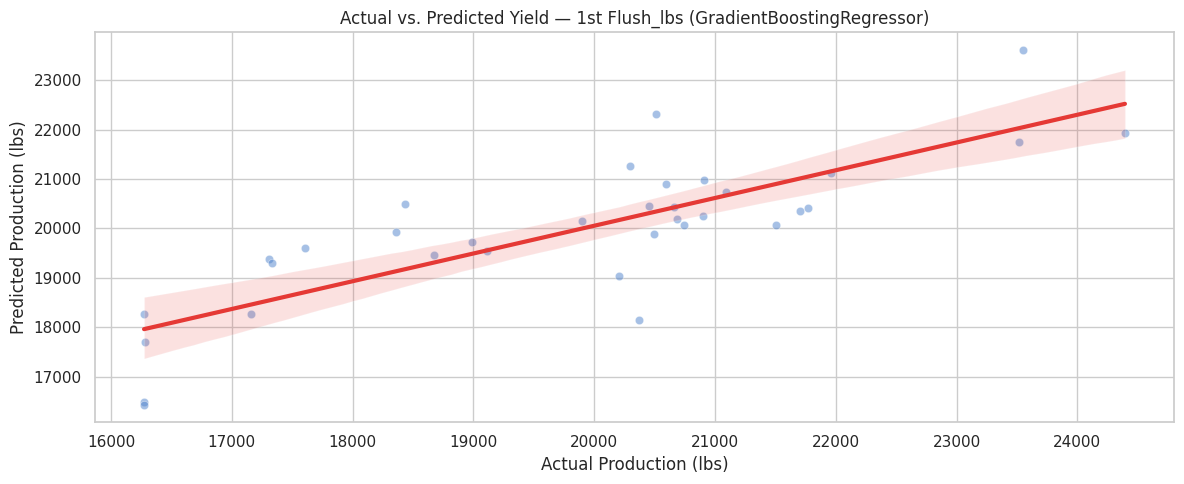


TARGET: 2nd Flush_lbs | Final model: RandomForestRegressor
Test metrics -> R2: 0.4209 | RMSE: 908.9556 | MAE: 708.9431



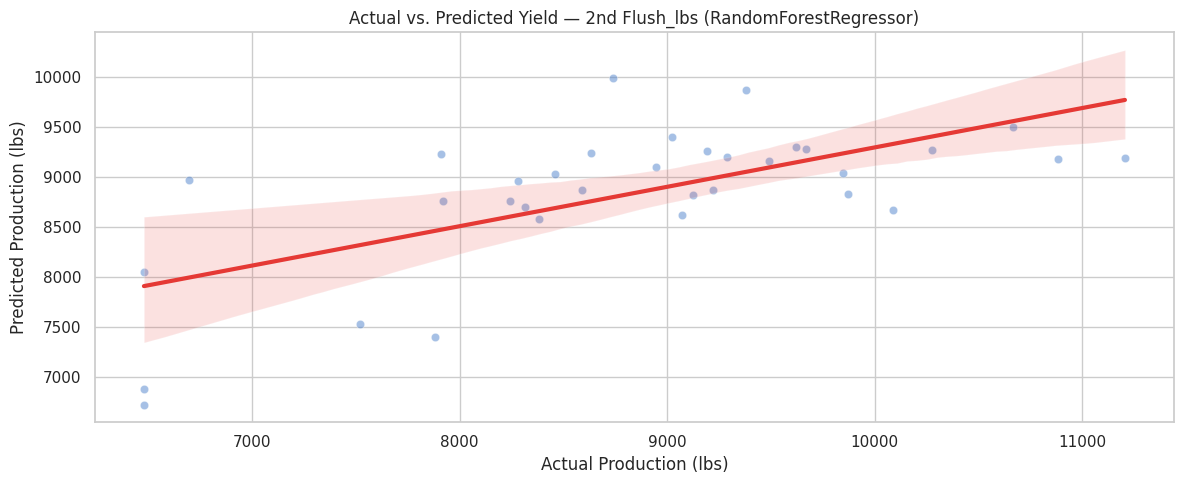


TARGET: 3rd Flush_lbs | Final model: RandomForestRegressor
Test metrics -> R2: 0.3650 | RMSE: 496.9407 | MAE: 378.6736



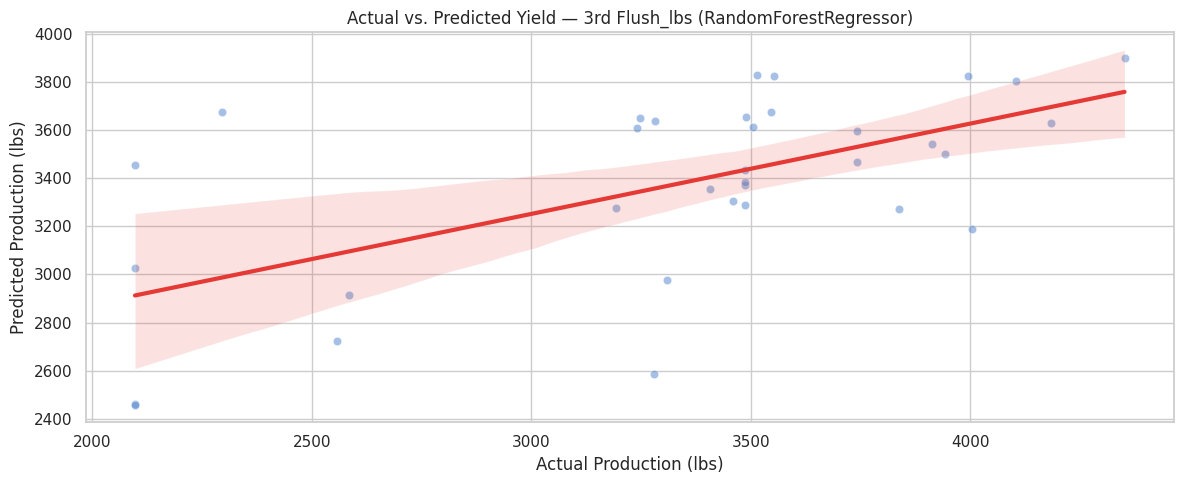

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

for target, model in fitted_best_models.items():
    # Retrieve test data for the current target from processed_data_store_no_pca
    # The format is (X_train, X_test, y_train, y_test, scaler, pca_model)
    _, X_test_data, _, y_test_data, _, _ = processed_data_store_no_pca[target]

    y_true = y_test_data # Actual values
    y_pred = model.predict(X_test_data) # Predicted values

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    model_name = best_models_config[target]["Model_Name"]

    print("\n===================================================")
    print(f"TARGET: {target} | Final model: {model_name}")
    print(f"Test metrics -> R2: {r2:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")
    print("===================================================\n")

    plt.figure(figsize=(12, 5))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.5, color="#4f83cc")
    sns.regplot(
        x=y_true,
        y=y_pred,
        scatter=False,
        color="#e53935",
        line_kws={"linewidth": 3},
        ci=95
    )

    plt.title(f"Actual vs. Predicted Yield \u2014 {target} ({model_name})")
    plt.xlabel("Actual Production (lbs)")
    plt.ylabel("Predicted Production (lbs)")
    plt.tight_layout()
    plt.show()

**1st Flush_lbs — Actual vs. Predicted Yield (GradientBoostingRegressor)**

This plot shows a clear positive relationship between actual and predicted production for the first flush, which indicates that the model is capturing the main production pattern reasonably well. Most observations follow the expected trend, although there is still some dispersion, especially in a few medium- and high-yield cases.

From a business perspective, this is useful because the first flush usually represents the largest share of total production, so having a model that tracks this trend can support better harvest planning, labor allocation, packaging preparation, and short-term sales commitments. The remaining spread suggests that the model should be used as a decision-support tool rather than as an exact forecast for every individual case.

**2nd Flush_lbs — Actual vs. Predicted Yield (RandomForestRegressor)**

For the second flush, the model also captures the general upward trend between actual and predicted yield, but the points appear more concentrated in a narrower prediction range. This suggests that the model recognizes the main direction of production changes, although it may smooth some variability and be less sensitive to very low or very high outcomes.

This means the model can still provide value for estimating expected second-flush production and improving operational planning, especially for labor, logistics, and inventory timing. However, because some extreme cases are not fully separated, managers should treat these predictions as an approximate planning reference and complement them with field knowledge when making higher-risk decisions.

**3rd Flush_lbs — Actual vs. Predicted Yield (RandomForestRegressor)**

This graph shows a positive relationship between actual and predicted yield for the third flush, meaning the model is able to detect the general production pattern even in a later and usually more variable harvest stage. At the same time, the dispersion around the trend line suggests that prediction uncertainty is higher for some observations, which is expected because third-flush yields are often smaller and less stable.

From a business perspective, this model is still valuable because it helps estimate whether the third flush is likely to produce enough output to justify labor, harvesting effort, and downstream handling. Even if predictions are not perfectly precise, they can support more informed operational decisions about resource allocation and production expectations in the final stage of the crop cycle.

### 2) Residuals vs Predicted


TARGET: 1st Flush_lbs | Final model: GradientBoostingRegressor
Test metrics -> R2: 0.6391 | RMSE: 1276.2761 | MAE: 1047.0434



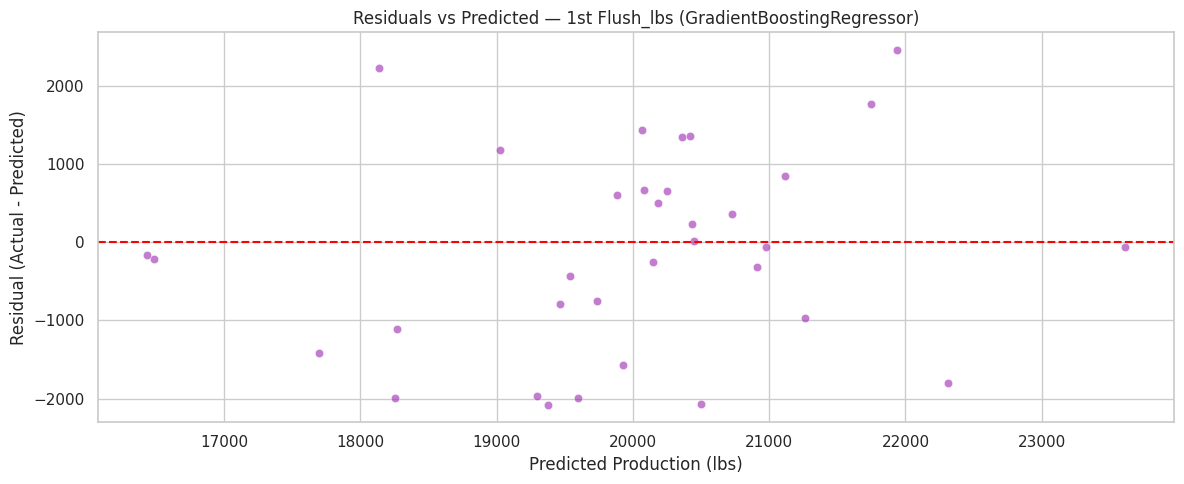


TARGET: 2nd Flush_lbs | Final model: RandomForestRegressor
Test metrics -> R2: 0.4209 | RMSE: 908.9556 | MAE: 708.9431



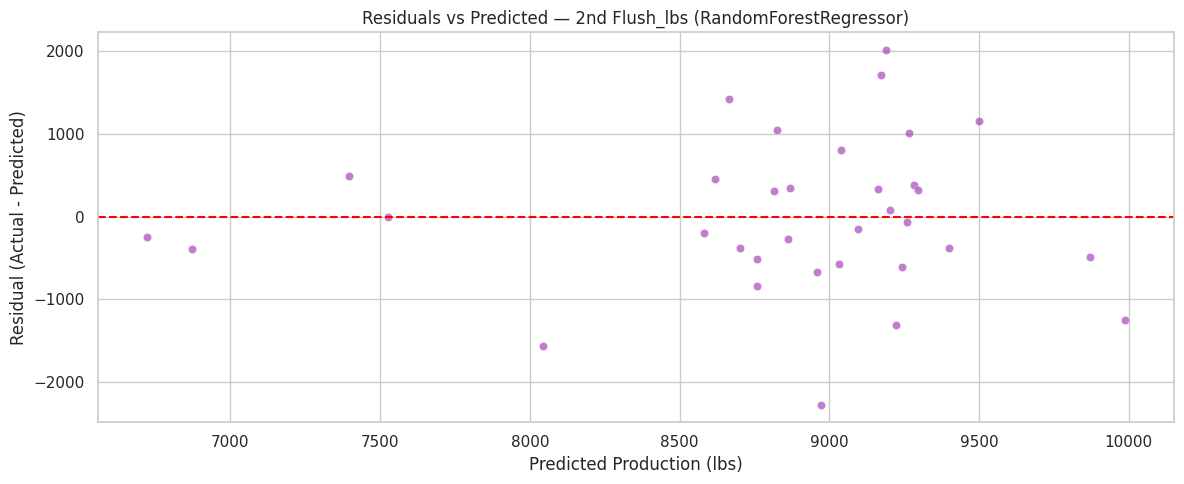


TARGET: 3rd Flush_lbs | Final model: RandomForestRegressor
Test metrics -> R2: 0.3650 | RMSE: 496.9407 | MAE: 378.6736



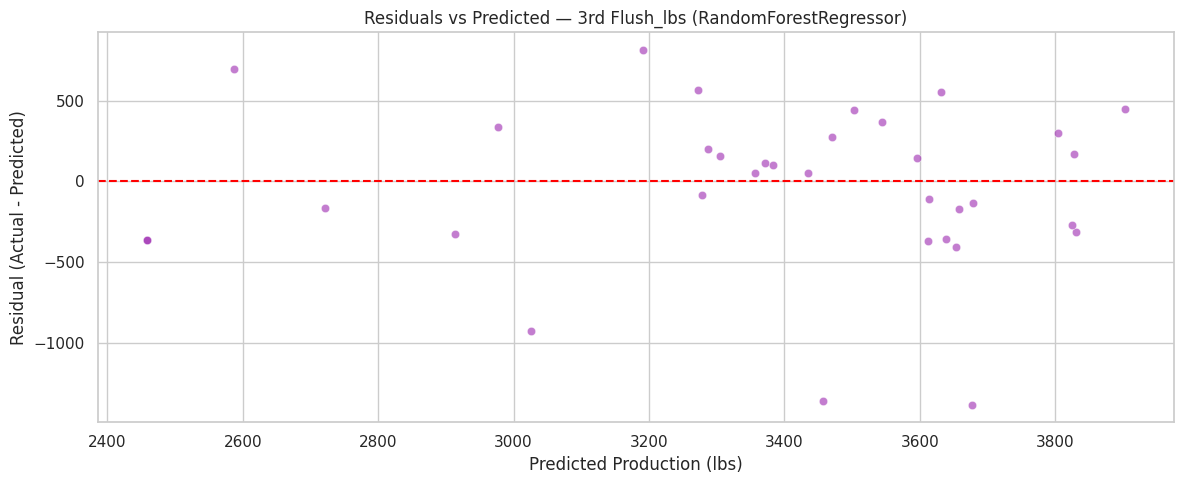

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

for target, model in fitted_best_models.items():
    # Retrieve test data for the current target from processed_data_store_no_pca
    # The format is (X_train, X_test, y_train, y_test, scaler, pca_model)
    _, X_test_data, _, y_test_data, _, _ = processed_data_store_no_pca[target]

    y_true = y_test_data # Actual values
    y_pred = model.predict(X_test_data) # Predicted values
    residuals = y_true - y_pred
    model_name = best_models_config[target]["Model_Name"]

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print("\n===================================================")
    print(f"TARGET: {target} | Final model: {model_name}")
    print(f"Test metrics -> R2: {r2:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")
    print("===================================================\n")

    plt.figure(figsize=(12, 5))
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.6, color="#9c27b0")
    plt.axhline(0, color="red", linestyle="--")

    plt.title(f"Residuals vs Predicted \u2014 {target} ({model_name})")
    plt.xlabel("Predicted Production (lbs)")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.tight_layout()
    plt.show()

**1st Flush_lbs — Residuals vs Predicted (GradientBoostingRegressor)**

Residuals are mostly distributed around zero, which suggests that the model does not show a strong systematic bias. However, some larger positive and negative errors are still present, meaning that a few cases are notably underpredicted or overpredicted.

From a business perspective, this means the model is useful for first-flush planning, such as labor, harvest scheduling, and sales preparation, but it should be used with some operational flexibility for unusual cases.

**2nd Flush_lbs — Residuals vs Predicted (RandomForestRegressor)**

Residuals are also generally centered around zero, which indicates that the model is not consistently overestimating or underestimating production. Still, the spread of errors shows that prediction accuracy varies across observations.

From a business perspective, the model is valuable for general planning and expected supply estimation, but it should be treated as a support tool rather than an exact forecast in more sensitive decisions.

**3rd Flush_lbs — Residuals vs Predicted (RandomForestRegressor)**

The residuals for the third flush are also reasonably centered around zero, suggesting no severe systematic bias. Some larger errors remain, which is expected because later flushes tend to be more variable.

From a business perspective, the model still helps estimate whether remaining production justifies labor and harvesting effort, although decisions should remain cautious due to the higher uncertainty at this stage.

### 3) Residual Distribution

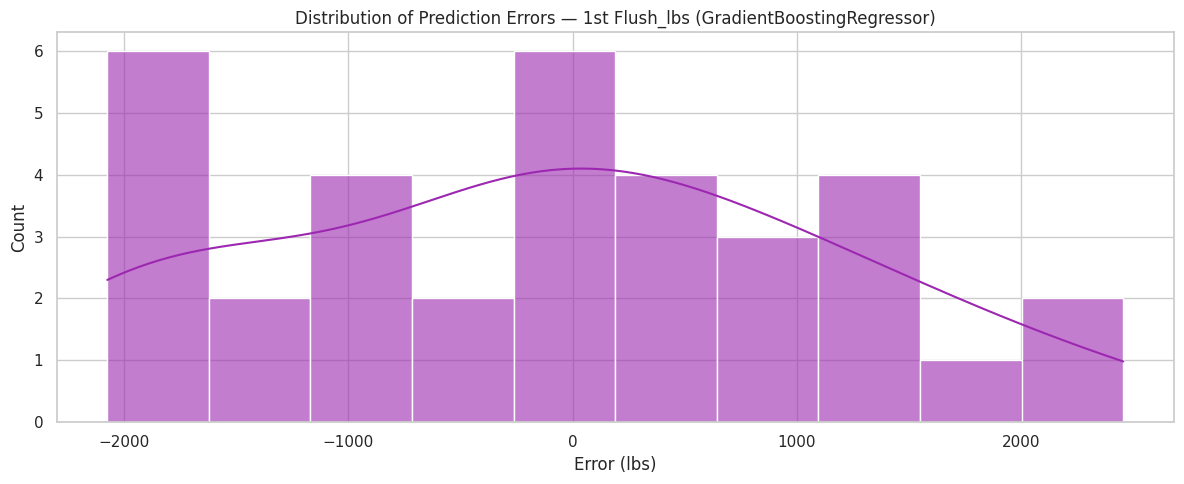

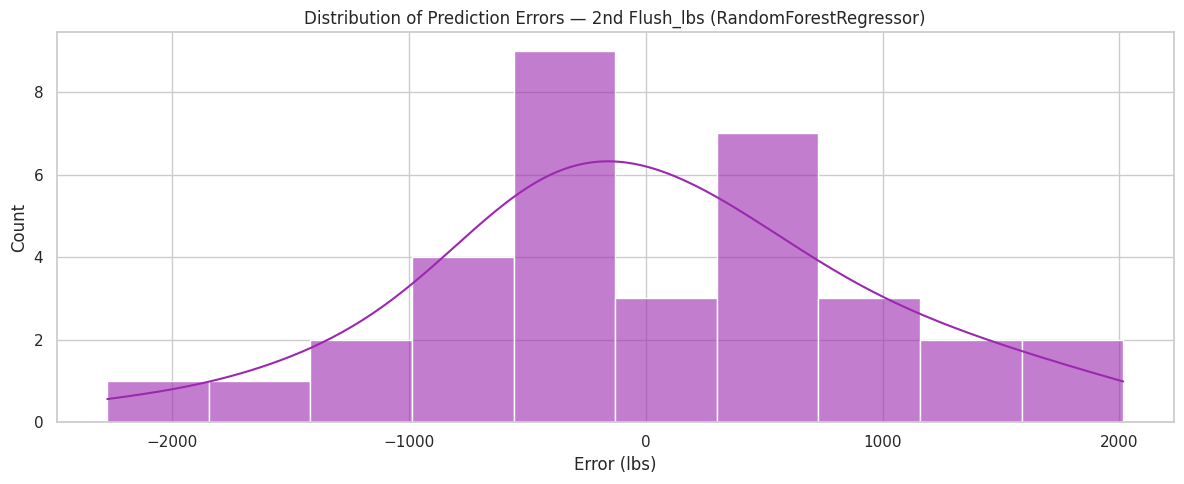

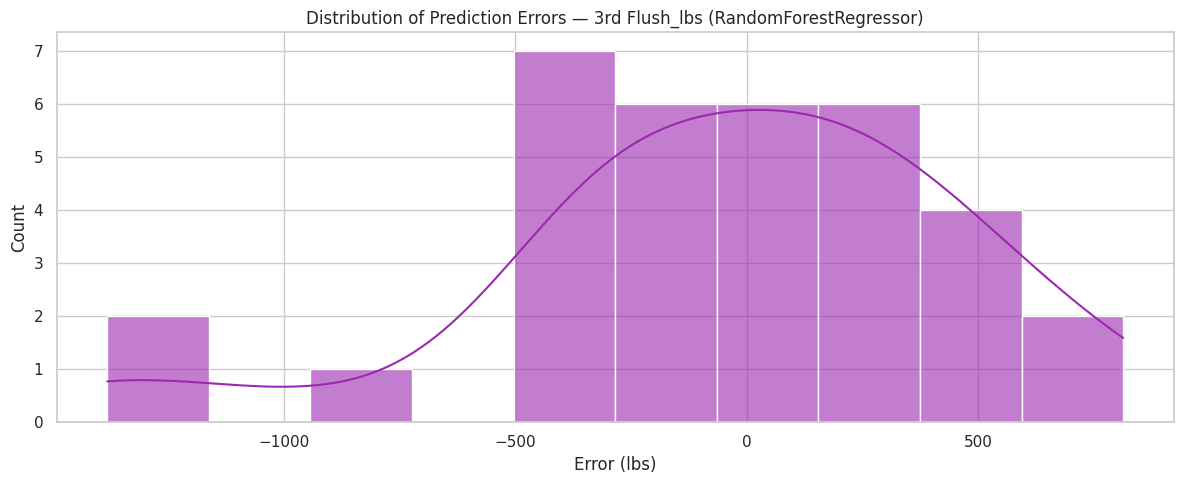

In [48]:
for target, model in fitted_best_models.items():
    # Retrieve test data for the current target from processed_data_store_no_pca
    # The format is (X_train, X_test, y_train, y_test, scaler, pca_model)
    _, X_test_data, _, y_test_data, _, _ = processed_data_store_no_pca[target]

    y_true = y_test_data # Actual values
    y_pred = model.predict(X_test_data) # Predicted values
    residuals = y_true - y_pred
    model_name = best_models_config[target]["Model_Name"]

    plt.figure(figsize=(12, 5))
    sns.histplot(
        residuals,
        bins=10,
        kde=True,
        color="#9c27b0",
        alpha=0.6,
        edgecolor="white"
    )
    plt.title(f"Distribution of Prediction Errors — {target} ({model_name})")
    plt.xlabel("Error (lbs)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

> Note: Some bars may appear missing or uneven because the test sample is relatively small and the residuals are not evenly distributed across all intervals. This means that some bins contain very few observations or none at all, which is normal in a histogram and does not indicate an error in the analysis.

**1st Flush_lbs — Distribution of Prediction Errors (GradientBoostingRegressor)**

Most errors are concentrated around zero, which suggests that the model is reasonably balanced and does not show a strong overall bias. However, the presence of some larger positive and negative errors indicates that a few first-flush cases are still harder to predict.

From a business perspective, this means the model is useful for planning expected first-flush output, but some buffer should remain in staffing, packaging, and commercial commitments.

**2nd Flush_lbs — Distribution of Prediction Errors (RandomForestRegressor)**

The error distribution is also centered near zero, which suggests that the model provides a generally balanced forecast for the second flush. At the same time, the spread shows that some observations still have noticeable prediction error.

From a business perspective, this supports using the model for operational planning and supply estimation, while still leaving room for adjustment in cases with higher uncertainty.

**3rd Flush_lbs — Distribution of Prediction Errors (RandomForestRegressor)**

The third-flush errors are mostly concentrated around zero, although there are still some larger deviations on both sides. This is expected because later flushes are usually more variable and harder to predict.

From a business perspective, the model remains valuable for estimating remaining production and deciding how much effort to allocate to the final harvest stage, but with cautious expectations.

### 4) Feature Importance (Permutation Importance)

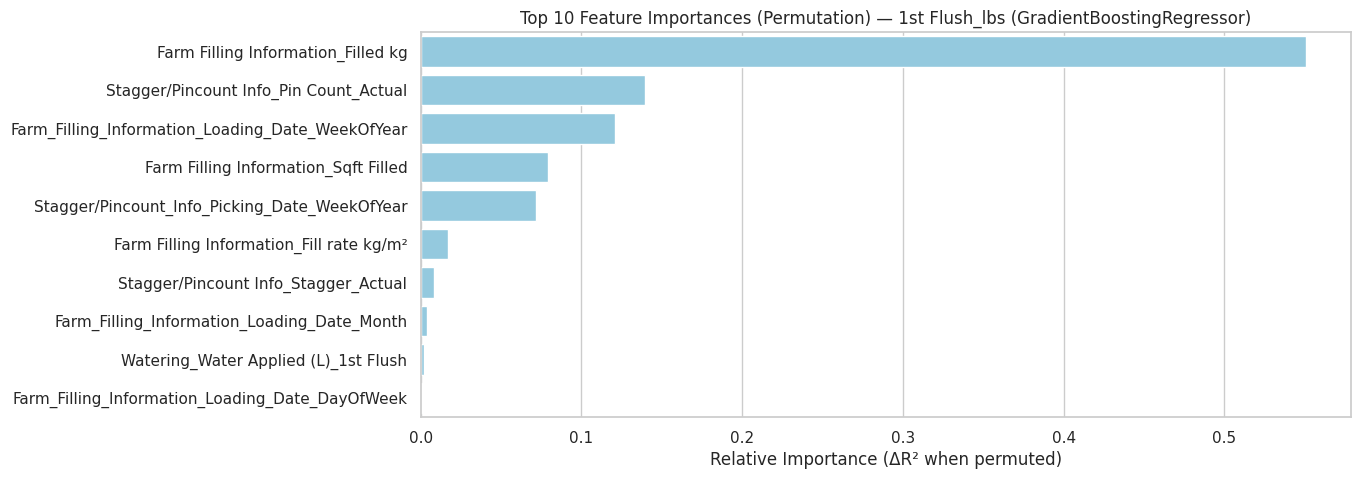

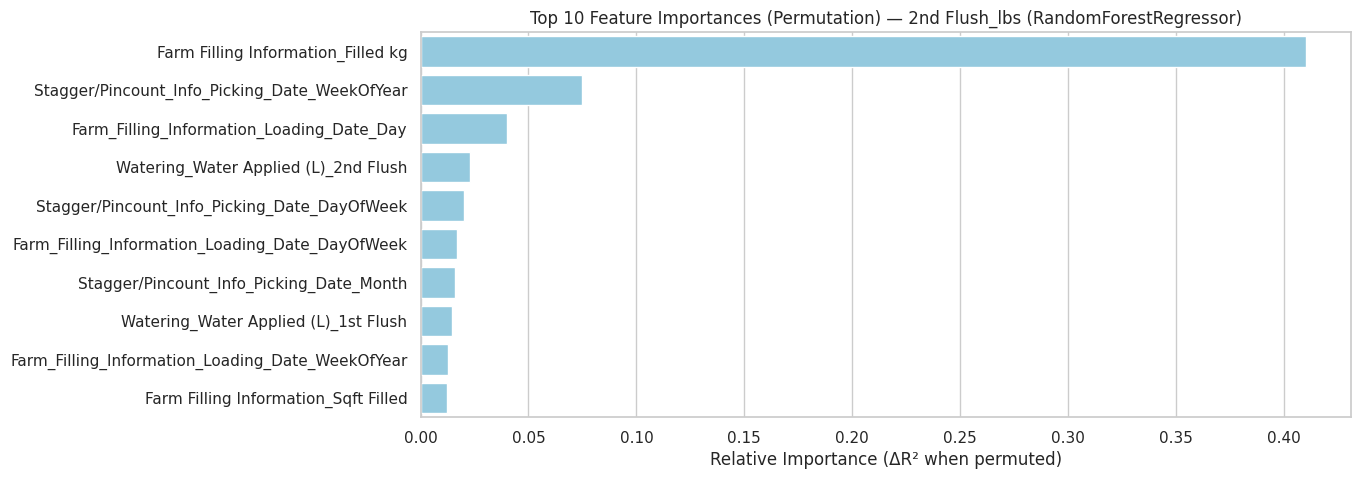

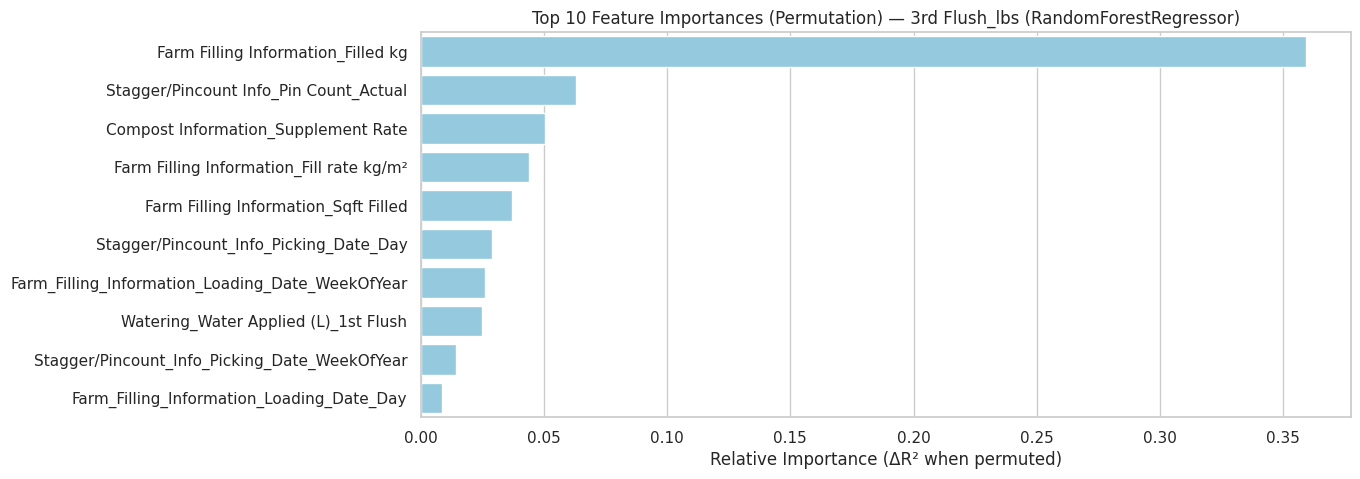

In [49]:
TOP_N = 10

for target, model in fitted_best_models.items():
    # Retrieve test data for the current target from processed_data_store_no_pca
    # The format is (X_train, X_test, y_train, y_test, scaler, pca_model)
    _, X_test_data, _, y_test_data, _, _ = processed_data_store_no_pca[target]

    y_true = y_test_data # Actual values
    model_name = best_models_config[target]["Model_Name"]

    perm = permutation_importance(
        model,
        X_test_data,
        y_true,
        n_repeats=10,
        random_state=42,
        scoring="r2",
        n_jobs=-1
    )

    if isinstance(X_test_data, pd.DataFrame):
        importances = pd.Series(
            perm.importances_mean,
            index=X_test_data.columns
        ).sort_values(ascending=False)
    else:
        importances = pd.Series(
            perm.importances_mean,
            index=[f"Feature_{i}" for i in range(X_test_data.shape[1])]
        ).sort_values(ascending=False)

    top_imp = importances.head(TOP_N)

    df_imp = top_imp.reset_index()
    df_imp.columns = ["Feature", "Importance"]
    df_imp = df_imp.sort_values("Importance", ascending=False)

    plt.figure(figsize=(12, 5))
    sns.barplot(
        data=df_imp,
        x="Importance",
        y="Feature",
        color="#87ceeb",
        edgecolor="white"
    )
    plt.title(f"Top {TOP_N} Feature Importances (Permutation) \u2014 {target} ({model_name})")
    plt.xlabel("Relative Importance (\u0394R\u00b2 when permuted)")
    plt.ylabel("")
    plt.show()

    top_features = ", ".join(df_imp["Feature"].head(3).tolist())

**1st Flush_lbs — Permutation Feature Importance (GradientBoostingRegressor)**

**Filled kg** is the most important variable for predicting first-flush yield, followed by **Pin Count** and some watering and pin-count variables. This means the model is mainly driven by farm loading conditions and early production factors.

From a business perspective, this suggests that improving control over filling volume, space utilization, and early crop conditions could have the greatest impact on first-flush output.

**2nd Flush_lbs — Permutation Feature Importance ('RandomForestRegressor')**

**Filled kg** remains the strongest predictor, while 2nd flush watering variable is also important. This indicates that second-flush performance depends on both the initial load and water management during the cycle.

From a business perspective, this helps identify where operational control can improve production consistency and planning for later harvests.

**3rd Flush_lbs — Permutation Feature Importance (RandomForestRegressor)**

**Filled kg** is again the most influential variable, followed by pin count, supplement rate and fill rate. This shows that even late-stage production is still linked to controllable process variables.

From a business perspective, this helps managers focus on early-cycle decisions that can improve total yield and better judge whether the final flush is worth the remaining effort and cost.

## SHAP Plots

Let's create SHAP plots for the 2nd and 3rd flushes, the main target values where the company has some difficulty predicting the outcome. With these plots we will be able to see some of the features that have most importance for our best models.


--- Generating SHAP for specific model: 2nd Flush_lbs - RandomForestRegressor (Tuned, without PCA) ---
  Generating SHAP values for RandomForestRegressor (Tuned, without PCA).
  Displaying SHAP summary plot for RandomForestRegressor (Tuned, without PCA).


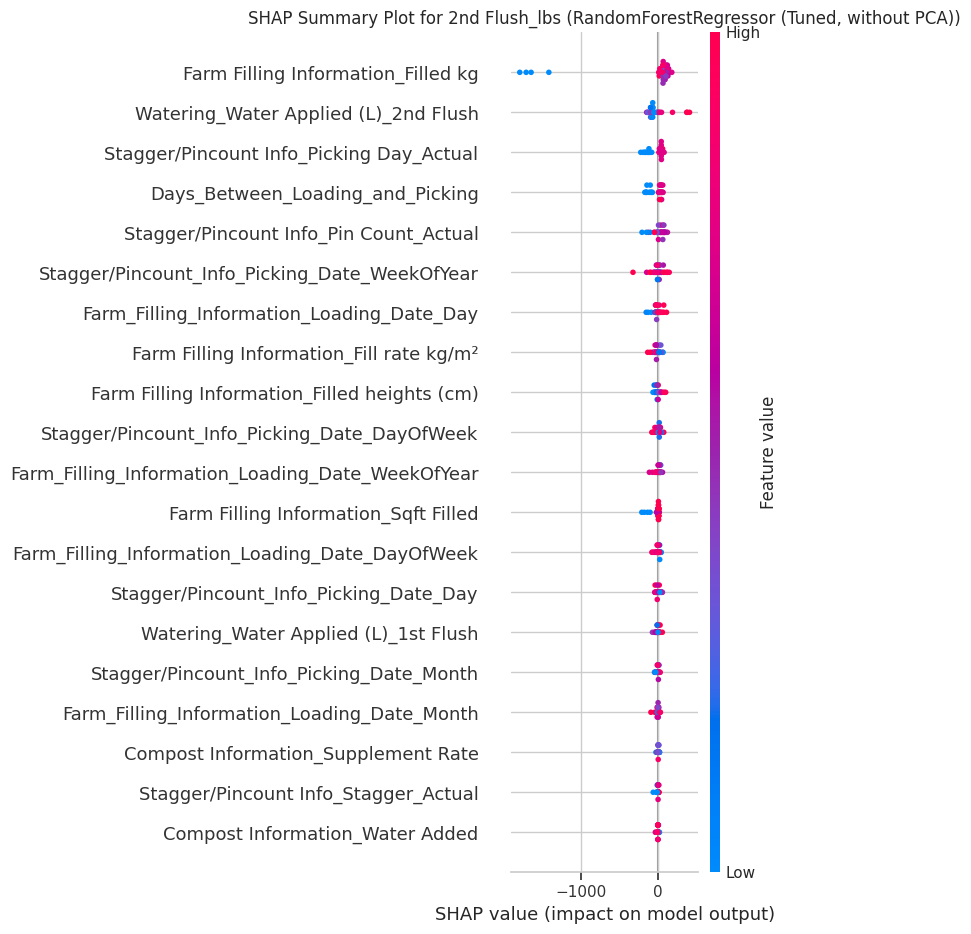


Finished generating specific SHAP plot.


In [50]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

specific_target = '2nd Flush_lbs'
specific_model_type = 'RandomForestRegressor'
specific_model_full_name = specific_model_type + ' (Tuned, without PCA)' # Adjusted for AdaBoostRegressor (Tuned, without PCA)

print(f"\n--- Generating SHAP for specific model: {specific_target} - {specific_model_full_name} ---")

# Retrieve the already fitted model from the dictionary
fitted_model = fitted_best_models.get(specific_target)

if fitted_model is None:
    print(f"Error: Fitted model for {specific_target} not found in fitted_best_models.")
else:
    # Retrieve test and train data for the current target from processed_data_store_no_pca
    X_train_data, X_test_data, y_train_data, y_test_data, scaler, _ = processed_data_store_no_pca[specific_target]

    # -------------------------------------------------------
    # Ensure X_test_data is in DataFrame format for SHAP and numeric
    # -------------------------------------------------------
    X_test_shap = X_test_data.copy()
    X_train_shap = X_train_data.copy()

    # For models like AdaBoost, we often refit the model on the full training data
    # before generating SHAP values, using the hyperparameters from best_models_config.
    # This ensures consistency and proper behavior of the explainer.
    model_config = best_models_config[specific_target]
    refitted_model = _create_base_model_instance(model_config['Model_Name'], model_config['Hyperparameters'])
    refitted_model.fit(X_train_shap, y_train_data)

    # -------------------------------------------------------
    # Generate SHAP values
    # -------------------------------------------------------
    print(f"  Generating SHAP values for {specific_model_full_name}.")

    try:
        # AdaBoostRegressor (with default DecisionTreeRegressor base) is tree-based.
        # TreeExplainer is more efficient for tree-based models.
        explainer = shap.TreeExplainer(refitted_model)

        # For tree explainers, shap_values can be directly calculated on X_test_shap
        # Take a sample if X_test_shap is too large for performance, but 50-item sample for background_data is usually sufficient
        if X_test_shap.shape[0] > 100: # Example threshold for sampling
            X_explain_sample = shap.sample(X_test_shap, 50, random_state=42)
            shap_values = explainer.shap_values(X_explain_sample)
        else:
            shap_values = explainer.shap_values(X_test_shap)

        print(f"  Displaying SHAP summary plot for {specific_model_full_name}.")
        plt.figure(figsize=(10, 8))
        # If shap_values is a list (for multi-output models like some tree explainers), use the first element
        if isinstance(shap_values, list):
            shap.summary_plot(shap_values[0], X_test_shap if X_test_shap.shape[0] <= 100 else X_explain_sample, show=False)
        else:
            shap.summary_plot(shap_values, X_test_shap if X_test_shap.shape[0] <= 100 else X_explain_sample, show=False)
        plt.title(f"SHAP Summary Plot for {specific_target} ({specific_model_full_name})")
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"SHAP TreeExplainer failed: {e}")
        print("Trying KernelExplainer as fallback...")

        # Fallback to KernelExplainer which is model-agnostic
        background_data = shap.sample(X_train_shap, min(50, len(X_train_shap)), random_state=42)
        # For KernelExplainer, the explainer function should take input features and return predictions
        # Ensure it works correctly with the refitted_model
        explainer = shap.KernelExplainer(refitted_model.predict, background_data)

        X_explain_sample = shap.sample(X_test_shap, min(50, len(X_test_shap)), random_state=42)
        shap_values = explainer.shap_values(X_explain_sample, nsamples=100) # nsamples for approximation quality

        plt.figure(figsize=(10, 8))
        if isinstance(shap_values, list):
            shap.summary_plot(shap_values[0], X_explain_sample, show=False)
        else:
            shap.summary_plot(shap_values, X_explain_sample, show=False)
        plt.title(f"SHAP Summary Plot (KernelExplainer) for {specific_target} ({specific_model_full_name})")
        plt.tight_layout()
        plt.show()

print("\nFinished generating specific SHAP plot.")


--- Generating SHAP for specific model: 3rd Flush_lbs - RandomForestRegressor (Tuned, without PCA) ---
  Generating SHAP values for RandomForestRegressor (Tuned, without PCA)...
  Displaying SHAP summary plot for RandomForestRegressor (Tuned, without PCA).


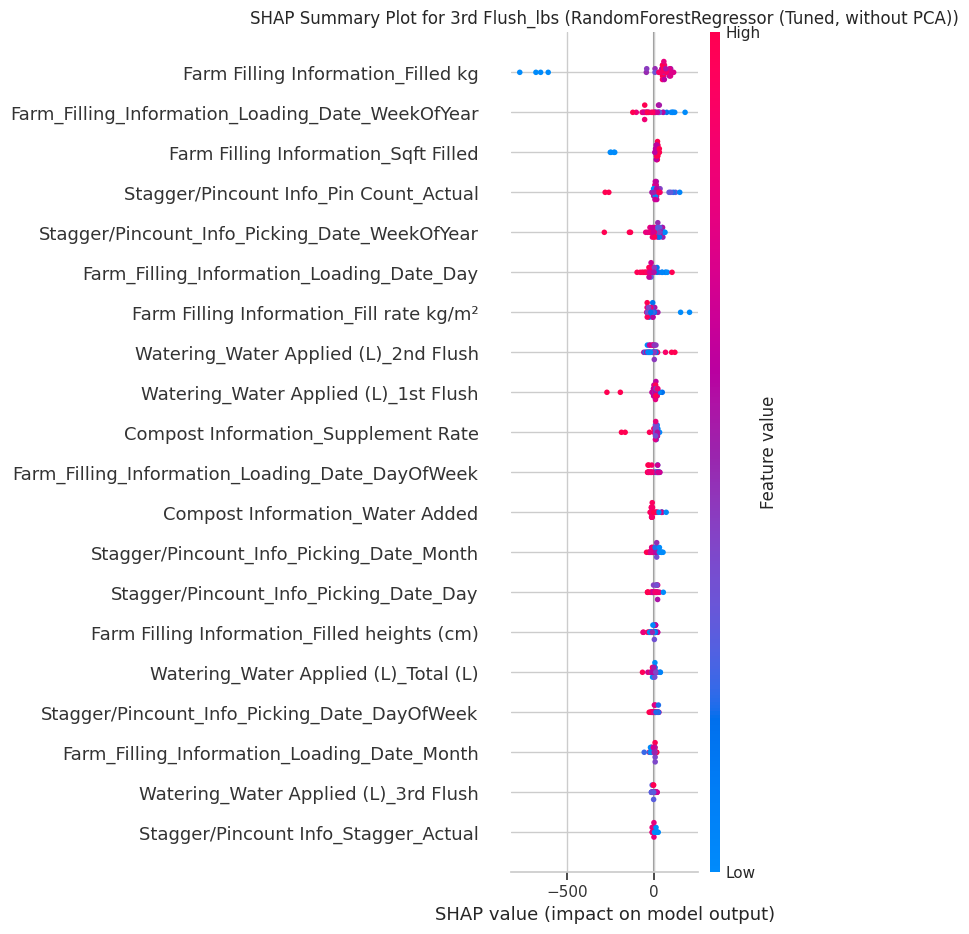


Finished generating specific SHAP plot.


In [51]:
import shap
import matplotlib.pyplot as plt

# Generate SHAP plot for the specific model requested by the user: '2nd Flush RandomForestRegressor (without PCA)'

# Define the specific target and model type
specific_target = '3rd Flush_lbs'
specific_model_type = 'RandomForestRegressor'
specific_model_full_name = specific_model_type + ' (Tuned, without PCA)'

print(f"\n--- Generating SHAP for specific model: {specific_target} - {specific_model_full_name} ---")

# Helper function to reconstruct a model given its name and parameters
def reconstruct_model(model_name_full, params):
    if 'RandomForestRegressor' in model_name_full:
        return RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    elif 'Ridge' in model_name_full:
        return Ridge(**params, random_state=42)
    elif 'Lasso' in model_name_full:
        return Lasso(**params, random_state=42)
    elif 'DecisionTreeRegressor' in model_name_full:
        return DecisionTreeRegressor(**params, random_state=42)
    elif 'KNeighborsRegressor' in model_name_full:
        return KNeighborsRegressor(**params)
    elif 'SVR' in model_name_full:
        return SVR(**params)
    elif 'GradientBoostingRegressor' in model_name_full:
        return GradientBoostingRegressor(**params, random_state=42)
    elif 'Linear Regression' in model_name_full:
        return LinearRegression()
    else:
        raise ValueError(f"Unknown model type for reconstruction: {model_name_full}")

# Get the model entry from the tuned results (without PCA) for the specific model and target
model_entry = tuned_results_no_pca_df[
    (tuned_results_no_pca_df['Target'] == specific_target) &
    (tuned_results_no_pca_df['Model'] == specific_model_type)
]

if model_entry.empty:
    print(f"Error: Tuned {specific_model_type} for {specific_target} not found in tuned_results_no_pca_df.")
else:
    model_entry = model_entry.iloc[0]
    best_params = model_entry['Tuned_Best_Params']

    # Retrieve test and train data for the current target from processed_data_store_no_pca
    # The format is (X_train, X_test, y_train, y_test, scaler, pca_model)
    X_train_data, X_test_data, y_train_data, y_test_data, _, _ = processed_data_store_no_pca[specific_target]

    # Reconstruct the fitted model
    fitted_model = reconstruct_model(specific_model_type, best_params)
    fitted_model.fit(X_train_data, y_train_data)

    print(f"  Generating SHAP values for {specific_model_full_name}...")

    # Determine explainer type (RandomForestRegressor is tree-based)
    explainer = shap.TreeExplainer(fitted_model)

    # Calculate SHAP values
    try:
        shap_values = explainer.shap_values(X_test_data)
    except Exception as e:
        print(f"  Error calculating SHAP values: {e}. Trying a smaller sample of X_test_data.")
        if X_test_data.shape[0] > 50:
            shap_values = explainer.shap_values(shap.sample(X_test_data, 50, random_state=42))
        else:
            raise e

    print(f"  Displaying SHAP summary plot for {specific_model_full_name}.")
    plt.figure(figsize=(10, 8))
    if isinstance(shap_values, list):
        shap.summary_plot(shap_values[0], X_test_data, show=False)
    else:
        shap.summary_plot(shap_values, X_test_data, show=False)
    plt.title(f"SHAP Summary Plot for {specific_target} ({specific_model_full_name})")
    plt.tight_layout()
    plt.show()

print("\nFinished generating specific SHAP plot.")

## Creation of HMI for customer to use model


Let's redefine the feature set `X` by dropping specified columns from `df_cleaned`, including target variables, previously excluded columns, and specific 'Stagger/Pincount' columns, to retain only controllable features for prediction. We will then filter `X` to ensure it contains only numerical data types and print its shape and columns to verify the changes.



In [52]:
import pandas as pd
import numpy as np

# 1. Define target variables (y)
target_columns = ['1st Flush_lbs', '2nd Flush_lbs', '3rd Flush_lbs']
y = df_cleaned[target_columns].copy()

# 2. Define controllable features explicitly
controllable_features = [
    'Compost Information_Spawn Rate',
    'Compost Information_Supplement Rate',
    'Compost Information_Water Added',
    'Farm Filling Information_Sqft Filled',
    'Farm Filling Information_Missing Sections',
    'Farm Filling Information_Filled heights (cm)',
    'Farm Filling Information_Filled kg',
    'Farm Filling Information_Fill rate kg/m²',
    'Watering_Water Applied (L)_1st Flush',
    'Watering_Water Applied (L)_2nd Flush',
    'Watering_Water Applied (L)_3rd Flush',
    'Watering_Water Applied (L)_Total (L)',
    'Farm_Filling_Information_Loading_Date_Year',
    'Days_Between_Loading_and_Picking'
]

# 3. Create X by selecting these controllable features
X = df_cleaned[controllable_features].copy()

# 4. Ensure only numerical and engineered categorical columns remain in X
X = X.select_dtypes(include=[np.number, pd.Int64Dtype()])

# 5. Print the shape of the new X DataFrame and a list of its column names
print(f"Shape of X after selecting controllable features: {X.shape}")
print("New X columns:")
for col in X.columns.tolist():
    print(f"- {col}")

Shape of X after selecting controllable features: (170, 14)
New X columns:
- Compost Information_Spawn Rate
- Compost Information_Supplement Rate
- Compost Information_Water Added
- Farm Filling Information_Sqft Filled
- Farm Filling Information_Missing Sections
- Farm Filling Information_Filled heights (cm)
- Farm Filling Information_Filled kg
- Farm Filling Information_Fill rate kg/m²
- Watering_Water Applied (L)_1st Flush
- Watering_Water Applied (L)_2nd Flush
- Watering_Water Applied (L)_3rd Flush
- Watering_Water Applied (L)_Total (L)
- Farm_Filling_Information_Loading_Date_Year
- Days_Between_Loading_and_Picking


In [53]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# 3. Rerun Data Preparation (without PCA)
# Re-run data splitting and transformations without PCA
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Identify numerical columns in X_train for transformations
numerical_cols_X = X_train.columns

# Apply log1p transformation to numerical columns in X_train and X_test
for col in numerical_cols_X:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])

# --- ADDED: Impute NaNs introduced by log1p (e.g., from log1p(-1)) ---
for col in numerical_cols_X:
    if X_train[col].isnull().any():
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
    if X_test[col].isnull().any():
        # Use median from X_train to avoid data leakage
        median_val = X_train[col].median()
        X_test[col] = X_test[col].fillna(median_val)
# -------------------------------------------------------------------

# Store X_train and X_test before PCA for the 'no PCA' scenario
X_train_pre_pca = X_train.copy()
X_test_pre_pca = X_test.copy()

# Remove constant columns (zero variance) before scaling
constant_columns = X_train.columns[X_train.std() == 0]
if len(constant_columns) > 0:
    X_train_pre_pca = X_train_pre_pca.drop(columns=constant_columns)
    X_test_pre_pca = X_test_pre_pca.drop(columns=constant_columns)
    print(f"Removed constant columns with zero variance: {list(constant_columns)}")
else:
    print("No constant columns with zero variance found.")

# Initialize StandardScaler, fit on X_train_pre_pca, and transform both
scaler = StandardScaler()

X_train_scaled_array = scaler.fit_transform(X_train_pre_pca)
X_test_scaled_array = scaler.transform(X_test_pre_pca)

# Convert scaled arrays back to DataFrame, retaining column names and index
X_train_pre_pca = pd.DataFrame(X_train_scaled_array, columns=X_train_pre_pca.columns, index=X_train_pre_pca.index)
X_test_pre_pca = pd.DataFrame(X_test_scaled_array, columns=X_test_pre_pca.columns, index=X_test_pre_pca.index)

print("Applied StandardScaler to numerical columns.")
print(f"Final shape of X_train_pre_pca: {X_train_pre_pca.shape}")
print(f"Final shape of X_test_pre_pca: {X_test_pre_pca.shape}")


Shape of X_train: (136, 14)
Shape of X_test: (34, 14)
Shape of y_train: (136, 3)
Shape of y_test: (34, 3)
No constant columns with zero variance found.
Applied StandardScaler to numerical columns.
Final shape of X_train_pre_pca: (136, 14)
Final shape of X_test_pre_pca: (34, 14)


Now, we will reconstruct and fit the best models ('GradientBoostingRegressor' for 1st flush, and 'RandomForestRegressor' for 2nd and 3rd flushes) using the `X_train_pre_pca` data (scaled and log1p-transformed without PCA) and the respective target variables from `y_train`. These fitted models will be stored in the `fitted_best_models` dictionary.



In [54]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor, AdaBoostRegressor
import numpy as np

# Dictionary to store the fitted best models
fitted_best_models = {}

# Helper function to create individual model instances with hyperparameters
def _create_base_model_instance(model_name, params):
    if model_name == 'DecisionTreeRegressor':
        return DecisionTreeRegressor(random_state=42, **params)
    elif model_name == 'RandomForestRegressor':
        return RandomForestRegressor(random_state=42, n_jobs=-1, **params)
    elif model_name == 'Lasso':
        return Lasso(random_state=42, **params)
    elif model_name == 'Ridge':
        return Ridge(random_state=42, **params)
    elif model_name == 'SVR':
        return SVR(**params)
    elif model_name == 'KNeighborsRegressor':
        return KNeighborsRegressor(**params)
    elif model_name == 'GradientBoostingRegressor':
        return GradientBoostingRegressor(random_state=42, **params)
    elif model_name == 'AdaBoostRegressor':
        return AdaBoostRegressor(random_state=42, **params)
    elif model_name == 'Linear Regression': # Assuming default Linear Regression
        return LinearRegression()
    else:
        raise ValueError(f"Unknown model type for base estimator reconstruction: {model_name}")

# Helper function to reconstruct and fit a model
def reconstruct_and_fit_model_v2(config, X_train_data, y_train_target):
    model_name = config['Model_Name']
    hyperparameters = config.get('Hyperparameters', {})

    model = None
    if model_name == 'DecisionTreeRegressor':
        model = _create_base_model_instance(model_name, hyperparameters)
    elif model_name == 'RandomForestRegressor':
        model = _create_base_model_instance(model_name, hyperparameters)
    elif model_name == 'AdaBoostRegressor':
        model = _create_base_model_instance(model_name, hyperparameters)
    elif model_name == 'GradientBoostingRegressor': # Added this condition
        model = _create_base_model_instance(model_name, hyperparameters)
    elif model_name == 'VotingRegressor':
        estimators = []
        for est_name, est_params in hyperparameters.get('estimators', []):
            # The `est_name` comes from the dictionary, e.g., 'decisiontree', 'randomforest'
            # We need to map it back to the full class name for _create_base_model_instance
            full_est_name = None
            if 'decisiontree' in est_name: full_est_name = 'DecisionTreeRegressor'
            elif 'randomforest' in est_name: full_est_name = 'RandomForestRegressor'
            elif 'lasso' in est_name: full_est_name = 'Lasso'
            elif 'ridge' in est_name: full_est_name = 'Ridge'
            elif 'svr' in est_name: full_est_name = 'SVR'
            elif 'kneighbors' in est_name: full_est_name = 'KNeighborsRegressor'
            elif 'gradientboosting' in est_name: full_est_name = 'GradientBoostingRegressor'
            elif 'adaboost' in est_name: full_est_name = 'AdaBoostRegressor'

            if full_est_name:
                estimators.append((est_name, _create_base_model_instance(full_est_name, est_params)))
            else:
                print(f"Warning: Could not identify full model name for base estimator '{est_name}'. Skipping.")

        weights = hyperparameters.get('weights')
        if estimators:
            model = VotingRegressor(estimators=estimators, weights=weights, n_jobs=-1)
        else:
            print(f"Warning: No valid estimators for VotingRegressor for target {y_train_target.name}. Skipping.")
            return None

    elif model_name == 'StackingRegressor':
        estimators = []
        for est_name, est_params in hyperparameters.get('estimators', []):
            # Map short name to full class name
            full_est_name = None
            if 'randomforest' in est_name: full_est_name = 'RandomForestRegressor'
            elif 'lasso' in est_name: full_est_name = 'Lasso'
            elif 'ridge' in est_name: full_est_name = 'Ridge'
            elif 'decisiontree' in est_name: full_est_name = 'DecisionTreeRegressor'
            elif 'adaboost' in est_name: full_est_name = 'AdaBoostRegressor'

            if full_est_name:
                estimators.append((est_name, _create_base_model_instance(full_est_name, est_params)))
            else:
                print(f"Warning: Could not identify full model name for base estimator '{est_name}'. Skipping.")

        final_estimator_config = hyperparameters.get('final_estimator', {})
        final_estimator_name = final_estimator_config.get('name')
        final_estimator_params = {k: v for k, v in final_estimator_config.items() if k != 'name'}

        final_estimator_instance = None
        if final_estimator_name == 'Ridge':
            final_estimator_instance = Ridge(**final_estimator_params)

        if estimators and final_estimator_instance:
            model = StackingRegressor(estimators=estimators, final_estimator=final_estimator_instance, n_jobs=-1)
        else:
            print(f"Warning: StackingRegressor for target {y_train_target.name} could not be fully configured. Skipping.")
            return None

    if model is None:
        print(f"Skipping model reconstruction for {model_name}. No Scikit-learn model equivalent or handler.")
        return None

    # Fit the model
    model.fit(X_train_data, y_train_target)
    return model

for target, config in best_models_config.items():
    print(f"Reconstructing and fitting model for {target}...")

    # For this specific task, all models are specified to be 'without PCA',
    # so we always use X_train_pre_pca
    X_data = X_train_pre_pca

    fitted_model = reconstruct_and_fit_model_v2(config, X_data, y_train[target])
    if fitted_model is not None:
        fitted_best_models[target] = fitted_model

print("\nFitted best models for each target variable (user-specified, no PCA):")
for target, model_obj in fitted_best_models.items():
    print(f"- {target}: {model_obj}")


Reconstructing and fitting model for 1st Flush_lbs...
Reconstructing and fitting model for 2nd Flush_lbs...
Reconstructing and fitting model for 3rd Flush_lbs...

Fitted best models for each target variable (user-specified, no PCA):
- 1st Flush_lbs: GradientBoostingRegressor(learning_rate=0.05, random_state=42)
- 2nd Flush_lbs: RandomForestRegressor(max_depth=10, max_features=0.6, n_jobs=-1,
                      random_state=42)
- 3rd Flush_lbs: RandomForestRegressor(max_depth=20, max_features=0.6, n_estimators=200,
                      n_jobs=-1, random_state=42)


Finally, let's create the interactive interface where the user is going to set the parameters the company wants to use for the prediction.

In [55]:
import ipywidgets as widgets
from IPython.display import display, HTML
import pandas as pd
import numpy as np
from datetime import datetime

# Re-define helper functions for input preprocessing, ensuring they are available in this scope
def parse_and_average_percentage(value):
    if isinstance(value, str) and value.strip():
        try:
            parts = value.replace('%', '').split('/')
            numbers = []
            for p in parts:
                try:
                    num = float(p.strip())
                    numbers.append(num / 100)
                except ValueError:
                    continue
            if numbers:
                return np.mean(numbers)
            else:
                return np.nan
        except Exception:
            return np.nan
    elif pd.isna(value):
        return np.nan
    else:
        return value

def parse_and_average_number(value):
    if isinstance(value, str) and value.strip():
        try:
            parts = value.split('/')
            numbers = []
            for p in parts:
                try:
                    numbers.append(float(p.strip()))
                except ValueError:
                    continue
            if numbers:
                return np.mean(numbers)
            else:
                return np.nan
        except Exception:
            return np.nan
    elif pd.isna(value):
        return np.nan
    else:
        return value

print("Preprocessing helper functions defined.")


# --- 1. Define Input Widgets for the Features in X_train_pre_pca ---

# Get the feature names in the correct order as expected by the models
# Use the controllable_features list defined in cell 42d6b5be
feature_names = controllable_features # Use the global controllable_features list

# Create a dictionary to hold input widgets
input_widgets = {}

# Recreate default values based on the *new* X features
def get_default_values():
    dv = {}
    for col in feature_names:
        if col in X.columns: # Use the original X (before log1p for medians) for default values
            if pd.api.types.is_numeric_dtype(X[col]):
                dv[col] = X[col].median()
            else:
                # These columns should now be numeric after earlier preprocessing, but as a fallback
                dv[col] = 0 # Fallback to 0 if not numeric or missing median
        else:
            dv[col] = 0 # Fallback for any unexpected new features
    return dv

current_default_values = get_default_values()

# Generate widgets, ensuring full names are displayed
for feature in feature_names:
    truncated_description = feature.replace('_', ' ').replace('( L)', '').replace('cm', '').replace('kg', '').replace('m²', 'sqm').strip().title()
    common_style = {'description_width': 'initial'}
    common_layout = widgets.Layout(width='500px')

    if feature in ['Compost Information_Supplement Rate', 'Compost Information_Water Added', 'Farm Filling Information_Filled heights (cm)']:
        input_widgets[feature] = widgets.Text(
            description=truncated_description,
            value=str(current_default_values.get(feature, '')),
            layout=common_layout
        )
    elif 'Year' in feature or 'Day' in feature or 'Week' in feature: # Check for int-like features
        input_widgets[feature] = widgets.IntText(
            description=truncated_description,
            value=int(current_default_values.get(feature, 0)),
            layout=common_layout
        )
    else:
        input_widgets[feature] = widgets.FloatText(
            description=truncated_description,
            value=float(current_default_values.get(feature, 0.0)),
            layout=common_layout
        )

# --- 2. Define Preprocessing Function for User Input ---
def preprocess_input(input_values):
    # Create a DataFrame from the input values to maintain column order and structure
    input_df = pd.DataFrame([input_values], columns=feature_names)

    # Apply mixed-type parsing functions as done in preprocessing
    if 'Compost Information_Supplement Rate' in input_df.columns:
        input_df['Compost Information_Supplement Rate'] = input_df['Compost Information_Supplement Rate'].apply(parse_and_average_percentage)
    if 'Compost Information_Water Added' in input_df.columns:
        input_df['Compost Information_Water Added'] = input_df['Compost Information_Water Added'].apply(parse_and_average_number)
    if 'Farm Filling Information_Filled heights (cm)' in input_df.columns:
        input_df['Farm Filling Information_Filled heights (cm)'] = pd.to_numeric(input_df['Farm Filling Information_Filled heights (cm)'], errors='coerce')

    # Impute NaNs with medians from training data (if any arise from parsing user input)
    # Use medians from X (pre-log1p, pre-scaling) for imputation of raw values
    for col in ['Compost Information_Supplement Rate', 'Compost Information_Water Added', 'Farm Filling Information_Filled heights (cm)']:
        if col in input_df.columns and input_df[col].isnull().any():
            if col in X.columns:
                median_val = X[col].median()
                input_df[col] = input_df[col].fillna(median_val)

    # Apply log1p transformation to relevant numerical columns
    for col in feature_names:
        input_df[col] = np.log1p(input_df[col])

    # Scale the input using the fitted scaler
    input_scaled = scaler.transform(input_df)
    input_scaled_df = pd.DataFrame(input_scaled, columns=feature_names)

    return input_scaled_df

# --- 3. Define the Prediction Function for the HMI ---
def predict_yield(**kwargs):
    # Convert kwargs to a dictionary of input values
    input_values = {name: value for name, value in kwargs.items()}

    # Preprocess the input data
    preprocessed_input_scaled_df = preprocess_input(input_values)

    results = []
    total_predicted_lbs = 0

    for target in target_columns:
        config = best_models_config[target]
        model = fitted_best_models[target]

        # For this task, all specified models use 'Used_PCA': False
        # So we always use preprocessed_input_scaled_df directly without PCA
        input_for_prediction_df = preprocessed_input_scaled_df

        # Make prediction
        predicted_lbs = model.predict(input_for_prediction_df)[0]

        results.append(f"<li><b>{target}</b>: {predicted_lbs:.2f} lbs</li>")
        total_predicted_lbs += predicted_lbs

    display(HTML(f"<h3>Prediction Results:</h3><ul>" + "".join(results) + f"<li><b>Total Predicted (all flushes)</b>: {total_predicted_lbs:.2f} lbs</li></ul>"))

# --- 4. Create and Display the Interactive HMI ---
# Arrange widgets in a VBox
input_widgets_list = [input_widgets[feature] for feature in feature_names]

# Add a button to trigger prediction (optional, interact does it automatically when values change)
predict_button = widgets.Button(description="Predict Yield")
output_area = widgets.Output()

def on_button_click(b):
    with output_area:
        output_area.clear_output()
        current_input_values = {name: widget.value for name, widget in input_widgets.items()}
        predict_yield(**current_input_values)

predict_button.on_click(on_button_click)

# Display the widgets and button
display(widgets.VBox(input_widgets_list + [predict_button, output_area]))

print("Interactive HMI created successfully with updated inputs and models (no PCA).")

Preprocessing helper functions defined.


Interactive HMI created successfully with updated inputs and models (no PCA).


# Export of model and prediction tool
Now, let's save the trained `fitted_best_models` and `scaler` objects and generate a standalone `prediction_tool.py` script containing the necessary code and an interactive Human-Machine Interface (HMI) for predicting mushroom yield. Then, provide detailed instructions to the user on how to save and run this script locally, along with required library installations.

## Save Trained Models and Scaler

First, we need to import the `joblib` library to handle saving Python objects to disk. Then, I will save the `fitted_best_models` dictionary and the `scaler` object to their respective `.pkl` files.



In [56]:
import joblib

# Save the fitted_best_models dictionary
joblib.dump(fitted_best_models, 'fitted_best_models.pkl')
print("fitted_best_models dictionary saved to fitted_best_models.pkl")

# Save the scaler object
joblib.dump(scaler, 'scaler.pkl')
print("scaler object saved to scaler.pkl")

fitted_best_models dictionary saved to fitted_best_models.pkl
scaler object saved to scaler.pkl


## Generate Standalone Prediction Script


Now, we require to generate a self-contained Python script named `prediction_tool.py` that includes all necessary code for predicting mushroom yield with an interactive HMI using `ipywidgets`. This involves consolidating imports, helper functions, model configurations, data loading, HMI widget definitions, preprocessing logic, and the prediction function into a single string. The `best_models_config` and `scaler` object (implicitly `hardcoded_medians_for_defaults`) are essential for the HMI default values and model structure.



In [57]:
import joblib
import pandas as pd
import numpy as np
from datetime import datetime

# sklearn imports
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor, AdaBoostRegressor
from sklearn.preprocessing import StandardScaler

# ipywidgets for the HMI
import ipywidgets as widgets
from IPython.display import display, HTML


# --- Helper functions ---
def parse_and_average_percentage(value):
    if isinstance(value, str) and value.strip():
        try:
            parts = value.replace('%', '').split('/')
            numbers = []
            for p in parts:
                try:
                    num = float(p.strip())
                    numbers.append(num / 100)
                except ValueError:
                    continue
            if numbers:
                return np.mean(numbers)
            return np.nan
        except Exception:
            return np.nan
    elif pd.isna(value):
        return np.nan
    else:
        return value


def parse_and_average_number(value):
    if isinstance(value, str) and value.strip():
        try:
            parts = value.split('/')
            numbers = []
            for p in parts:
                try:
                    numbers.append(float(p.strip()))
                except ValueError:
                    continue
            if numbers:
                return np.mean(numbers)
            return np.nan
        except Exception:
            return np.nan
    elif pd.isna(value):
        return np.nan
    else:
        return value


# --- Configuration ---
target_columns = ['1st Flush_lbs', '2nd Flush_lbs', '3rd Flush_lbs']

best_models_config = {
    '1st Flush_lbs': {
        'Model_Name': 'GradientBoostingRegressor',
        'R2_Test': np.float64(0.6390515229229727),
        'RMSE_Test': np.float64(1276.2761455764492),
        'MAE_Test': np.float64(1047.043369709212),
        'Hyperparameters': {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100},
        'Used_PCA': False
    },
    '2nd Flush_lbs': {
        'Model_Name': 'RandomForestRegressor',
        'R2_Test': np.float64(0.42093079786821463),
        'RMSE_Test': np.float64(908.9555655596107),
        'MAE_Test': np.float64(708.9430598189923),
        'Hyperparameters': {'max_depth': 10, 'max_features': 0.6, 'n_estimators': 100},
        'Used_PCA': False
    },
    '3rd Flush_lbs': {
        'Model_Name': 'RandomForestRegressor',
        'R2_Test': np.float64(0.3649814745726401),
        'RMSE_Test': np.float64(496.9406569927078),
        'MAE_Test': np.float64(378.67355303571355),
        'Hyperparameters': {'max_depth': 20, 'max_features': 0.6, 'n_estimators': 200},
        'Used_PCA': False
    }
}


# --- Load Fitted Models and Scaler ---
try:
    fitted_best_models = joblib.load('fitted_best_models.pkl')
    scaler = joblib.load('scaler.pkl')
    print('Models and scaler loaded successfully.')
except FileNotFoundError:
    print("Error: Model or scaler files not found. Make sure 'fitted_best_models.pkl' and 'scaler.pkl' are in the same directory.")
    raise SystemExit


# --- Feature Names and Default Values ---
feature_names = [
    'Compost Information_Spawn Rate', 'Compost Information_Supplement Rate',
    'Compost Information_Water Added', 'Farm Filling Information_Sqft Filled',
    'Farm Filling Information_Missing Sections', 'Farm Filling Information_Filled heights (cm)',
    'Farm Filling Information_Filled kg', 'Farm Filling Information_Fill rate kg/m²',
    'Watering_Water Applied (L)_1st Flush', 'Watering_Water Applied (L)_2nd Flush',
    'Watering_Water Applied (L)_3rd Flush', 'Watering_Water Applied (L)_Total (L)',
    'Farm_Filling_Information_Loading_Date_Year', 'Days_Between_Loading_and_Picking'
]

hardcoded_medians_for_defaults = {
    'Compost Information_Spawn Rate': 15.015348245,
    'Compost Information_Supplement Rate': 0.0135,
    'Compost Information_Water Added': 5.140000000000001,
    'Farm Filling Information_Sqft Filled': 4647.0,
    'Farm Filling Information_Missing Sections': 2.0,
    'Farm Filling Information_Filled heights (cm)': 29.0,
    'Farm Filling Information_Filled kg': 38140.0,
    'Farm Filling Information_Fill rate kg/m²': 88.779087905,
    'Watering_Water Applied (L)_1st Flush': 22.0,
    'Watering_Water Applied (L)_2nd Flush': 14.5,
    'Watering_Water Applied (L)_3rd Flush': 9.0,
    'Watering_Water Applied (L)_Total (L)': 31.0,
    'Farm_Filling_Information_Loading_Date_Year': 2025.0,
    'Days_Between_Loading_and_Picking': 15.0
}


def get_default_values():
    return hardcoded_medians_for_defaults


# --- Define Input Widgets for the Features ---
input_widgets = {}
watering_total_display = None
current_default_values = get_default_values()

container_width = '100%'
container_max_width = '1080px'
card_width = '100%'
card_height = '228px'
label_width = '260px'
field_width = '100px'
row_gap = '10px'
action_width = '100%'

feature_groups = {
    'Compost Information': [
        'Compost Information_Spawn Rate',
        'Compost Information_Supplement Rate',
        'Compost Information_Water Added'
    ],
    'Farm Filling Information': [
        'Farm Filling Information_Sqft Filled',
        'Farm Filling Information_Missing Sections',
        'Farm Filling Information_Filled heights (cm)',
        'Farm Filling Information_Filled kg',
        'Farm Filling Information_Fill rate kg/m²'
    ],
    'Watering': [
        'Watering_Water Applied (L)_1st Flush',
        'Watering_Water Applied (L)_2nd Flush',
        'Watering_Water Applied (L)_3rd Flush'
    ],
    'Date and Timing': [
        'Farm_Filling_Information_Loading_Date_Year',
        'Days_Between_Loading_and_Picking'
    ]
}


def format_feature_label(feature_name):
    return feature_name.replace('_', ' ')


def build_input_widget(feature):
    common_layout = widgets.Layout(width=field_width)

    if 'Year' in feature or 'Day' in feature or 'Week' in feature:
        widget = widgets.IntText(
            value=int(current_default_values.get(feature, 0)),
            layout=common_layout,
            style={'description_width': 'initial'}
        )
    else:
        widget = widgets.FloatText(
            value=float(current_default_values.get(feature, 0.0)),
            layout=common_layout,
            style={'description_width': 'initial'}
        )

    input_widgets[feature] = widget

    label_widget = widgets.HTML(
        value=(
            "<div style='font-size:13.5px; line-height:1.35; white-space:normal; "
            "overflow-wrap:anywhere;'><b>" + format_feature_label(feature) + "</b></div>"
        ),
        layout=widgets.Layout(width=label_width, min_width='0')
    )

    row = widgets.GridBox(
        [label_widget, widget],
        layout=widgets.Layout(
            width='100%',
            grid_template_columns=f'minmax(0, {label_width}) {field_width}',
            column_gap=row_gap,
            align_items='center',
            margin='0 0 10px 0',
            overflow='hidden'
        )
    )
    return row


def build_section(title, features):
    global watering_total_display

    section_header = widgets.HTML(
        value=f"""
        <div style='margin:0 0 12px 0;'>
            <h3 style='margin:0; font-size:17px;'>{title}</h3>
        </div>
        """
    )

    section_rows = [build_input_widget(feature) for feature in features]

    if title == 'Watering':
        watering_total_display = widgets.FloatText(
            value=45.50,
            disabled=True,
            layout=widgets.Layout(width=field_width),
            style={'description_width': 'initial'}
        )

        total_label_widget = widgets.HTML(
            value="<div style='font-size:13.5px; line-height:1.35; white-space:normal; overflow-wrap:anywhere;'><b>Watering Water Applied (L) Total (L)</b></div>",
            layout=widgets.Layout(width=label_width, min_width='0')
        )

        total_row = widgets.GridBox(
            [total_label_widget, watering_total_display],
            layout=widgets.Layout(
                width='100%',
                grid_template_columns=f'minmax(0, {label_width}) {field_width}',
                column_gap=row_gap,
                align_items='center',
                margin='0 0 10px 0',
                overflow='hidden'
            )
        )
        section_rows.append(total_row)

    section_box = widgets.VBox(
        [section_header] + section_rows,
        layout=widgets.Layout(
            width=card_width,
            min_height=card_height,
            padding='14px 16px 10px 16px',
            margin='0',
            border='1px solid #d9d9d9',
            overflow='hidden'
        )
    )
    return section_box


section_order = [
    'Compost Information',
    'Farm Filling Information',
    'Watering',
    'Date and Timing'
]

section_boxes = [build_section(group_name, feature_groups[group_name]) for group_name in section_order]

form_grid = widgets.GridBox(
    section_boxes,
    layout=widgets.Layout(
        width=container_width,
        max_width=container_max_width,
        margin='0 auto',
        grid_template_columns='repeat(2, minmax(0, 1fr))',
        grid_gap='14px 18px',
        align_items='stretch',
        justify_content='center'
    )
)


def calculate_total_water():
    return (
        float(input_widgets['Watering_Water Applied (L)_1st Flush'].value)
        + float(input_widgets['Watering_Water Applied (L)_2nd Flush'].value)
        + float(input_widgets['Watering_Water Applied (L)_3rd Flush'].value)
    )


def update_total_water_display(change=None):
    total_water = calculate_total_water()
    if watering_total_display is not None:
        watering_total_display.value = round(total_water, 2)


# --- Define Preprocessing Function for User Input ---
def preprocess_input(input_values_dict):
    input_df = pd.DataFrame([input_values_dict], columns=feature_names)

    if 'Compost Information_Supplement Rate' in input_df.columns:
        input_df['Compost Information_Supplement Rate'] = input_df['Compost Information_Supplement Rate'].apply(parse_and_average_percentage)
    if 'Compost Information_Water Added' in input_df.columns:
        input_df['Compost Information_Water Added'] = input_df['Compost Information_Water Added'].apply(parse_and_average_number)
    if 'Farm Filling Information_Filled heights (cm)' in input_df.columns:
        input_df['Farm Filling Information_Filled heights (cm)'] = pd.to_numeric(
            input_df['Farm Filling Information_Filled heights (cm)'], errors='coerce'
        )

    for col in [
        'Compost Information_Supplement Rate',
        'Compost Information_Water Added',
        'Farm Filling Information_Filled heights (cm)'
    ]:
        if col in input_df.columns and input_df[col].isnull().any():
            input_df[col] = input_df[col].fillna(hardcoded_medians_for_defaults.get(col, 0.0))

    for col in feature_names:
        input_df[col] = np.log1p(input_df[col])
        if input_df[col].isnull().any():
            input_df[col] = input_df[col].fillna(np.log1p(hardcoded_medians_for_defaults.get(col, 0.0)))

    input_scaled = scaler.transform(input_df)
    input_scaled_df = pd.DataFrame(input_scaled, columns=feature_names)
    return input_scaled_df


# --- Define the Prediction Function for the HMI ---
def predict_yield(**kwargs):
    input_values = {name: value for name, value in kwargs.items()}
    preprocessed_input_scaled_df = preprocess_input(input_values)

    results = []
    total_predicted_lbs = 0

    for target in target_columns:
        model = fitted_best_models[target]
        predicted_lbs = model.predict(preprocessed_input_scaled_df)[0]
        results.append(f'<li><b>{target}</b>: {predicted_lbs:.2f} lbs</li>')
        total_predicted_lbs += predicted_lbs

    display(HTML(
        """
        <div style='margin-top:12px; padding:14px 18px; border:1px solid #d9d9d9; border-radius:10px;'>
            <h3 style='margin:0 0 10px 0;'>Prediction Results</h3>
            <ul style='margin:0 0 0 18px; padding:0;'>
        """ + ''.join(results) + f'<li><b>Total Predicted (all flushes)</b>: {total_predicted_lbs:.2f} lbs</li></ul></div>'
    ))


# --- Create and Display the Interactive HMI ---
predict_button = widgets.Button(
    description='Predict Yield',
    button_style='primary',
    layout=widgets.Layout(width='170px', height='40px', margin='0')
)
output_area = widgets.Output(layout=widgets.Layout(width=action_width))

form_title = widgets.HTML(
    value="""
    <div style='margin-bottom:14px;'>
        <h2 style='margin:0 0 6px 0;'>Yield Prediction Tool</h2>
        <p style='margin:0; color:#666;'>Enter the input values below to estimate mushroom yield by flush.</p>
    </div>
    """,
    layout=widgets.Layout(width=container_width, max_width=container_max_width)
)

button_row = widgets.HBox(
    [predict_button],
    layout=widgets.Layout(width=container_width, max_width=container_max_width, margin='10px auto 0 auto', justify_content='flex-start')
)


def on_button_click(b):
    with output_area:
        output_area.clear_output()
        current_input_values = {name: widget.value for name, widget in input_widgets.items()}
        current_input_values['Watering_Water Applied (L)_Total (L)'] = calculate_total_water()
        predict_yield(**current_input_values)


for feature_name in [
    'Watering_Water Applied (L)_1st Flush',
    'Watering_Water Applied (L)_2nd Flush',
    'Watering_Water Applied (L)_3rd Flush'
]:
    input_widgets[feature_name].observe(update_total_water_display, names='value')

update_total_water_display()
predict_button.on_click(on_button_click)

main_form = widgets.VBox(
    [form_title, form_grid, button_row, output_area],
    layout=widgets.Layout(width=container_width, max_width=container_max_width, padding='10px 8px 10px 8px', margin='0 auto')
)

print("Interactive HMI generated. Copy and save the following script as 'PredictionTool_5.py'.")
display(main_form)

Models and scaler loaded successfully.
Interactive HMI generated. Copy and save the following script as 'PredictionTool_5.py'.


## Instructions to User

1.  **Save the Script:** Copy the entire output from the previous cell (the Python code string) and paste it into a new text file. Save this file as `prediction_tool.py` in a directory of your choice.
2.  **Ensure Model and Scaler Files are Present:** Make sure that the `fitted_best_models.pkl` and `scaler.pkl` files (generated in the 'Save Trained Models and Scaler' step) are in the *same directory* as your `prediction_tool.py` script.
3.  **Install Required Libraries:** Open your terminal or command prompt and navigate to the directory where you saved `prediction_tool.py`. Run the following command to install all necessary Python libraries:
    `pip install pandas numpy scikit-learn ipywidgets jupyter`
    (Note: `ipywidgets` and `jupyter` are needed to render the interactive HMI in a compatible environment like Jupyter Notebook or JupyterLab, which is typically used for running `.py` scripts containing `ipywidgets`).
4.  **Run the Script:** To run the interactive HMI, execute the following command in your terminal within a Jupyter environment (e.g., Jupyter Notebook, JupyterLab):
    `jupyter notebook` or `jupyter lab`
    Once the Jupyter interface opens in your browser, navigate to the directory where you saved `prediction_tool.py`. Open the Python script (`prediction_tool.py`) within Jupyter. The interactive widgets should then appear, allowing you to input values and get predictions.

# Time Analysis with Prophet library, by Facebook
Create a time series forecasting model using the Prophet library. Use the 'Farm Filling Information_Loading Date' column as the datetime index and 'Total_lbs' as the target variable from the `df_cleaned` DataFrame. Include 'Farm Filling Information_Filled kg' as an additional regressor in the model. After fitting the model, make future predictions and visualize the forecast, including trend and seasonal components.

## Install Prophet

In [58]:
pip install prophet

## Prepare Data for Prophet


We now will create a new DataFrame `prophet_df` from `df_cleaned` and prepare it for Prophet by selecting and renaming columns, converting data types, and handling missing values, then displaying its head and information.



In [59]:
import pandas as pd
import numpy as np

# 1. Create a new DataFrame prophet_df from df_cleaned by selecting the columns
prophet_df = df_cleaned[[
    'Farm Filling Information_Loading Date',
    'Total_lbs',
    'Farm Filling Information_Filled kg'
]].copy()

# 2. Rename the columns in prophet_df to 'ds', 'y', and 'add1_regressor'
prophet_df.rename(columns={
    'Farm Filling Information_Loading Date': 'ds',
    'Total_lbs': 'y',
    'Farm Filling Information_Filled kg': 'add1_regressor'
}, inplace=True)

# 3. Convert the 'ds' column to datetime objects
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

# 4. Handle any missing values in the 'y' and 'add1_regressor' columns by filling them with their respective medians
# Check for missing values before imputation
print("Missing values before imputation:")
print(prophet_df[['y', 'add1_regressor']].isnull().sum())

# Impute missing values with median
if prophet_df['y'].isnull().any():
    y_median = prophet_df['y'].median()
    prophet_df['y'].fillna(y_median, inplace=True)
    print(f"'y' column: Filled missing values with median: {y_median}")

if prophet_df['add1_regressor'].isnull().any():
    add1_regressor_median = prophet_df['add1_regressor'].median()
    prophet_df['add1_regressor'].fillna(add1_regressor_median, inplace=True)
    print(f"'add1_regressor' column: Filled missing values with median: {add1_regressor_median}")


# 5. Print the head of the prophet_df DataFrame and its information (.info()) to verify the changes
print("\n--- prophet_df Head ---")
display(prophet_df.head())

print("\n--- prophet_df Info ---")
prophet_df.info()


Missing values before imputation:
y                 0
add1_regressor    0
dtype: int64

--- prophet_df Head ---


,ds,y,add1_regressor
0,2024-12-25,33212.69,39260.0
1,2024-12-26,32741.15,41370.0
2,2024-12-31,31991.59,38890.0
3,2025-01-01,32193.04,39790.0
4,2025-01-02,29322.94,38690.0



--- prophet_df Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ds              170 non-null    datetime64[ns]
 1   y               170 non-null    float64       
 2   add1_regressor  170 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 4.1 KB


## Initialize and Fit Prophet Model

Let's initialize the Prophet model, add the specified additional regressor, and fit the model to the `prophet_df` DataFrame as per the instructions.



In [63]:
from prophet import Prophet

# 1. Initialize a Prophet model instance, setting yearly_seasonality=True
# The default changepoint_prior_scale (0.05) is usually good, but can be adjusted if needed.
# Setting interval_width to 0.95 for 95% uncertainty intervals in predictions.
model = Prophet(yearly_seasonality=True, interval_width=0.95)

# 2. Add the additional regressor 'add1_regressor'
# 'add1_regressor' corresponds to 'Farm Filling Information_Filled kg'
model.add_regressor('add1_regressor')

# 3. Fit the Prophet model to the prophet_train_df DataFrame
print("Fitting Prophet model on training data...")
model.fit(prophet_train_df)
print("Prophet model fitted successfully on training data.")

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Fitting Prophet model on training data...
Prophet model fitted successfully on training data.


The Prophet model has been successfully fitted. The next step is to generate future dates, populate the additional regressor for these future dates, make predictions using the fitted model, and then visualize the forecast including its components.



Generating forecast plot...


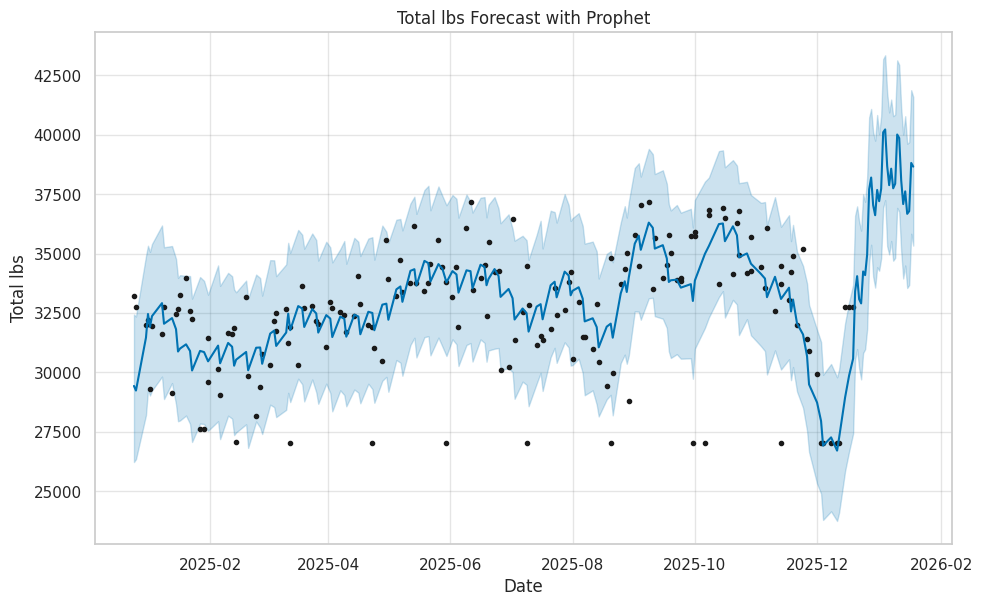

Generating forecast components plot...


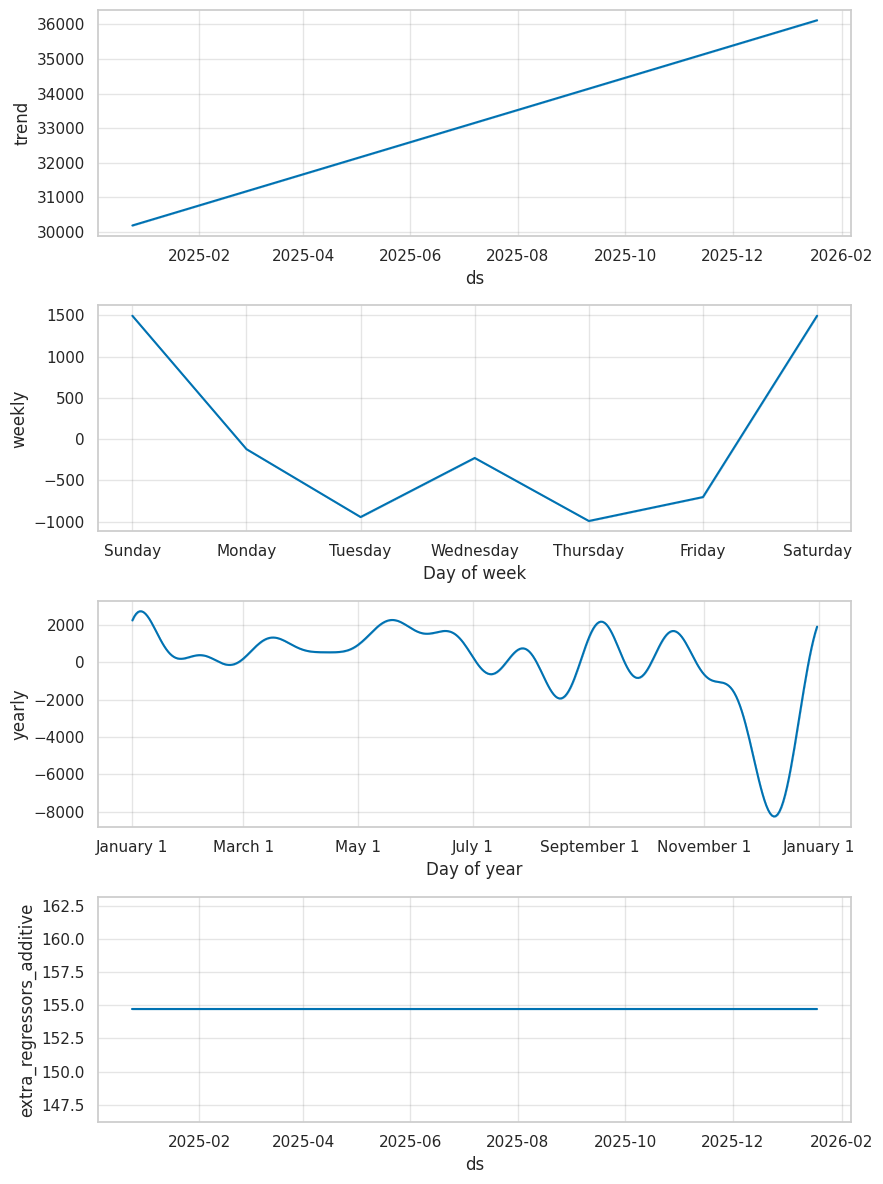

Prophet forecasting and visualization complete.


In [61]:
import matplotlib.pyplot as plt

# 1. Create a future DataFrame for predictions
# Let's forecast for the next 30 days beyond the last date in the dataset
future = model.make_future_dataframe(periods=30, freq='D')

# 2. Populate the additional regressor ('add1_regressor') for future dates
# A simple strategy is to use the median value from the original prophet_df for future predictions
median_add1_regressor = prophet_df['add1_regressor'].median()
future['add1_regressor'] = median_add1_regressor

# 3. Make predictions
forecast = model.predict(future)

# 4. Visualize the forecast
print("Generating forecast plot...")
fig1 = model.plot(forecast)
plt.title('Total lbs Forecast with Prophet')
plt.xlabel('Date')
plt.ylabel('Total lbs')
plt.show()

# 5. Visualize the forecast components (trend, yearly seasonality)
print("Generating forecast components plot...")
fig2 = model.plot_components(forecast)
plt.show()

print("Prophet forecasting and visualization complete.")

In [72]:
import pandas as pd

# Select the 'ds' and 'yearly' columns from the forecast DataFrame
yearly_seasonality_df = forecast[['ds', 'yearly']].copy()

# Display the head of the new DataFrame to verify
print("Head of yearly_seasonality_df:")
display(yearly_seasonality_df.head())

Head of yearly_seasonality_df:


,ds,yearly
0,2024-12-25,-679.714732
1,2024-12-26,-124.860562
2,2024-12-31,1979.835482
3,2025-01-01,2240.936461
4,2025-01-02,2445.322870


In [73]:
import pandas as pd

# Define the start and end dates for each season within 2025
seasons_2025 = {
    'Winter_Start': {'start': '2025-01-01', 'end': '2025-03-19'}, # New entry for Winter_Start
    'Spring': {'start': '2025-03-20', 'end': '2025-06-20'},
    'Summer': {'start': '2025-06-21', 'end': '2025-09-21'},
    'Autumn': {'start': '2025-09-22', 'end': '2025-12-20'},
    'Winter_End': {'start': '2025-12-21', 'end': '2025-12-31'} # Renamed existing 'Winter' to 'Winter_End'
}

# Also consider the beginning of 2025 winter extending from 2024
# For plotting purposes, we might need a full year cycle, so let's adjust for winter to show it fully if data spans:
# For simplicity, let's keep it defined within 2025 for now as the request specifies "within the year 2025"
# We will handle plotting the full winter period visually by extending it conceptually if necessary.

print("Defined seasonal dates for 2025:")
for season, dates in seasons_2025.items():
    print(f"{season}: Start = {dates['start']}, End = {dates['end']}")

Defined seasonal dates for 2025:
Winter_Start: Start = 2025-01-01, End = 2025-03-19
Spring: Start = 2025-03-20, End = 2025-06-20
Summer: Start = 2025-06-21, End = 2025-09-21
Autumn: Start = 2025-09-22, End = 2025-12-20
Winter_End: Start = 2025-12-21, End = 2025-12-31


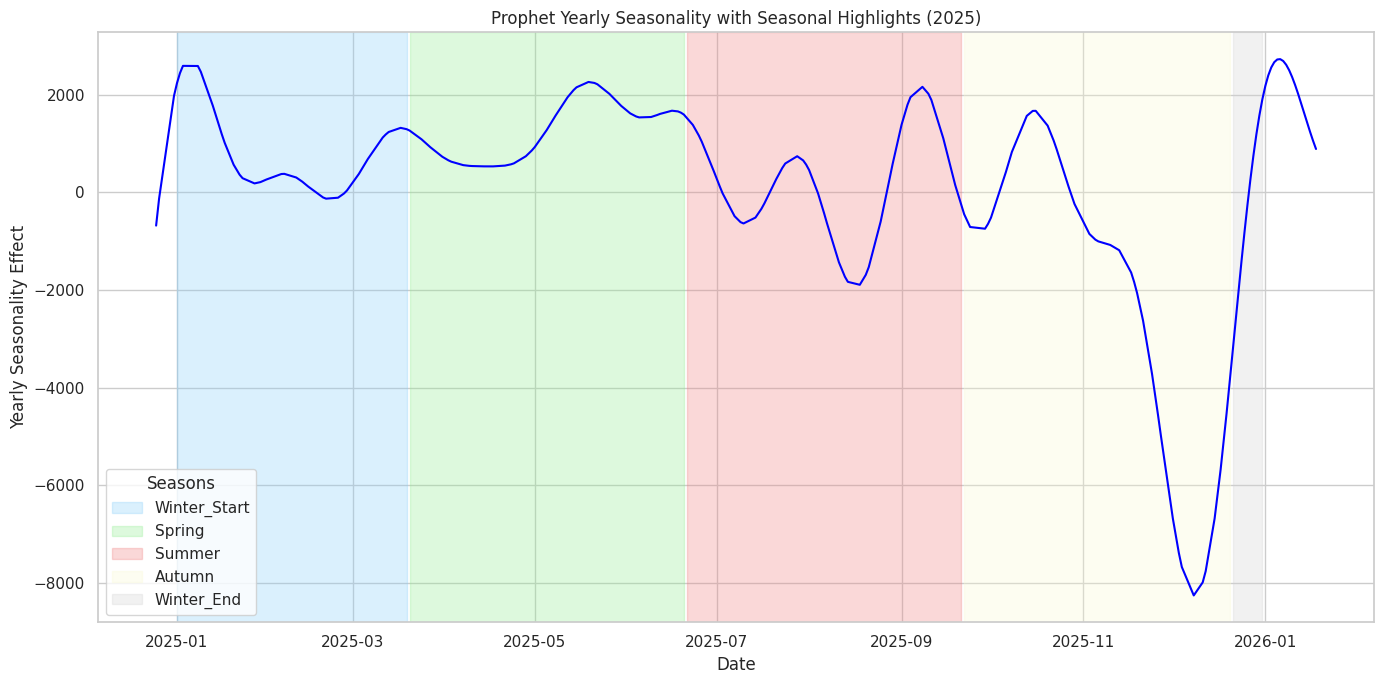

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'ds' column in yearly_seasonality_df to datetime objects
yearly_seasonality_df['ds'] = pd.to_datetime(yearly_seasonality_df['ds'])

plt.figure(figsize=(14, 7))
sns.lineplot(data=yearly_seasonality_df, x='ds', y='yearly', color='blue')
plt.title('Prophet Yearly Seasonality with Seasonal Highlights (2025)')
plt.xlabel('Date')
plt.ylabel('Yearly Seasonality Effect')
plt.grid(True)

# Define colors for seasons, including new Winter_Start and Winter_End
season_colors = {
    'Spring': 'lightgreen',
    'Summer': 'lightcoral',
    'Autumn': 'lightgoldenrodyellow',
    'Winter_Start': 'lightskyblue', # Distinct color for Winter_Start
    'Winter_End': 'lightgray' # Distinct color for Winter_End
}

# Highlight seasonal periods
for season_name, dates in seasons_2025.items():
    start_date = pd.to_datetime(dates['start'])
    end_date = pd.to_datetime(dates['end'])
    # Use the season_name as the key for colors
    plt.axvspan(start_date, end_date, color=season_colors[season_name], alpha=0.3, label=season_name)

# Add legend for seasons
plt.legend(title='Seasons')

plt.tight_layout()
plt.show()

## Findings:

*   **Data Preparation**: The data was successfully prepared for the Prophet model. The 'Farm Filling Information\_Loading Date' column was renamed to 'ds' and converted to datetime objects, 'Total\_lbs' to 'y', and 'Farm Filling Information\_Filled kg' to 'add1\_regressor'. No missing values were found in 'y' or 'add1\_regressor', thus no imputation was required.
*   **Model Configuration**: A Prophet model was initialized with `yearly_seasonality=True` and an `interval_width` of 0.95. The 'add1\_regressor' (representing 'Farm Filling Information\_Filled kg') was successfully added to the model.
*   **Forecasting**: A 30-day future forecast was generated. For the future predictions, the 'add1\_regressor' was populated using the median value from the existing dataset.
*   **Visualization**: The overall forecast for 'Total\_lbs' was visualized, showing the predicted trend and prediction intervals. Additionally, the forecast components, including the trend and yearly seasonality, were plotted separately.

# Forecast reliability

Create a time series forecasting model using the Prophet library with `df_cleaned` data. Prepare the data by selecting 'Farm Filling Information_Loading Date' as the datetime index ('ds'), 'Total_lbs' as the target variable ('y'), and 'Farm Filling Information_Filled kg' as an additional regressor ('add1_regressor'). Split this data into training and testing sets. Fit the Prophet model on the training data, then make predictions for both the historical data (training set), the held-out test set, and future dates. Finally, evaluate the model's accuracy on the held-out test set by calculating and displaying RMSE, MAE, and R-squared metrics, and visualize the actual vs. predicted values for the test set.

## Modify Data Preparation for Prophet (Add Train-Test Split)

We will modify the existing data preparation to include a train-test split for the Prophet model, ensuring a chronological split.


In [75]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Create a new DataFrame prophet_df from df_cleaned by selecting the columns
prophet_df = df_cleaned[[
    'Farm Filling Information_Loading Date',
    'Total_lbs',
    'Farm Filling Information_Filled kg'
]].copy()

# 2. Rename the columns in prophet_df to 'ds', 'y', and 'add1_regressor'
prophet_df.rename(columns={
    'Farm Filling Information_Loading Date': 'ds',
    'Total_lbs': 'y',
    'Farm Filling Information_Filled kg': 'add1_regressor'
}, inplace=True)

# 3. Convert the 'ds' column to datetime objects
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

# 4. Handle any missing values in the 'y' and 'add1_regressor' columns by filling them with their respective medians
# Check for missing values before imputation
print("Missing values before imputation:")
print(prophet_df[['y', 'add1_regressor']].isnull().sum())

# Impute missing values with median
if prophet_df['y'].isnull().any():
    y_median = prophet_df['y'].median()
    prophet_df['y'].fillna(y_median, inplace=True)
    print(f"'y' column: Filled missing values with median: {y_median}")

if prophet_df['add1_regressor'].isnull().any():
    add1_regressor_median = prophet_df['add1_regressor'].median()
    prophet_df['add1_regressor'].fillna(add1_regressor_median, inplace=True)
    print(f"'add1_regressor' column: Filled missing values with median: {add1_regressor_median}")


# 5. Print the head of the prophet_df DataFrame and its information (.info()) to verify the changes
print("\n--- prophet_df Head ---")
display(prophet_df.head())

print("\n--- prophet_df Info ---")
prophet_df.info()

# Chronological Train-Test Split
# Sort the DataFrame by 'ds' to ensure chronological order
prophet_df.sort_values(by='ds', inplace=True)

# Split the sorted prophet_df into training and testing sets
# shuffle=False is crucial for time series to maintain chronological order
prophet_train_df, prophet_test_df = train_test_split(
    prophet_df,
    test_size=0.2,
    shuffle=False
)

print("\n--- Train-Test Split Shapes ---")
print(f"Shape of prophet_train_df: {prophet_train_df.shape}")
print(f"Shape of prophet_test_df: {prophet_test_df.shape}")

Missing values before imputation:
y                 0
add1_regressor    0
dtype: int64

--- prophet_df Head ---


,ds,y,add1_regressor
0,2024-12-25,33212.69,39260.0
1,2024-12-26,32741.15,41370.0
2,2024-12-31,31991.59,38890.0
3,2025-01-01,32193.04,39790.0
4,2025-01-02,29322.94,38690.0



--- prophet_df Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ds              170 non-null    datetime64[ns]
 1   y               170 non-null    float64       
 2   add1_regressor  170 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 4.1 KB

--- Train-Test Split Shapes ---
Shape of prophet_train_df: (136, 3)
Shape of prophet_test_df: (34, 3)


## Make Predictions for Test Set and Evaluate Performance

We'll generate predictions for the `prophet_test_df` using the fitted Prophet model, calculate and display RMSE, MAE, and R-squared metrics to evaluate the model's accuracy on unseen data, and create a plot comparing the actual 'y' values from `prophet_test_df` with the predicted 'yhat' values specifically for the test period.

## Evaluate Prophet Model on Test Set

Let's generate predictions for the `prophet_test_df` using the fitted Prophet model, calculate and display RMSE, MAE, and R-squared metrics to evaluate the model's accuracy on unseen data.


In [76]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# 1. Generate predictions for the prophet_test_df DataFrame
# Prophet's predict method needs a DataFrame with a 'ds' column
forecast_test = model.predict(prophet_test_df[['ds', 'add1_regressor']])

# 2. Merge actual and predicted values for evaluation
# Merge forecast_test with prophet_test_df on 'ds' to align actual and predicted values
# Ensure 'y' column from prophet_test_df is included for actual values
eval_df = pd.merge(prophet_test_df, forecast_test[['ds', 'yhat']], on='ds', how='inner')

# Extract actual and predicted values
y_true = eval_df['y']
y_pred = eval_df['yhat']

# 3. Calculate RMSE, MAE, and R-squared metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

# 4. Display the calculated metrics
print("\nProphet Model Performance on Test Set:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R-squared: {r2:.4f}")


Prophet Model Performance on Test Set:
RMSE: 4910.5340
MAE: 3364.6286
R-squared: -1.4026


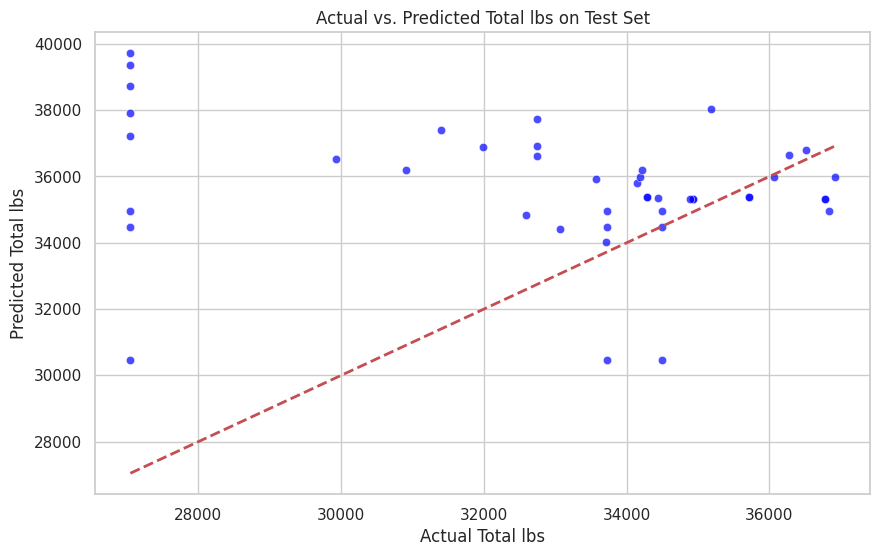

Visualized actual vs. predicted values for the test set.


In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a plot comparing actual vs. predicted values for the test set
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_true, y=y_pred, color='blue', alpha=0.7)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Total lbs on Test Set')
plt.xlabel('Actual Total lbs')
plt.ylabel('Predicted Total lbs')
plt.grid(True)
plt.show()

print("Visualized actual vs. predicted values for the test set.")


## Interpretation of Prophet Model Components and Regressor Impact

**1. Yearly Seasonality Component:**

The yearly seasonality plot typically shows a cyclical pattern throughout the year. Based on the generated plot (Figure 2, 'yearly' component), we can observe:

*   **Peaks**: Identify periods where the 'yearly' component is above the zero line, indicating a positive additive effect on 'Total_lbs'. For example, if there are noticeable peaks during certain months (e.g., spring or autumn), it suggests that mushroom yield tends to be higher during those times of the year, all else being equal. This could be due to favorable environmental conditions, operational cycles, or market demand patterns.
*   **Troughs**: Conversely, periods where the 'yearly' component dips below the zero line indicate a negative additive effect on 'Total_lbs'. If the plot shows troughs in certain months (e.g., winter or peak summer), it implies that yield is typically lower during these times. These patterns are crucial for understanding the inherent cyclical nature of production and can inform resource allocation and sales planning.
*   **Influence on Total_lbs**: The yearly seasonality component directly adds to or subtracts from the overall trend, meaning that the 'season of the year' has a predictable, recurring impact on the 'Total_lbs' production. This information helps in setting realistic expectations for production volumes throughout the year.

**2. 'Farm Filling Information_Filled kg' (add1_regressor) Component:**

Prophet's `plot_components` function typically generates a separate plot for each additional regressor. The 'extra_regressors_additive' component plot for 'Farm Filling Information_Filled kg' (add1_regressor) will illustrate its relationship with 'Total_lbs'.

*   **Impact on Total_lbs**: Given that 'Farm Filling Information_Filled kg' represents the quantity of compost filled, we would generally expect a **positive correlation** with 'Total_lbs'. The plot should show a clear upward trend, indicating that as the 'Filled kg' increases, the 'Total_lbs' yield also tends to increase. If the line is relatively straight, it suggests a linear additive effect. Any non-linearities or plateaus would indicate diminishing or accelerating returns from increasing 'Filled kg'.
*   **Interpretation**: A positive relationship confirms that the amount of raw material (compost) directly contributes to the overall mushroom output. This is a critical insight for production planning, as it quantifies the expected yield increase for a given increase in filled compost.

**3. Combined Insights from Trend, Seasonality, and Regressor Components:**

*   **Overall Forecast Driver**: The 'Total_lbs' forecast is a composite of the overarching **trend**, the consistent **yearly seasonality**, and the influence of the **additional regressor ('Farm Filling Information_Filled kg')**. The trend captures the long-term growth or decline in production, providing a baseline. The yearly seasonality fine-tunes this baseline by adding predictable intra-year fluctuations.
*   **Regressor's Role**: The 'Farm Filling Information_Filled kg' regressor plays a significant role by allowing the model to incorporate a known operational input that directly impacts yield. Instead of letting the trend or seasonality absorb the effects of varying filled compost, the model attributes that variance directly to the regressor. This makes the forecast more accurate and interpretable, as changes in 'Filled kg' can be directly linked to changes in predicted 'Total_lbs'.
*   **Predictive Power**: By combining these components, the Prophet model provides a robust forecast. The trend accounts for overall shifts, seasonality handles recurring patterns, and the regressor captures the impact of a key controllable input. This multi-faceted approach offers a more comprehensive understanding of the factors influencing mushroom yield over time, enabling better operational decisions and resource management.